In [27]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import random, copy, warnings, os, json
 
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)
 
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report,
                             precision_score, recall_score, f1_score, accuracy_score)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
 
from torch_geometric.data import HeteroData
from torch_geometric.nn import (GATv2Conv, GCNConv, Linear, HGTConv,
                                 RGCNConv, HypergraphConv, ChebConv)
 
from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer
from sdv.sampling import Condition
from imblearn.over_sampling import SMOTENC, RandomOverSampler
from torch.optim.lr_scheduler import CosineAnnealingLR
from scipy import stats
 
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
 
 
def set_seed(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    # Required for deterministic CUBLAS (scatter_add_, etc.) on CUDA
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    # Force all PyTorch ops to use deterministic algorithms.
    # scatter_add_ (used in GNN message passing) is non-deterministic by default.
    try:
        torch.use_deterministic_algorithms(True)
    except AttributeError:
        pass  # PyTorch < 1.8
 
set_seed(42)
 
N_TRIALS   = 100
N_FOLDS    = 5
MAX_EPOCHS = 200
PATIENCE   = 50
 

Using device: cuda
GPU: NVIDIA GeForce RTX 3050


In [28]:
tcga_df = pd.read_csv('../../dataset/TCGA_InfoWithGrade.csv')
cgga_df = pd.read_csv('../../dataset/weseq_processed_with_id_and_race_V2.csv')
 
if 'CGGA_ID' in cgga_df.columns:
    cgga_df = cgga_df.drop(columns='CGGA_ID')
 
tcga_before = len(tcga_df)
cgga_before = len(cgga_df)
tcga_df = tcga_df[tcga_df['Age_at_diagnosis'] >= 18].reset_index(drop=True)
cgga_df = cgga_df[cgga_df['Age_at_diagnosis'] >= 18].reset_index(drop=True)
print(f'TCGA: removed {tcga_before - len(tcga_df)} rows with Age < 18 '
      f'({tcga_before} → {len(tcga_df)})')
print(f'CGGA: removed {cgga_before - len(cgga_df)} rows with Age < 18 '
      f'({cgga_before} → {len(cgga_df)})')
 
categorical_columns = ['Grade', 'Gender', 'Race']
gene_columns = ['IDH1','TP53','ATRX','PTEN','EGFR','CIC','MUC16','PIK3CA',
                'NF1','PIK3R1','FUBP1','RB1','NOTCH1','BCOR','CSMD3',
                'SMARCA4','GRIN2A','IDH2','FAT4','PDGFRA']
NUM_GENES = len(gene_columns)
 
print("TCGA:", tcga_df.shape, "  Grade dist:", dict(tcga_df['Grade'].value_counts()))
print("CGGA:", cgga_df.shape, "  Grade dist:", dict(cgga_df['Grade'].value_counts()))
 

TCGA: removed 2 rows with Age < 18 (839 → 837)
CGGA: removed 2 rows with Age < 18 (286 → 284)
TCGA: (837, 24)   Grade dist: {0: np.int64(485), 1: np.int64(352)}
CGGA: (284, 24)   Grade dist: {0: np.int64(182), 1: np.int64(102)}


In [29]:
# ============================================================================
# 3. Splits + Global Scaler (FIX: prevents data leakage)
# ============================================================================
train_val_df, test_df = train_test_split(
    tcga_df, test_size=0.2, stratify=tcga_df['Grade'], random_state=42)
 
train_df, val_df = train_test_split(
    train_val_df, test_size=0.2, stratify=train_val_df['Grade'], random_state=42)
 
print(f"Train(HPO)={len(train_df)}  Val(HPO)={len(val_df)}  "
      f"TrainVal(CV)={len(train_val_df)}  Test={len(test_df)}")
print("Train Grade dist:", dict(train_df['Grade'].value_counts()))
print("Test  Grade dist:", dict(test_df['Grade'].value_counts()))
 
# FIX: Fit scaler ONCE on training data. Reuse for val/test/CGGA.
GLOBAL_SCALER = StandardScaler()
GLOBAL_SCALER.fit(train_val_df[['Age_at_diagnosis']].values.astype(float))
print(f"Global scaler fit on train_val (n={len(train_val_df)}): "
      f"mean={GLOBAL_SCALER.mean_[0]:.2f}, std={GLOBAL_SCALER.scale_[0]:.2f}")

Train(HPO)=535  Val(HPO)=134  TrainVal(CV)=669  Test=168
Train Grade dist: {0: np.int64(310), 1: np.int64(225)}
Test  Grade dist: {0: np.int64(97), 1: np.int64(71)}
Global scaler fit on train_val (n=669): mean=51.40, std=15.39


SCALE-FREE VERIFICATION — BA Graph Layers

───────────────────────────────────────────────────────
  Patient-Patient (seq BA)
───────────────────────────────────────────────────────
  gamma=OLS: 2.493  R2_PL=0.9588  R2_exp=0.8360  KS_p=0.9971

───────────────────────────────────────────────────────
  Gene-Gene (seq BA)
───────────────────────────────────────────────────────
  gamma=Hill: 1.973  R2_PL=0.8195  R2_exp=0.6652  KS_p=1.0000

  PP edges (undirected): 1335
  GG edges (undirected): 37
  GP edges:              1533


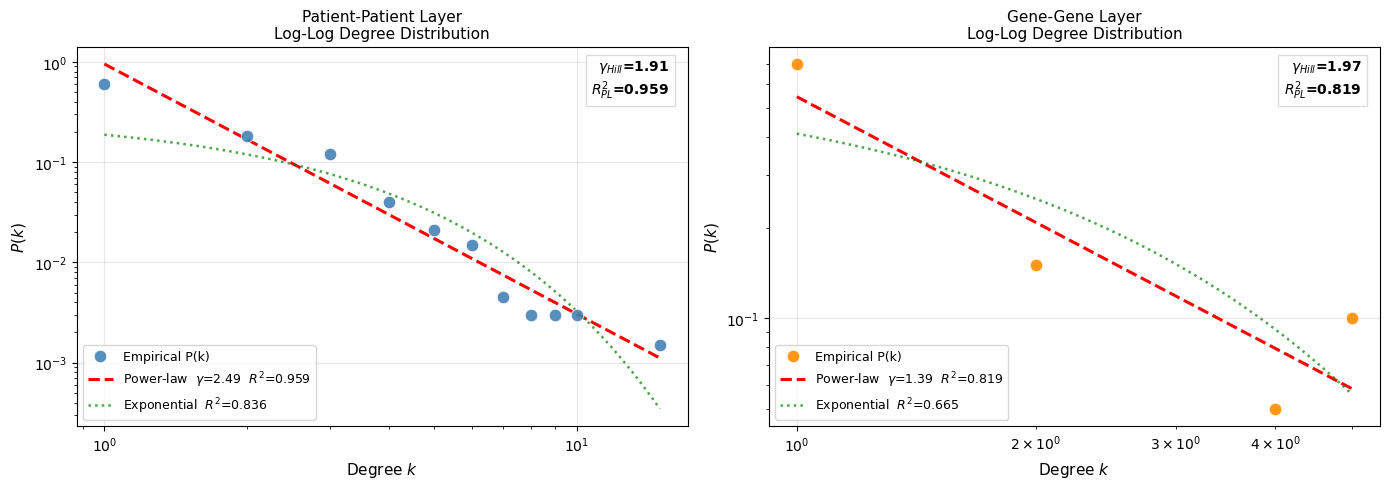

Saved: V16_scalefree_degree_dist.png


In [30]:
# ============================================================================
# 4. Graph Construction — Bipartite + Dual Scale-Free Layers
# ============================================================================
def to_dev(graph):
    return graph.to(device)
 
 
def construct_scalefree_bipartite_heterograph(df, ba_m=2, seed=42, scaler=None):
    """
    Full dual scale-free heterograph with 4 edge types.
 
    Parameters
    ----------
    scaler : StandardScaler or None
        If provided, uses pre-fit scaler (prevents data leakage for eval sets).
        If None, fits a new scaler on df (used for CV fold training splits).
    """
    rng     = np.random.default_rng(seed)
    mut_mat = df[gene_columns].values.astype(int)
    n_p     = len(df)
 
    graph = HeteroData()
 
    # ── Patient feature encoding ──────────────────────────────────────────
    if scaler is None:
        scaler = StandardScaler()
        scaler.fit(df[['Age_at_diagnosis']].values.astype(float))
    age_norm = scaler.transform(df[['Age_at_diagnosis']].values.astype(float))
    gender   = df[['Gender']].values.astype(float)
    race_ohe = np.zeros((len(df), 4), dtype=float)
    for i, rv in enumerate(df['Race'].values.astype(int)):
        if 0 <= rv < 4:
            race_ohe[i, rv] = 1.0
    pat_feats = np.hstack([gender, race_ohe, age_norm])
    graph["Patient"].x = torch.tensor(pat_feats, dtype=torch.float)
    graph["Patient"].y = torch.tensor(df["Grade"].values, dtype=torch.long)
    graph["Gene"].x    = torch.eye(NUM_GENES, dtype=torch.float)
 
    # ── Bipartite edges ──────────────────────────────────────────────────
    src_genes, dst_pats = [], []
    for p_idx, row in enumerate(mut_mat):
        for g_idx in np.where(row == 1)[0]:
            src_genes.append(g_idx); dst_pats.append(p_idx)
 
    graph[("Gene",   "mutates",   "Patient")].edge_index = torch.tensor([src_genes, dst_pats ], dtype=torch.long)
    graph[("Patient","mutated_by","Gene"   )].edge_index = torch.tensor([dst_pats,  src_genes], dtype=torch.long)
 
    # ── Patient-Patient: Sequential Barabasi-Albert ──────────────────────
    seed_deg = np.zeros(n_p, dtype=float)
    for g in range(NUM_GENES):
        carriers = np.where(mut_mat[:, g] == 1)[0]
        for i in range(len(carriers)):
            for j in range(i+1, min(i+50, len(carriers))):
                a, b = int(carriers[i]), int(carriers[j])
                seed_deg[a] += 1; seed_deg[b] += 1
    seed_deg = np.maximum(seed_deg, 1.0)
 
    order   = np.argsort(-seed_deg)
    degree  = np.zeros(n_p, dtype=float)
    pp_edge_set = set()
 
    for i in range(ba_m + 1):
        for j in range(i + 1, ba_m + 1):
            a, b = int(order[i]), int(order[j])
            pp_edge_set.add((min(a,b), max(a,b)))
            degree[a] += 1; degree[b] += 1
 
    for step in range(ba_m + 1, n_p):
        new_node = int(order[step])
        existing = order[:step]
        ed       = degree[existing] + seed_deg[existing]
        probs    = ed / ed.sum()
        for t in rng.choice(existing, size=min(ba_m, len(existing)),
                             replace=False, p=probs):
            a, b = min(new_node, int(t)), max(new_node, int(t))
            pp_edge_set.add((a, b))
            degree[new_node] += 1; degree[int(t)] += 1
 
    if pp_edge_set:
        pp_s, pp_d = zip(*pp_edge_set)
        graph[("Patient","cooccurs","Patient")].edge_index = torch.tensor(
            [list(pp_s)+list(pp_d), list(pp_d)+list(pp_s)], dtype=torch.long)
    else:
        graph[("Patient","cooccurs","Patient")].edge_index = torch.zeros(2, 0, dtype=torch.long)
 
    # ── Gene-Gene: Sequential BA seeded by mutation frequency ────────────
    ba_m_gene = 2
    gene_mut_freq = np.maximum(mut_mat.sum(axis=0).astype(float), 1.0)
    freq_order    = np.argsort(-gene_mut_freq)
    gg_degree     = np.zeros(NUM_GENES, dtype=float)
    gg_edge_set   = set()
 
    for i in range(ba_m_gene + 1):
        for j in range(i + 1, ba_m_gene + 1):
            a, b = int(freq_order[i]), int(freq_order[j])
            gg_edge_set.add((min(a, b), max(a, b)))
            gg_degree[a] += 1; gg_degree[b] += 1
 
    for step in range(ba_m_gene + 1, NUM_GENES):
        new_gene = int(freq_order[step])
        existing = freq_order[:step]
        ed       = gg_degree[existing] + gene_mut_freq[existing]
        probs    = ed / ed.sum()
        for t in rng.choice(existing, size=min(ba_m_gene, len(existing)),
                             replace=False, p=probs):
            a, b = min(new_gene, int(t)), max(new_gene, int(t))
            gg_edge_set.add((a, b))
            gg_degree[new_gene] += 1; gg_degree[int(t)] += 1
 
    if gg_edge_set:
        gg_s, gg_d = zip(*gg_edge_set)
        graph[("Gene","coexists","Gene")].edge_index = torch.tensor(
            [list(gg_s)+list(gg_d), list(gg_d)+list(gg_s)], dtype=torch.long)
    else:
        graph[("Gene","coexists","Gene")].edge_index = torch.zeros(2, 0, dtype=torch.long)
 
    return graph
 
 
# ── Scale-Free Verification ─────────────────────────────────────────────────
def _hill_mle(degrees, k_min=None):
    d = degrees[degrees > 0].astype(float)
    if k_min is None: k_min = d.min()
    tail = d[d >= k_min]
    if len(tail) < 2: return 0.0
    return 1.0 + len(tail) / np.sum(np.log(tail / (k_min - 0.5)))
 
 
def fit_powerlaw(degrees, label="Degrees"):
    n_nodes = len(degrees)
    k_vals, counts = np.unique(degrees[degrees > 0], return_counts=True)
    pmf   = counts / len(degrees[degrees > 0])
    log_k = np.log(k_vals.astype(float))
    log_p = np.log(pmf + 1e-12)
 
    sl_pl,  ic_pl,  r_pl,  *_ = stats.linregress(log_k, log_p)
    sl_exp, ic_exp, r_exp, *_ = stats.linregress(k_vals.astype(float), log_p)
    gamma_ols = -sl_pl
    r2_pl     = r_pl  ** 2
    r2_exp    = r_exp ** 2
    gamma_hill = _hill_mle(degrees)
 
    fitted_pl = np.exp(ic_pl) * (k_vals.astype(float) ** sl_pl)
    fitted_pl = fitted_pl / (fitted_pl.sum() + 1e-12)
    _, ks_p   = stats.ks_2samp(pmf, fitted_pl)
 
    small_n = n_nodes < 50
    gamma_report = gamma_hill if small_n else gamma_ols
 
    print(f"\n{'─'*55}\n  {label}\n{'─'*55}")
    print(f"  gamma={'Hill' if small_n else 'OLS'}: {gamma_report:.3f}  "
          f"R2_PL={r2_pl:.4f}  R2_exp={r2_exp:.4f}  KS_p={ks_p:.4f}")
 
    return gamma_report, r2_pl, r2_exp, ks_p
 
 
print("=" * 65)
print("SCALE-FREE VERIFICATION — BA Graph Layers")
print("=" * 65)
 
_sf_g  = construct_scalefree_bipartite_heterograph(train_val_df, ba_m=2, scaler=GLOBAL_SCALER)
_pp_ei = _sf_g[("Patient","cooccurs","Patient")].edge_index.cpu()
_gg_ei = _sf_g[("Gene","coexists","Gene")].edge_index.cpu()
_pp_d  = np.bincount(_pp_ei[0].numpy(), minlength=_sf_g["Patient"].x.shape[0]) // 2
_gg_d  = np.bincount(_gg_ei[0].numpy(), minlength=NUM_GENES) // 2
 
fit_powerlaw(_pp_d, "Patient-Patient (seq BA)")
fit_powerlaw(_gg_d, "Gene-Gene (seq BA)")
 
print(f"\n  PP edges (undirected): {_pp_ei.shape[1]//2}")
print(f"  GG edges (undirected): {_gg_ei.shape[1]//2}")
print(f"  GP edges:              {_sf_g[('Gene','mutates','Patient')].edge_index.shape[1]}")

# ── Plot degree distributions (paper figures) ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, d, label, color in [
    (axes[0], _pp_d, "Patient-Patient", "steelblue"),
    (axes[1], _gg_d, "Gene-Gene", "darkorange"),
]:
    k, c = np.unique(d[d > 0], return_counts=True)
    pmf  = c / c.sum()
    ax.loglog(k, pmf, "o", color=color, ms=9, alpha=0.90,
               markeredgecolor="white", markeredgewidth=0.6, zorder=4, label="Empirical P(k)")
    log_k = np.log(k.astype(float))
    log_p = np.log(pmf + 1e-12)
    sl_pl, ic_pl, r_pl, *_ = stats.linregress(log_k, log_p)
    sl_ex, ic_ex, r_ex, *_ = stats.linregress(k.astype(float), log_p)
    k_sm = np.linspace(k.min(), k.max(), 100)
    ax.loglog(k_sm, np.exp(ic_pl + sl_pl * np.log(k_sm)), "r--", lw=2.2,
               label=f"Power-law  $\\gamma$={-sl_pl:.2f}  $R^2$={r_pl**2:.3f}")
    ax.loglog(k_sm, np.exp(ic_ex + sl_ex * k_sm), "g:", lw=1.8,
               label=f"Exponential  $R^2$={r_ex**2:.3f}", alpha=0.7)
    ax.set_xlabel("Degree $k$", fontsize=11)
    ax.set_ylabel("$P(k)$", fontsize=11)
    ax.set_title(f"{label} Layer\nLog-Log Degree Distribution", fontsize=11)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    gamma_h = _hill_mle(d)
    ax.text(0.97, 0.97, f"$\\gamma_{{Hill}}$={gamma_h:.2f}\n$R^2_{{PL}}$={r_pl**2:.3f}",
             transform=ax.transAxes, fontsize=10, fontweight="bold",
             va="top", ha="right",
             bbox=dict(fc="white", alpha=0.8, ec="lightgray"))
plt.tight_layout()
plt.savefig("V16_scalefree_degree_dist.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: V16_scalefree_degree_dist.png")
 

In [31]:
# ============================================================================
# 5. Build Shared Evaluation Graphs (using GLOBAL_SCALER)
# ============================================================================
val_graph  = to_dev(construct_scalefree_bipartite_heterograph(val_df,  scaler=GLOBAL_SCALER))
test_graph = to_dev(construct_scalefree_bipartite_heterograph(test_df, scaler=GLOBAL_SCALER))
cgga_graph = to_dev(construct_scalefree_bipartite_heterograph(cgga_df, scaler=GLOBAL_SCALER))
 
print("Val  graph:", val_graph['Patient'].x.shape[0], "patients")
print("Test graph:", test_graph['Patient'].x.shape[0], "patients")
print("CGGA graph:", cgga_graph['Patient'].x.shape[0], "patients")

Val  graph: 134 patients
Test graph: 168 patients
CGGA graph: 284 patients


In [32]:
# ============================================================================
# 6. Model Definitions (7 architectures)
# ============================================================================

# ── 1. HeteroGATv2 ──────────────────────────────────────────────────────────
class HeteroGATv2(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, **_):
        super().__init__()
        self.dr = dropout
        self.p_lin     = Linear(-1, hidden_dim); self.g_lin = Linear(-1, hidden_dim)
        self.clin_skip = Linear(-1, hidden_dim)
        self.gg_conv = GCNConv(hidden_dim, hidden_dim)
        self.g2p = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.p2g = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.p_skip = Linear(hidden_dim, hidden_dim); self.g_skip = Linear(hidden_dim, hidden_dim)
        self.pp_conv = GCNConv(hidden_dim, hidden_dim)
        self.clf = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        ei    = graph.edge_index_dict
        x_pat = graph['Patient'].x
        h_clin = F.relu(self.clin_skip(x_pat))
        hp = F.relu(self.p_lin(x_pat))
        hg = F.relu(self.g_lin(graph['Gene'].x))
        gg_ei = graph[('Gene','coexists','Gene')].edge_index.to(hg.device)
        if gg_ei.shape[1] > 0:
            hg = hg + F.relu(self.gg_conv(hg, gg_ei))
        hp = self.p_skip(hp) + self.g2p((hg, hp), ei[('Gene','mutates','Patient')])
        hg = self.g_skip(hg) + self.p2g((hp, hg), ei[('Patient','mutated_by','Gene')])
        pp_ei = graph[('Patient','cooccurs','Patient')].edge_index.to(hp.device)
        hp = hp + self.pp_conv(hp, pp_ei)
        hp = F.dropout(F.leaky_relu(hp, 0.2), self.dr, training=self.training) + h_clin
        return self.clf(hp)

    def _get_enriched_gene_emb(self, graph):
        hg    = F.relu(self.g_lin(graph['Gene'].x))
        gg_ei = graph[('Gene','coexists','Gene')].edge_index.to(hg.device)
        if gg_ei.shape[1] > 0:
            hg = hg + F.relu(self.gg_conv(hg, gg_ei))
        return hg

    def get_attn_weights(self, graph):
        ei = graph.edge_index_dict
        hp = F.relu(self.p_lin(graph['Patient'].x))
        hg = self._get_enriched_gene_emb(graph)
        _, (eidx, alpha) = self.g2p((hg, hp), ei[('Gene','mutates','Patient')],
                                     return_attention_weights=True)
        return eidx, alpha.detach().mean(dim=-1)

    def get_all_heads_attn(self, graph):
        ei = graph.edge_index_dict
        hp = F.relu(self.p_lin(graph['Patient'].x))
        hg = self._get_enriched_gene_emb(graph)
        _, (eidx, alpha) = self.g2p((hg, hp), ei[('Gene','mutates','Patient')],
                                     return_attention_weights=True)
        return eidx, alpha.detach()

    def get_p2g_attn_weights(self, graph):
        ei    = graph.edge_index_dict
        hp    = F.relu(self.p_lin(graph['Patient'].x))
        hg    = self._get_enriched_gene_emb(graph)
        hp_upd = self.p_skip(hp) + self.g2p((hg, hp), ei[('Gene','mutates','Patient')])
        _, (eidx_r, alpha_r) = self.p2g((hp_upd, hg), ei[('Patient','mutated_by','Gene')],
                                         return_attention_weights=True)
        return eidx_r, alpha_r.detach().mean(dim=-1)


# ── 2. MOGAT ─────────────────────────────────────────────────────────────────
class MOGAT(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, **_):
        super().__init__()
        self.dr = dropout
        self.pg = Linear(-1, hidden_dim); self.gg = Linear(-1, hidden_dim)
        self.gg_conv = GCNConv(hidden_dim, hidden_dim)
        self.gat = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.pc = Linear(-1, hidden_dim)
        self.mlp = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
                                  nn.Dropout(dropout), nn.Linear(hidden_dim, hidden_dim))
        self.gate = nn.Linear(hidden_dim * 2, 2)
        self.pp_conv = GCNConv(hidden_dim, hidden_dim)
        self.clf = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        e   = graph[('Gene','mutates','Patient')].edge_index
        hpg = F.relu(self.pg(graph['Patient'].x))
        hgg = F.relu(self.gg(graph['Gene'].x))
        gg_ei = graph[('Gene','coexists','Gene')].edge_index.to(hgg.device)
        if gg_ei.shape[1] > 0:
            hgg = hgg + F.relu(self.gg_conv(hgg, gg_ei))
        hpg = F.dropout(F.leaky_relu(self.gat((hgg, hpg), e), 0.2), self.dr, training=self.training)
        hpc = self.mlp(F.relu(self.pc(graph['Patient'].x)))
        g   = torch.softmax(self.gate(torch.cat([hpg, hpc], -1)), dim=-1)
        hp  = g[:, :1] * hpg + g[:, 1:] * hpc
        pp_ei = graph[('Patient','cooccurs','Patient')].edge_index.to(hp.device)
        hp = hp + self.pp_conv(hp, pp_ei)
        return self.clf(hp)

    def _get_enriched_gene_emb(self, graph):
        hgg   = F.relu(self.gg(graph['Gene'].x))
        gg_ei = graph[('Gene','coexists','Gene')].edge_index.to(hgg.device)
        if gg_ei.shape[1] > 0:
            hgg = hgg + F.relu(self.gg_conv(hgg, gg_ei))
        return hgg

    def get_attn_weights(self, graph):
        e   = graph[('Gene','mutates','Patient')].edge_index
        hpg = F.relu(self.pg(graph['Patient'].x))
        hgg = self._get_enriched_gene_emb(graph)
        _, (eidx, alpha) = self.gat((hgg, hpg), e, return_attention_weights=True)
        return eidx, alpha.detach().mean(dim=-1)

    def get_all_heads_attn(self, graph):
        e   = graph[('Gene','mutates','Patient')].edge_index
        hpg = F.relu(self.pg(graph['Patient'].x))
        hgg = self._get_enriched_gene_emb(graph)
        _, (eidx, alpha) = self.gat((hgg, hpg), e, return_attention_weights=True)
        return eidx, alpha.detach()

    def get_fusion_gate(self, graph):
        e   = graph[('Gene','mutates','Patient')].edge_index
        hpg = F.relu(self.pg(graph['Patient'].x))
        hgg = self._get_enriched_gene_emb(graph)
        hpg_out = F.leaky_relu(self.gat((hgg, hpg), e), 0.2)
        hpc     = self.mlp(F.relu(self.pc(graph['Patient'].x)))
        gate_w  = torch.softmax(self.gate(torch.cat([hpg_out, hpc], -1)), dim=-1)
        return gate_w.detach()


# ── 3. HyperTMO ─────────────────────────────────────────────────────────────
class HyperTMO(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, in_channels=6, **_):
        super().__init__()
        self.dr = dropout
        self.p_lin     = nn.Linear(in_channels, hidden_dim)
        self.clin_skip = nn.Linear(in_channels, hidden_dim)
        self.g_lin     = nn.Linear(NUM_GENES, hidden_dim)
        self.hc1 = HypergraphConv(hidden_dim, hidden_dim, use_attention=True,
                                   heads=num_heads, dropout=dropout, concat=False)
        self.hc2 = HypergraphConv(hidden_dim, hidden_dim)
        self.skip = nn.Linear(hidden_dim, hidden_dim)
        self.bn = nn.BatchNorm1d(hidden_dim)
        self.pp_conv = GCNConv(hidden_dim, hidden_dim)
        self.clf = nn.Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp = graph['Patient'].x; xg = graph['Gene'].x
        h_clin = F.relu(self.clin_skip(xp))
        ei  = graph[('Gene','mutates','Patient')].edge_index
        hei = torch.stack([ei[1], ei[0]], dim=0)
        hp = F.relu(self.p_lin(xp)); hg = F.relu(self.g_lin(xg)); s = self.skip(hp)
        hp = F.relu(self.hc1(hp, hei, hyperedge_attr=hg))
        hp = F.dropout(hp, self.dr, training=self.training)
        hp = self.bn(F.relu(self.hc2(hp, hei) + s))
        pp_ei = graph[('Patient','cooccurs','Patient')].edge_index.to(hp.device)
        hp = hp + self.pp_conv(hp, pp_ei)
        return self.clf(F.dropout(hp, self.dr, training=self.training))


# ── 4. RGCN ──────────────────────────────────────────────────────────────────
class RGCNModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2,
                 in_channels=6, num_relations=20, **_):
        super().__init__()
        self.dr = dropout
        self.lin = nn.Linear(in_channels, hidden_dim)
        self.rc1 = RGCNConv(hidden_dim, hidden_dim, num_relations=num_relations)
        self.rc2 = RGCNConv(hidden_dim, hidden_dim, num_relations=num_relations)
        self.skip = nn.Linear(hidden_dim, hidden_dim)
        self.bn = nn.BatchNorm1d(hidden_dim); self.clf = nn.Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp = graph['Patient'].x
        pp_ei = graph[('Patient','cooccurs','Patient')].edge_index.to(xp.device)
        pp_et = torch.zeros(pp_ei.shape[1], dtype=torch.long, device=xp.device)
        h = F.relu(self.lin(xp)); s = self.skip(h)
        h = F.relu(self.rc1(h, pp_ei, pp_et))
        h = F.dropout(h, self.dr, training=self.training)
        h = self.bn(F.relu(self.rc2(h, pp_ei, pp_et) + s))
        return self.clf(F.dropout(h, self.dr, training=self.training))


# ── 5. VEGN (FIX: was discarding gene-patient aggregation) ──────────────────
class VEGNModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, **_):
        super().__init__()
        self.dr = dropout
        self.p_lin     = Linear(-1, hidden_dim); self.g_lin = Linear(-1, hidden_dim)
        self.clin_skip = Linear(-1, hidden_dim)
        self.ve = nn.Sequential(nn.Linear(hidden_dim*2, hidden_dim), nn.ReLU(),
                                 nn.Linear(hidden_dim, 1), nn.Sigmoid())
        self.p2g = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.skip = Linear(hidden_dim, hidden_dim)
        self.bn = nn.BatchNorm1d(hidden_dim)
        self.pp_conv = GCNConv(hidden_dim, hidden_dim)
        self.clf = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp = graph['Patient'].x; xg = graph['Gene'].x
        h_clin = F.relu(self.clin_skip(xp))
        e_g2p = graph[('Gene','mutates','Patient')].edge_index
        e_p2g = graph[('Patient','mutated_by','Gene')].edge_index
        hp = F.relu(self.p_lin(xp)); hg = F.relu(self.g_lin(xg))
        sg, dp = e_g2p[0], e_g2p[1]
        wt = self.ve(torch.cat([hg[sg], hp[dp]], -1)).squeeze(-1)
        msg = hg[sg] * wt.unsqueeze(-1)
        agg = torch.zeros_like(hp); agg.scatter_add_(0, dp.unsqueeze(-1).expand_as(msg), msg)
        deg = torch.zeros(hp.shape[0], device=hp.device)
        deg.scatter_add_(0, dp, wt); deg = deg.clamp(min=1)
        agg = agg / deg.unsqueeze(-1)
        _ = self.p2g((hp, hg), e_p2g)
        # FIX: use aggregated features (was returning stale hp, ignoring agg + pp_conv)
        hp = self.bn(F.leaky_relu(self.skip(hp) + agg, 0.2))
        pp_ei = graph[('Patient','cooccurs','Patient')].edge_index.to(hp.device)
        hp = hp + self.pp_conv(hp, pp_ei)
        hp = F.dropout(hp, self.dr, training=self.training) + h_clin
        return self.clf(hp)


# ── 6. FastHGTConv ───────────────────────────────────────────────────────────
_HGT_META_SF = (['Patient','Gene'],
                [('Gene','mutates','Patient'),('Patient','mutated_by','Gene'),
                 ('Patient','cooccurs','Patient'),('Gene','coexists','Gene')])

class FastHGTModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2,
                 hgt_meta=None, **_):
        super().__init__()
        self.dr = dropout
        meta = hgt_meta if hgt_meta is not None else _HGT_META_SF
        self.p_lin     = Linear(-1, hidden_dim); self.g_lin = Linear(-1, hidden_dim)
        self.clin_skip = Linear(-1, hidden_dim)
        self.hgt1 = HGTConv(hidden_dim, hidden_dim, metadata=meta, heads=num_heads)
        self.hgt2 = HGTConv(hidden_dim, hidden_dim, metadata=meta, heads=num_heads)
        self.skip = Linear(hidden_dim, hidden_dim)
        self.bn = nn.BatchNorm1d(hidden_dim); self.clf = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        h_clin = F.relu(self.clin_skip(graph['Patient'].x))
        xd = {'Patient': F.relu(self.p_lin(graph['Patient'].x)),
              'Gene':    F.relu(self.g_lin(graph['Gene'].x))}
        sp = self.skip(xd['Patient']); ei = graph.edge_index_dict
        xd = {k: F.dropout(F.relu(v), self.dr, training=self.training)
              for k, v in self.hgt1(xd, ei).items()}
        xd = self.hgt2(xd, ei)
        hp = self.bn(F.relu(xd['Patient'] + sp))
        return self.clf(F.dropout(hp, self.dr, training=self.training) + h_clin)


# ── 7. SGNN ──────────────────────────────────────────────────────────────────
class SGNNModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2,
                 in_channels=6, K=3, **_):
        super().__init__()
        self.dr = dropout
        self.lin = nn.Linear(in_channels, hidden_dim)
        self.c1 = ChebConv(hidden_dim, hidden_dim, K=K)
        self.c2 = ChebConv(hidden_dim, hidden_dim, K=K)
        self.skip = nn.Linear(hidden_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim); self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.clf = nn.Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp = graph['Patient'].x
        pp_ei = graph[('Patient','cooccurs','Patient')].edge_index.to(xp.device)
        h = F.relu(self.lin(xp)); s = self.skip(h)
        h = self.bn1(F.relu(self.c1(h, pp_ei)))
        h = F.dropout(h, self.dr, training=self.training)
        h = self.bn2(F.relu(self.c2(h, pp_ei) + s))
        return self.clf(F.dropout(h, self.dr, training=self.training))


MODEL_REGISTRY = [
    ('HeteroGATv2', HeteroGATv2,  {}),
    ('MOGAT',       MOGAT,        {}),
    ('HyperTMO',    HyperTMO,     {'in_channels': 6}),
    ('RGCN',        RGCNModel,    {'in_channels': 6, 'num_relations': NUM_GENES}),
    ('VEGN',        VEGNModel,    {}),
    ('FastHGTConv', FastHGTModel, {'hgt_meta': _HGT_META_SF}),
    ('SGNN',        SGNNModel,    {'in_channels': 6}),
]
print(f"Registered {len(MODEL_REGISTRY)} models:", [n for n,_,_ in MODEL_REGISTRY])


Registered 7 models: ['HeteroGATv2', 'MOGAT', 'HyperTMO', 'RGCN', 'VEGN', 'FastHGTConv', 'SGNN']


In [33]:
# ============================================================================
# 7. Focal Loss + Class Weights
# ============================================================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, weight=None):
        super().__init__()
        self.a, self.g, self.w = alpha, gamma, weight
    def forward(self, inp, tgt):
        ce = F.cross_entropy(inp, tgt, weight=self.w, reduction='none')
        return (self.a * (1 - torch.exp(-ce)) ** self.g * ce).mean()


def make_criterion(train_graph, verbose=False):
    """Compute focal loss with inverse-frequency weights from the ACTUAL training distribution.
    After augmentation (SMOTE/CTGAN/ROS) the classes are balanced, so weights ≈ 1.0/1.0.
    Without augmentation the minority class gets upweighted as intended."""
    labels = train_graph['Patient'].y.cpu().numpy()
    n0 = float((labels == 0).sum())
    n1 = float((labels == 1).sum())
    total = n0 + n1
    w0 = total / (2.0 * n0)
    w1 = total / (2.0 * n1)
    cw = torch.tensor([w0, w1], dtype=torch.float).to(device)
    if verbose:
        print(f"    Class weights: Grade-0={w0:.4f}  Grade-1={w1:.4f}  (n0={int(n0)}, n1={int(n1)})")
    return FocalLoss(alpha=1, gamma=2, weight=cw)

In [34]:
# ============================================================================
# 8. Threshold Optimisation + Evaluation Helpers
# ============================================================================
def find_optimal_threshold(probs, labels, low=0.20, high=0.80, step=0.005):
    best_th, best_gm, best_imb = 0.5, -1.0, 1.0
    for th in np.arange(low, high + step * 0.5, step):
        preds = (probs >= th).astype(int)
        r1  = recall_score(labels, preds, pos_label=1, zero_division=0)
        r0  = recall_score(labels, preds, pos_label=0, zero_division=0)
        gm  = np.sqrt(r0 * r1)
        imb = abs(r1 - r0)
        if gm > best_gm + 0.005:
            best_gm = gm; best_th = float(th); best_imb = imb
        elif gm >= best_gm - 0.005 and imb < best_imb:
            best_th = float(th); best_imb = imb
    return best_th


def evaluate_model(model, graph, threshold=0.5):
    model.eval()
    with torch.no_grad():
        logits = model(graph)
        probs  = F.softmax(logits, 1)[:, 1].cpu().numpy()
        labels = graph['Patient'].y.cpu().numpy()
    preds = (probs >= threshold).astype(int)
    return preds, probs, labels


def compute_metrics(preds, probs, labels):
    try:
        auc = roc_auc_score(labels, probs)
    except ValueError:
        auc = float('nan')
    return {
        'auc':       auc,
        'accuracy':  accuracy_score(labels, preds),
        'precision': precision_score(labels, preds, zero_division=0),
        'recall':    recall_score(labels, preds, zero_division=0),
        'recall_0':  recall_score(labels, preds, pos_label=0, zero_division=0),
        'f1':        f1_score(labels, preds, zero_division=0),
    }

all_results    = []
cv_results     = []
all_models     = {}
all_studies    = {}
all_params     = {}
all_thresholds = {}
PIPELINES      = ['No Balancing', 'SMOTE', 'CTGAN', 'ROS']


In [35]:
# ============================================================================
# 9. Training Function
# ============================================================================
def train_and_evaluate(train_graph, val_graph, params, ModelClass,
                        fixed_kw=None, max_epochs=MAX_EPOCHS, patience=PATIENCE,
                        seed=42, loss_fn=None):
    set_seed(seed)
    if loss_fn is None:
        loss_fn = make_criterion(train_graph)
    kw = {'hidden_dim': params['hidden_dim'], 'out_dim': 2,
          'num_heads':  params['num_heads'],  'dropout': params['dropout']}
    if fixed_kw: kw.update(fixed_kw)

    model = ModelClass(**kw).to(device)
    try:
        with torch.no_grad(): _ = model(train_graph)
    except Exception: pass

    opt = torch.optim.AdamW(model.parameters(),
                              lr=params['lr'], weight_decay=params['weight_decay'])
    sch = CosineAnnealingLR(opt, T_max=max_epochs, eta_min=params['lr'] * 0.05)

    best_auc, ctr, best_state, history = 0.0, 0, None, []
    for _ in range(max_epochs):
        model.train(); opt.zero_grad()
        loss = loss_fn(model(train_graph), train_graph['Patient'].y)
        loss.backward(); opt.step(); sch.step()

        model.eval()
        with torch.no_grad():
            vp  = F.softmax(model(val_graph), 1)[:, 1].cpu().numpy()
            vl  = val_graph['Patient'].y.cpu().numpy()
        try:    auc = roc_auc_score(vl, vp)
        except: auc = 0.0
        history.append(auc)

        if auc > best_auc:
            best_auc, ctr = auc, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            ctr += 1
            if ctr >= patience: break

    return best_auc, best_state, history

In [36]:
# ============================================================================
# 10. Optuna HPO
# ============================================================================
def run_optuna(train_graph, val_graph, ModelClass, fixed_kw=None,
               n_trials=N_TRIALS, label=''):
    hpo_criterion = make_criterion(train_graph, verbose=True)

    def objective(trial):
        set_seed(42)
        params = {
            'hidden_dim':   trial.suggest_categorical('hidden_dim', [16, 32, 64, 128]),
            'num_heads':    trial.suggest_categorical('num_heads',  [2, 4, 8]),
            'dropout':      trial.suggest_float('dropout', 0.05, 0.30, step=0.05),
            'lr':           trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            'weight_decay': trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True),
        }
        auc, _, _ = train_and_evaluate(train_graph, val_graph, params, ModelClass,
                                        fixed_kw, loss_fn=hpo_criterion)
        return auc

    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    bp = study.best_params
    print(f"  [{label}] Best AUC={study.best_value:.4f}  params={bp}")
    _, best_state, _ = train_and_evaluate(train_graph, val_graph, bp, ModelClass,
                                           fixed_kw, loss_fn=hpo_criterion)
    return bp, best_state, study

In [37]:
# ============================================================================
# 11. 5-Fold CV (FIX: scaler fit on fold training data before augmentation)
# ============================================================================
def apply_smote(fold_train_df):
    feat_cols = gene_columns + ['Gender','Race','Age_at_diagnosis']
    cat_idx   = [i for i,c in enumerate(feat_cols)
                  if c in gene_columns or c in ['Gender','Race']]
    sm = SMOTENC(categorical_features=cat_idx, random_state=42, k_neighbors=3)
    Xr, yr = sm.fit_resample(fold_train_df[feat_cols], fold_train_df['Grade'])
    df2 = pd.DataFrame(Xr, columns=feat_cols); df2['Grade'] = yr
    for c in gene_columns: df2[c] = df2[c].round().astype(int)
    df2['Race']   = df2['Race'].round().astype(int).clip(0, 3)
    df2['Gender'] = df2['Gender'].round().astype(int).clip(0, 1)
    return df2


def apply_ctgan(fold_train_df):
    meta = SingleTableMetadata()
    meta.detect_from_dataframe(fold_train_df)
    for col in categorical_columns + gene_columns:
        meta.update_column(column_name=col, sdtype='categorical')
    vc    = fold_train_df['Grade'].value_counts()
    n_gen = int(vc.max() - vc.min())
    if n_gen <= 0:
        return fold_train_df
    # CTGAN uses CUDA ops that may lack deterministic implementations,
    # so temporarily relax the constraint during GAN training.
    set_seed(42)
    try:
        torch.use_deterministic_algorithms(False)
    except AttributeError:
        pass
    syn = CTGANSynthesizer(meta, epochs=100, batch_size=50, verbose=False, cuda=True, pac=10)
    syn.fit(fold_train_df)
    cond  = Condition(num_rows=n_gen, column_values={'Grade': int(vc.idxmin())})
    extra = syn.sample_from_conditions(conditions=[cond])
    # Re-enable deterministic mode for model training
    try:
        torch.use_deterministic_algorithms(True)
    except AttributeError:
        pass
    return pd.concat([fold_train_df, extra], ignore_index=True)


def apply_ros(fold_train_df, seed=42):
    feat_cols = gene_columns + ["Gender", "Race", "Age_at_diagnosis"]
    ros = RandomOverSampler(sampling_strategy="auto", random_state=seed)
    Xr, yr = ros.fit_resample(fold_train_df[feat_cols], fold_train_df["Grade"])
    df2 = pd.DataFrame(Xr, columns=feat_cols)
    df2["Grade"] = yr
    for c in gene_columns: df2[c] = df2[c].astype(int)
    df2['Race']   = df2['Race'].astype(int).clip(0, 3)
    df2["Gender"] = df2["Gender"].astype(int).clip(0, 1)
    return df2


def run_5fold_cv(train_val_df, best_params, ModelClass, fixed_kw,
                  pipeline_name, model_name,
                  augment_fn=None, graph_fn=None):
    if graph_fn is None:
        graph_fn = construct_scalefree_bipartite_heterograph

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    fold_records = []

    for fold, (tr_idx, vl_idx) in enumerate(
            skf.split(train_val_df, train_val_df['Grade']), start=1):
        fold_tr = train_val_df.iloc[tr_idx].copy().reset_index(drop=True)
        fold_vl = train_val_df.iloc[vl_idx].copy().reset_index(drop=True)

        # Seed for augmentation phase (CTGAN/SMOTE)
        set_seed(42 + fold)

        # FIX: fit scaler on ORIGINAL fold training data BEFORE augmentation
        fold_scaler = StandardScaler()
        fold_scaler.fit(fold_tr[['Age_at_diagnosis']].values.astype(float))

        if augment_fn is not None:
            fold_tr = augment_fn(fold_tr)

        # FIX: reseed AFTER augmentation so model training is deterministic
        # regardless of how many RNG calls CTGAN/SMOTE consumed above.
        # Uses fold-specific seed so each fold is independent but reproducible.
        set_seed(42 + fold * 1000)

        # FIX: pass fold_scaler so val uses training-fit normalisation
        tr_g = to_dev(graph_fn(fold_tr, scaler=fold_scaler))
        vl_g = to_dev(graph_fn(fold_vl, scaler=fold_scaler))

        # FIX: class weights from actual fold training distribution (post-augmentation)
        fold_criterion = make_criterion(tr_g)
        _, state, _ = train_and_evaluate(tr_g, vl_g, best_params, ModelClass, fixed_kw,
                                          loss_fn=fold_criterion)

        kw = {'hidden_dim': best_params['hidden_dim'], 'out_dim': 2,
              'num_heads':  best_params['num_heads'],  'dropout': best_params['dropout']}
        kw.update(fixed_kw)
        fold_model = ModelClass(**kw).to(device)
        try:
            with torch.no_grad(): _ = fold_model(tr_g)
        except: pass
        fold_model.load_state_dict(state)

        _, probs_v, labels_v = evaluate_model(fold_model, vl_g, threshold=0.5)
        th = find_optimal_threshold(probs_v, labels_v)
        preds_v = (probs_v >= th).astype(int)

        m = compute_metrics(preds_v, probs_v, labels_v)
        m.update({'fold': fold, 'threshold': th,
                  'Model': model_name, 'Pipeline': pipeline_name})
        fold_records.append(m)
        print(f"    Fold {fold}/5 | AUC={m['auc']:.4f} "
              f"R1={m['recall']:.3f} R0={m['recall_0']:.3f} "
              f"F1={m['f1']:.4f} th={th:.2f}")

    return pd.DataFrame(fold_records)

In [38]:
# ============================================================================
# 12. Pipeline Runner (FIX: scaler fit before augmentation)
# ============================================================================
def run_pipeline(pipeline_name, train_graph_hpo,
                  augment_fn=None, graph_fn=None):
    if graph_fn is None:
        graph_fn = construct_scalefree_bipartite_heterograph

    print(f"\n{'='*65}")
    print(f"PIPELINE: {pipeline_name}")
    print(f"{'='*65}")

    for mname, MCls, fkw in MODEL_REGISTRY:
        print(f"\n  -- {mname} --")

        bp, hpo_state, study = run_optuna(
            train_graph_hpo, val_graph, MCls, fkw,
            label=f"{mname}/{pipeline_name}")
        all_studies[(mname, pipeline_name)] = study
        all_params[(mname, pipeline_name)]  = bp

        print(f"  5-Fold CV with best params:")
        cv_df = run_5fold_cv(train_val_df, bp, MCls, fkw,
                              pipeline_name, mname,
                              augment_fn=augment_fn,
                              graph_fn=graph_fn)
        cv_results.append(cv_df)
        for col in ['auc','accuracy','precision','recall','recall_0','f1','threshold']:
            if col in cv_df.columns:
                print(f"    {col:12s}: {cv_df[col].mean():.4f} +/- {cv_df[col].std():.4f}")

        # FIX: scaler fit on ORIGINAL train_val BEFORE augmentation
        final_scaler = StandardScaler()
        final_scaler.fit(train_val_df[['Age_at_diagnosis']].values.astype(float))

        if augment_fn is not None:
            aug_df = augment_fn(train_val_df.copy())
        else:
            aug_df = train_val_df

        full_tr_graph = to_dev(graph_fn(aug_df, scaler=final_scaler))

        # FIX: class weights from actual (post-augmentation) training distribution
        final_criterion = make_criterion(full_tr_graph, verbose=True)
        _, final_state, _ = train_and_evaluate(full_tr_graph, val_graph, bp, MCls, fkw,
                                                loss_fn=final_criterion)

        kw = {'hidden_dim': bp['hidden_dim'], 'out_dim': 2,
              'num_heads':  bp['num_heads'],  'dropout': bp['dropout']}
        kw.update(fkw)
        final_model = MCls(**kw).to(device)
        try:
            with torch.no_grad(): _ = final_model(full_tr_graph)
        except: pass
        final_model.load_state_dict(final_state)

        th = float(cv_df['threshold'].mean())
        all_thresholds[(mname, pipeline_name)] = th
        print(f"  Final threshold (mean of CV folds) = {th:.3f}")

        pdt, pbt, lbt = evaluate_model(final_model, test_graph,  threshold=th)
        pdc, pbc, lbc = evaluate_model(final_model, cgga_graph,  threshold=th)
        mt  = compute_metrics(pdt, pbt, lbt)
        mc_ = compute_metrics(pdc, pbc, lbc)
        print(f"  TCGA-Test  AUC={mt['auc']:.4f} R1={mt['recall']:.3f} R0={mt['recall_0']:.3f} F1={mt['f1']:.4f}")
        print(f"  CGGA       AUC={mc_['auc']:.4f} R1={mc_['recall']:.3f} R0={mc_['recall_0']:.3f} F1={mc_['f1']:.4f}")

        for ds, m, p, l in [('TCGA Test', mt, pbt, lbt), ('CGGA', mc_, pbc, lbc)]:
            rec = {'Model': mname, 'Pipeline': pipeline_name, 'Dataset': ds,
                   'threshold': th, 'probs': p, 'labels': l}
            rec.update(m)
            all_results.append(rec)
        all_models[(mname, pipeline_name)] = final_model

    print(f"\n[{pipeline_name}] Done.")

In [39]:
# ============================================================================
# 13. Pipeline A — No Balancing
# ============================================================================
hpo_scaler_nb = StandardScaler()
hpo_scaler_nb.fit(train_df[['Age_at_diagnosis']].values.astype(float))
train_nb_graph = to_dev(construct_scalefree_bipartite_heterograph(train_df, scaler=hpo_scaler_nb))
run_pipeline('No Balancing', train_graph_hpo=train_nb_graph, augment_fn=None,
             graph_fn=construct_scalefree_bipartite_heterograph)


PIPELINE: No Balancing

  -- HeteroGATv2 --
    Class weights: Grade-0=0.8629  Grade-1=1.1889  (n0=310, n1=225)


  0%|          | 0/100 [00:00<?, ?it/s]

  [HeteroGATv2/No Balancing] Best AUC=0.9432  params={'hidden_dim': 128, 'num_heads': 8, 'dropout': 0.15000000000000002, 'lr': 0.005683680662413955, 'weight_decay': 0.000413834458270002}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9335 R1=0.877 R0=0.922 F1=0.8850 th=0.56
    Fold 2/5 | AUC=0.9103 R1=0.929 R0=0.795 F1=0.8387 th=0.45
    Fold 3/5 | AUC=0.9162 R1=0.911 R0=0.872 F1=0.8718 th=0.50
    Fold 4/5 | AUC=0.9231 R1=0.911 R0=0.833 F1=0.8500 th=0.56
    Fold 5/5 | AUC=0.9158 R1=0.875 R0=0.870 F1=0.8522 th=0.56
    auc         : 0.9198 +/- 0.0089
    accuracy    : 0.8759 +/- 0.0202
    precision   : 0.8242 +/- 0.0479
    recall      : 0.9004 +/- 0.0234
    recall_0    : 0.8584 +/- 0.0475
    f1          : 0.8595 +/- 0.0185
    threshold   : 0.5240 +/- 0.0481
    Class weights: Grade-0=0.8621  Grade-1=1.1904  (n0=388, n1=281)
  Final threshold (mean of CV folds) = 0.524
  TCGA-Test  AUC=0.9029 R1=0.944 R0=0.794 F1=0.8481
  CGGA       AUC=0.6430 R1=0.833 R0=0.390 F1=0.5705

  -

  0%|          | 0/100 [00:00<?, ?it/s]

  [MOGAT/No Balancing] Best AUC=0.9446  params={'hidden_dim': 128, 'num_heads': 4, 'dropout': 0.3, 'lr': 0.0010359829073083456, 'weight_decay': 1.6136415820842774e-05}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9398 R1=0.895 R0=0.857 F1=0.8571 th=0.52
    Fold 2/5 | AUC=0.9112 R1=0.893 R0=0.795 F1=0.8197 th=0.51
    Fold 3/5 | AUC=0.9224 R1=0.875 R0=0.872 F1=0.8522 th=0.48
    Fold 4/5 | AUC=0.9219 R1=0.964 R0=0.821 F1=0.8710 th=0.51
    Fold 5/5 | AUC=0.9167 R1=0.857 R0=0.870 F1=0.8421 th=0.52
    auc         : 0.9224 +/- 0.0108
    accuracy    : 0.8655 +/- 0.0175
    precision   : 0.8065 +/- 0.0309
    recall      : 0.8968 +/- 0.0407
    recall_0    : 0.8429 +/- 0.0339
    f1          : 0.8484 +/- 0.0191
    threshold   : 0.5060 +/- 0.0185
    Class weights: Grade-0=0.8621  Grade-1=1.1904  (n0=388, n1=281)
  Final threshold (mean of CV folds) = 0.506
  TCGA-Test  AUC=0.8991 R1=0.803 R0=0.835 F1=0.7917
  CGGA       AUC=0.6479 R1=0.716 R0=0.462 F1=0.5348

  -- HyperTMO --
    C

...

  [VEGN/No Balancing] Best AUC=0.9485  params={'hidden_dim': 16, 'num_heads': 8, 'dropout': 0.1, 'lr': 0.0060612318193384316, 'weight_decay': 0.0006872872410586053}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9241 R1=0.930 R0=0.805 F1=0.8480 th=0.47
    Fold 2/5 | AUC=0.9235 R1=0.911 R0=0.833 F1=0.8500 th=0.47
    Fold 3/5 | AUC=0.9304 R1=0.893 R0=0.885 F1=0.8696 th=0.50
    Fold 4/5 | AUC=0.9158 R1=0.929 R0=0.808 F1=0.8455 th=0.56
    Fold 5/5 | AUC=0.9316 R1=0.929 R0=0.870 F1=0.8814 th=0.43
    auc         : 0.9251 +/- 0.0063
    accuracy    : 0.8730 +/- 0.0173
    precision   : 0.8077 +/- 0.0334
    recall      : 0.9181 +/- 0.0162
    recall_0    : 0.8402 +/- 0.0360
    f1          : 0.8589 +/- 0.0158
    threshold   : 0.4830 +/- 0.0506
    Class weights: Grade-0=0.8621  Grade-1=1.1904  (n0=388, n1=281)
  Final threshold (mean of CV folds) = 0.483
  TCGA-Test  AUC=0.9146 R1=0.887 R0=0.825 F1=0.8344
  CGGA       AUC=0.5915 R1=0.725 R0=0.467 F1=0.5421

  -- FastHGTConv --
    C

  0%|          | 0/100 [00:00<?, ?it/s]

  [FastHGTConv/No Balancing] Best AUC=0.9448  params={'hidden_dim': 16, 'num_heads': 4, 'dropout': 0.2, 'lr': 0.0023340172141081148, 'weight_decay': 0.0008448074893302398}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9319 R1=0.877 R0=0.831 F1=0.8333 th=0.48
    Fold 2/5 | AUC=0.9105 R1=0.875 R0=0.833 F1=0.8305 th=0.55
    Fold 3/5 | AUC=0.9318 R1=0.875 R0=0.872 F1=0.8522 th=0.48
    Fold 4/5 | AUC=0.9199 R1=0.964 R0=0.808 F1=0.8640 th=0.57
    Fold 5/5 | AUC=0.9304 R1=0.839 R0=0.935 F1=0.8704 th=0.63
    auc         : 0.9249 +/- 0.0095
    accuracy    : 0.8685 +/- 0.0185
    precision   : 0.8202 +/- 0.0503
    recall      : 0.8862 +/- 0.0464
    recall_0    : 0.8558 +/- 0.0499
    f1          : 0.8501 +/- 0.0178
    threshold   : 0.5410 +/- 0.0637
    Class weights: Grade-0=0.8621  Grade-1=1.1904  (n0=388, n1=281)
  Final threshold (mean of CV folds) = 0.541
  TCGA-Test  AUC=0.9098 R1=0.859 R0=0.845 F1=0.8299
  CGGA       AUC=0.4358 R1=0.765 R0=0.269 F1=0.4984

  -- SGNN --
    C

  0%|          | 0/100 [00:00<?, ?it/s]

  [SGNN/No Balancing] Best AUC=0.9020  params={'hidden_dim': 16, 'num_heads': 4, 'dropout': 0.3, 'lr': 0.007321173243252608, 'weight_decay': 0.00030039523655512294}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.8722 R1=0.825 R0=0.805 F1=0.7899 th=0.54
    Fold 2/5 | AUC=0.8237 R1=0.786 R0=0.756 F1=0.7395 th=0.52
    Fold 3/5 | AUC=0.7871 R1=0.786 R0=0.744 F1=0.7333 th=0.46
    Fold 4/5 | AUC=0.8125 R1=0.768 R0=0.769 F1=0.7350 th=0.52
    Fold 5/5 | AUC=0.8648 R1=0.839 R0=0.753 F1=0.7705 th=0.50
    auc         : 0.8321 +/- 0.0359
    accuracy    : 0.7803 +/- 0.0213
    precision   : 0.7122 +/- 0.0272
    recall      : 0.8006 +/- 0.0299
    recall_0    : 0.7655 +/- 0.0240
    f1          : 0.7537 +/- 0.0253
    threshold   : 0.5060 +/- 0.0295
    Class weights: Grade-0=0.8621  Grade-1=1.1904  (n0=388, n1=281)
  Final threshold (mean of CV folds) = 0.506
  TCGA-Test  AUC=0.8263 R1=0.789 R0=0.691 F1=0.7134
  CGGA       AUC=0.6718 R1=0.784 R0=0.407 F1=0.5517

[No Balancing] Done.


In [40]:
# ============================================================================
# 14. Pipeline B — SMOTE
# ============================================================================
feat_cols = gene_columns + ['Gender','Race','Age_at_diagnosis']
cat_idx   = [i for i,c in enumerate(feat_cols)
              if c in gene_columns or c in ['Gender','Race']]
smote   = SMOTENC(categorical_features=cat_idx, random_state=42, k_neighbors=3)
Xr, yr  = smote.fit_resample(train_df[feat_cols], train_df['Grade'])
train_smote_df = pd.DataFrame(Xr, columns=feat_cols); train_smote_df['Grade'] = yr
for c in gene_columns: train_smote_df[c] = train_smote_df[c].round().astype(int)
print("SMOTE HPO graph class dist:\n", train_smote_df['Grade'].value_counts())

hpo_scaler_sm = StandardScaler()
hpo_scaler_sm.fit(train_df[['Age_at_diagnosis']].values.astype(float))
train_sm_graph = to_dev(construct_scalefree_bipartite_heterograph(train_smote_df, scaler=hpo_scaler_sm))
run_pipeline('SMOTE', train_graph_hpo=train_sm_graph, augment_fn=apply_smote,
             graph_fn=construct_scalefree_bipartite_heterograph)

SMOTE HPO graph class dist:
 Grade
0    310
1    310
Name: count, dtype: int64

PIPELINE: SMOTE

  -- HeteroGATv2 --
    Class weights: Grade-0=1.0000  Grade-1=1.0000  (n0=310, n1=310)


  0%|          | 0/100 [00:00<?, ?it/s]

  [HeteroGATv2/SMOTE] Best AUC=0.9393  params={'hidden_dim': 128, 'num_heads': 8, 'dropout': 0.3, 'lr': 0.009231399596314388, 'weight_decay': 0.0002007462656576456}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9385 R1=0.877 R0=0.922 F1=0.8850 th=0.52
    Fold 2/5 | AUC=0.9064 R1=0.911 R0=0.859 F1=0.8644 th=0.53
    Fold 3/5 | AUC=0.9029 R1=0.875 R0=0.872 F1=0.8522 th=0.43
    Fold 4/5 | AUC=0.9192 R1=0.929 R0=0.808 F1=0.8455 th=0.53
    Fold 5/5 | AUC=0.9135 R1=0.875 R0=0.870 F1=0.8522 th=0.54
    auc         : 0.9161 +/- 0.0140
    accuracy    : 0.8774 +/- 0.0164
    precision   : 0.8305 +/- 0.0416
    recall      : 0.8933 +/- 0.0249
    recall_0    : 0.8661 +/- 0.0408
    f1          : 0.8598 +/- 0.0156
    threshold   : 0.5070 +/- 0.0437
    Class weights: Grade-0=1.0000  Grade-1=1.0000  (n0=388, n1=388)
  Final threshold (mean of CV folds) = 0.507
  TCGA-Test  AUC=0.8936 R1=0.930 R0=0.825 F1=0.8571
  CGGA       AUC=0.6256 R1=0.775 R0=0.495 F1=0.5788

  -- MOGAT --
    Class w

  0%|          | 0/100 [00:00<?, ?it/s]

  [MOGAT/SMOTE] Best AUC=0.9380  params={'hidden_dim': 32, 'num_heads': 8, 'dropout': 0.1, 'lr': 0.0033369973317540318, 'weight_decay': 1.0157159631427693e-05}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9424 R1=0.947 R0=0.870 F1=0.8926 th=0.44
    Fold 2/5 | AUC=0.9004 R1=0.911 R0=0.821 F1=0.8430 th=0.46
    Fold 3/5 | AUC=0.9071 R1=0.893 R0=0.872 F1=0.8621 th=0.40
    Fold 4/5 | AUC=0.9050 R1=0.982 R0=0.769 F1=0.8527 th=0.43
    Fold 5/5 | AUC=0.9163 R1=0.875 R0=0.883 F1=0.8596 th=0.49
    auc         : 0.9142 +/- 0.0168
    accuracy    : 0.8759 +/- 0.0187
    precision   : 0.8120 +/- 0.0410
    recall      : 0.9216 +/- 0.0431
    recall_0    : 0.8430 +/- 0.0478
    f1          : 0.8620 +/- 0.0186
    threshold   : 0.4400 +/- 0.0320
    Class weights: Grade-0=1.0000  Grade-1=1.0000  (n0=388, n1=388)
  Final threshold (mean of CV folds) = 0.440
  TCGA-Test  AUC=0.9055 R1=0.873 R0=0.856 F1=0.8435
  CGGA       AUC=0.6459 R1=0.814 R0=0.434 F1=0.5764

  -- HyperTMO --
    Class wei

...

  [VEGN/SMOTE] Best AUC=0.9473  params={'hidden_dim': 16, 'num_heads': 8, 'dropout': 0.15000000000000002, 'lr': 0.0034003021009666456, 'weight_decay': 0.0003619648521403166}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9273 R1=0.895 R0=0.844 F1=0.8500 th=0.47
    Fold 2/5 | AUC=0.9171 R1=0.893 R0=0.859 F1=0.8547 th=0.52
    Fold 3/5 | AUC=0.9057 R1=0.875 R0=0.872 F1=0.8522 th=0.50
    Fold 4/5 | AUC=0.9228 R1=0.964 R0=0.795 F1=0.8571 th=0.45
    Fold 5/5 | AUC=0.9246 R1=0.875 R0=0.896 F1=0.8673 th=0.49
    auc         : 0.9195 +/- 0.0086
    accuracy    : 0.8730 +/- 0.0088
    precision   : 0.8182 +/- 0.0322
    recall      : 0.9004 +/- 0.0369
    recall_0    : 0.8532 +/- 0.0378
    f1          : 0.8563 +/- 0.0067
    threshold   : 0.4840 +/- 0.0272
    Class weights: Grade-0=1.0000  Grade-1=1.0000  (n0=388, n1=388)
  Final threshold (mean of CV folds) = 0.484
  TCGA-Test  AUC=0.9094 R1=0.859 R0=0.835 F1=0.8243
  CGGA       AUC=0.5311 R1=0.784 R0=0.330 F1=0.5263

  -- FastHGTConv

  0%|          | 0/100 [00:00<?, ?it/s]

  [FastHGTConv/SMOTE] Best AUC=0.9581  params={'hidden_dim': 64, 'num_heads': 2, 'dropout': 0.15000000000000002, 'lr': 0.006724150998211264, 'weight_decay': 0.00010362426534771632}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9506 R1=0.947 R0=0.857 F1=0.8852 th=0.44
    Fold 2/5 | AUC=0.9144 R1=0.911 R0=0.859 F1=0.8644 th=0.53
    Fold 3/5 | AUC=0.9146 R1=0.875 R0=0.885 F1=0.8596 th=0.48
    Fold 4/5 | AUC=0.9462 R1=0.875 R0=0.872 F1=0.8522 th=0.65
    Fold 5/5 | AUC=0.9325 R1=0.875 R0=0.896 F1=0.8673 th=0.43
    auc         : 0.9317 +/- 0.0170
    accuracy    : 0.8834 +/- 0.0084
    precision   : 0.8377 +/- 0.0147
    recall      : 0.8966 +/- 0.0323
    recall_0    : 0.8737 +/- 0.0167
    f1          : 0.8657 +/- 0.0123
    threshold   : 0.5030 +/- 0.0882
    Class weights: Grade-0=1.0000  Grade-1=1.0000  (n0=388, n1=388)
  Final threshold (mean of CV folds) = 0.503
  TCGA-Test  AUC=0.8950 R1=0.761 R0=0.866 F1=0.7826
  CGGA       AUC=0.6161 R1=0.353 R0=0.692 F1=0.3711

  -- SGNN

  0%|          | 0/100 [00:00<?, ?it/s]

  [SGNN/SMOTE] Best AUC=0.8988  params={'hidden_dim': 16, 'num_heads': 8, 'dropout': 0.15000000000000002, 'lr': 0.0025232624648943145, 'weight_decay': 3.551356742788343e-05}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.8701 R1=0.807 R0=0.844 F1=0.8000 th=0.49
    Fold 2/5 | AUC=0.8104 R1=0.786 R0=0.718 F1=0.7213 th=0.47
    Fold 3/5 | AUC=0.7942 R1=0.750 R0=0.756 F1=0.7179 th=0.47
    Fold 4/5 | AUC=0.8063 R1=0.804 R0=0.731 F1=0.7377 th=0.48
    Fold 5/5 | AUC=0.8574 R1=0.839 R0=0.766 F1=0.7769 th=0.48
    auc         : 0.8277 +/- 0.0338
    accuracy    : 0.7773 +/- 0.0345
    precision   : 0.7106 +/- 0.0505
    recall      : 0.7971 +/- 0.0327
    recall_0    : 0.7631 +/- 0.0493
    f1          : 0.7508 +/- 0.0361
    threshold   : 0.4760 +/- 0.0096
    Class weights: Grade-0=1.0000  Grade-1=1.0000  (n0=388, n1=388)
  Final threshold (mean of CV folds) = 0.476
  TCGA-Test  AUC=0.8398 R1=0.761 R0=0.773 F1=0.7347
  CGGA       AUC=0.6443 R1=0.980 R0=0.000 F1=0.5208

[SMOTE] Done.


In [41]:
# ============================================================================
# 15. Pipeline C — CTGAN
# ============================================================================
meta = SingleTableMetadata()
meta.detect_from_dataframe(train_df)
for col in categorical_columns + gene_columns:
    meta.update_column(column_name=col, sdtype='categorical')

cls_c  = train_df['Grade'].value_counts()
maj_c  = cls_c.idxmax(); min_c = cls_c.idxmin()
n_need = int(cls_c[maj_c] - cls_c[min_c])
print(f"Generating {n_need} synthetic minority samples via CTGAN...")

synth = CTGANSynthesizer(meta, epochs=150, batch_size=50, verbose=False, cuda=True, pac=10)
try: torch.use_deterministic_algorithms(False)
except AttributeError: pass
synth.fit(train_df)
cond   = Condition(num_rows=n_need, column_values={'Grade': int(min_c)})
syn_s  = synth.sample_from_conditions(conditions=[cond])
try: torch.use_deterministic_algorithms(True)
except AttributeError: pass
train_ctgan_df = pd.concat([train_df, syn_s], ignore_index=True)
print("CTGAN HPO graph class dist:\n", train_ctgan_df['Grade'].value_counts())

hpo_scaler_ct = StandardScaler()
hpo_scaler_ct.fit(train_df[['Age_at_diagnosis']].values.astype(float))
train_ct_graph = to_dev(construct_scalefree_bipartite_heterograph(train_ctgan_df, scaler=hpo_scaler_ct))
run_pipeline('CTGAN', train_graph_hpo=train_ct_graph, augment_fn=apply_ctgan,
             graph_fn=construct_scalefree_bipartite_heterograph)

Generating 85 synthetic minority samples via CTGAN...


Sampling conditions: 100%|██████████| 85/85 [00:00<00:00, 497.99it/s]


CTGAN HPO graph class dist:
 Grade
0    310
1    310
Name: count, dtype: int64

PIPELINE: CTGAN

  -- HeteroGATv2 --
    Class weights: Grade-0=1.0000  Grade-1=1.0000  (n0=310, n1=310)


  0%|          | 0/100 [00:00<?, ?it/s]

  [HeteroGATv2/CTGAN] Best AUC=0.9423  params={'hidden_dim': 128, 'num_heads': 8, 'dropout': 0.05, 'lr': 0.006275732887489759, 'weight_decay': 9.09234577802476e-05}
  5-Fold CV with best params:


...

    Fold 4/5 | AUC=0.8049 R1=0.768 R0=0.731 F1=0.7167 th=0.48


Sampling conditions: 100%|██████████| 86/86 [00:00<00:00, 696.86it/s]


    Fold 5/5 | AUC=0.8599 R1=0.786 R0=0.792 F1=0.7586 th=0.48
    auc         : 0.8286 +/- 0.0308
    accuracy    : 0.7833 +/- 0.0401
    precision   : 0.7247 +/- 0.0585
    recall      : 0.7897 +/- 0.0668
    recall_0    : 0.7785 +/- 0.0670
    f1          : 0.7535 +/- 0.0435
    threshold   : 0.4850 +/- 0.0265


Sampling conditions: 100%|██████████| 107/107 [00:00<00:00, 809.85it/s]


    Class weights: Grade-0=1.0000  Grade-1=1.0000  (n0=388, n1=388)
  Final threshold (mean of CV folds) = 0.485
  TCGA-Test  AUC=0.8528 R1=0.732 R0=0.814 F1=0.7376
  CGGA       AUC=0.6753 R1=0.725 R0=0.423 F1=0.5267

[CTGAN] Done.


In [42]:
# ============================================================================
# 16. Pipeline D — ROS
# ============================================================================
_ros_hpo_df = apply_ros(train_df.copy())
hpo_scaler_ros = StandardScaler()
hpo_scaler_ros.fit(train_df[['Age_at_diagnosis']].values.astype(float))
_train_ros_graph = to_dev(construct_scalefree_bipartite_heterograph(_ros_hpo_df, scaler=hpo_scaler_ros))
run_pipeline("ROS", train_graph_hpo=_train_ros_graph, augment_fn=apply_ros,
             graph_fn=construct_scalefree_bipartite_heterograph)

print("\n✓ All 28 model × pipeline combinations complete.")


PIPELINE: ROS

  -- HeteroGATv2 --
    Class weights: Grade-0=1.0000  Grade-1=1.0000  (n0=310, n1=310)


  0%|          | 0/100 [00:00<?, ?it/s]

  [HeteroGATv2/ROS] Best AUC=0.9467  params={'hidden_dim': 128, 'num_heads': 8, 'dropout': 0.2, 'lr': 0.009225891726939599, 'weight_decay': 0.0008425005083033733}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9310 R1=0.895 R0=0.922 F1=0.8947 th=0.49
    Fold 2/5 | AUC=0.9068 R1=0.946 R0=0.808 F1=0.8548 th=0.41
    Fold 3/5 | AUC=0.9073 R1=0.929 R0=0.859 F1=0.8739 th=0.36
    Fold 4/5 | AUC=0.9146 R1=0.911 R0=0.821 F1=0.8430 th=0.53
    Fold 5/5 | AUC=0.9119 R1=0.857 R0=0.883 F1=0.8496 th=0.55
    auc         : 0.9143 +/- 0.0099
    accuracy    : 0.8789 +/- 0.0208
    precision   : 0.8253 +/- 0.0471
    recall      : 0.9075 +/- 0.0342
    recall_0    : 0.8585 +/- 0.0466
    f1          : 0.8632 +/- 0.0211
    threshold   : 0.4650 +/- 0.0801
    Class weights: Grade-0=1.0000  Grade-1=1.0000  (n0=388, n1=388)
  Final threshold (mean of CV folds) = 0.465
  TCGA-Test  AUC=0.8841 R1=0.845 R0=0.804 F1=0.8000
  CGGA       AUC=0.5792 R1=0.422 R0=0.687 F1=0.4257

  -- MOGAT --
    Class wei

  0%|          | 0/100 [00:00<?, ?it/s]

  [MOGAT/ROS] Best AUC=0.9368  params={'hidden_dim': 32, 'num_heads': 4, 'dropout': 0.1, 'lr': 0.0065751318602532355, 'weight_decay': 0.00010813913006107908}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9435 R1=0.877 R0=0.909 F1=0.8772 th=0.50
    Fold 2/5 | AUC=0.8997 R1=0.911 R0=0.833 F1=0.8500 th=0.55
    Fold 3/5 | AUC=0.9103 R1=0.893 R0=0.872 F1=0.8621 th=0.44
    Fold 4/5 | AUC=0.9054 R1=0.964 R0=0.769 F1=0.8438 th=0.42
    Fold 5/5 | AUC=0.9216 R1=0.893 R0=0.883 F1=0.8696 th=0.45
    auc         : 0.9161 +/- 0.0173
    accuracy    : 0.8760 +/- 0.0178
    precision   : 0.8210 +/- 0.0491
    recall      : 0.9076 +/- 0.0338
    recall_0    : 0.8533 +/- 0.0543
    f1          : 0.8605 +/- 0.0137
    threshold   : 0.4700 +/- 0.0516
    Class weights: Grade-0=1.0000  Grade-1=1.0000  (n0=388, n1=388)
  Final threshold (mean of CV folds) = 0.470
  TCGA-Test  AUC=0.8481 R1=0.648 R0=0.825 F1=0.6866
  CGGA       AUC=0.5774 R1=0.676 R0=0.445 F1=0.5074

  -- HyperTMO --
    Class weigh

...

  [VEGN/ROS] Best AUC=0.9441  params={'hidden_dim': 16, 'num_heads': 8, 'dropout': 0.25, 'lr': 0.0022711627934787516, 'weight_decay': 0.00044305653479447503}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9230 R1=0.860 R0=0.870 F1=0.8448 th=0.49
    Fold 2/5 | AUC=0.9176 R1=0.911 R0=0.846 F1=0.8571 th=0.52
    Fold 3/5 | AUC=0.9071 R1=0.875 R0=0.859 F1=0.8448 th=0.47
    Fold 4/5 | AUC=0.9208 R1=0.911 R0=0.808 F1=0.8361 th=0.55
    Fold 5/5 | AUC=0.9223 R1=0.875 R0=0.883 F1=0.8596 th=0.47
    auc         : 0.9181 +/- 0.0065
    accuracy    : 0.8670 +/- 0.0108
    precision   : 0.8149 +/- 0.0272
    recall      : 0.8862 +/- 0.0232
    recall_0    : 0.8532 +/- 0.0289
    f1          : 0.8485 +/- 0.0098
    threshold   : 0.4980 +/- 0.0340
    Class weights: Grade-0=1.0000  Grade-1=1.0000  (n0=388, n1=388)
  Final threshold (mean of CV folds) = 0.498
  TCGA-Test  AUC=0.9072 R1=0.817 R0=0.845 F1=0.8056
  CGGA       AUC=0.5656 R1=0.598 R0=0.473 F1=0.4710

  -- FastHGTConv --
    Class we

  0%|          | 0/100 [00:00<?, ?it/s]

  [FastHGTConv/ROS] Best AUC=0.9485  params={'hidden_dim': 16, 'num_heads': 4, 'dropout': 0.2, 'lr': 0.0023014870458781507, 'weight_decay': 1.1801947449421463e-05}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9255 R1=0.842 R0=0.896 F1=0.8496 th=0.52
    Fold 2/5 | AUC=0.9139 R1=0.929 R0=0.821 F1=0.8525 th=0.43
    Fold 3/5 | AUC=0.9137 R1=0.875 R0=0.885 F1=0.8596 th=0.48
    Fold 4/5 | AUC=0.9295 R1=0.946 R0=0.821 F1=0.8618 th=0.56
    Fold 5/5 | AUC=0.9274 R1=0.839 R0=0.922 F1=0.8624 th=0.56
    auc         : 0.9220 +/- 0.0076
    accuracy    : 0.8760 +/- 0.0082
    precision   : 0.8335 +/- 0.0430
    recall      : 0.8863 +/- 0.0492
    recall_0    : 0.8688 +/- 0.0461
    f1          : 0.8572 +/- 0.0058
    threshold   : 0.5060 +/- 0.0568
    Class weights: Grade-0=1.0000  Grade-1=1.0000  (n0=388, n1=388)
  Final threshold (mean of CV folds) = 0.506
  TCGA-Test  AUC=0.9059 R1=0.845 R0=0.835 F1=0.8163
  CGGA       AUC=0.4620 R1=0.696 R0=0.335 F1=0.4830

  -- SGNN --
    Class wei

  0%|          | 0/100 [00:00<?, ?it/s]

  [SGNN/ROS] Best AUC=0.9043  params={'hidden_dim': 128, 'num_heads': 4, 'dropout': 0.05, 'lr': 0.005168664010040535, 'weight_decay': 2.167975026718274e-05}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.8676 R1=0.860 R0=0.805 F1=0.8099 th=0.47
    Fold 2/5 | AUC=0.8088 R1=0.768 R0=0.744 F1=0.7227 th=0.46
    Fold 3/5 | AUC=0.7969 R1=0.804 R0=0.718 F1=0.7317 th=0.44
    Fold 4/5 | AUC=0.8029 R1=0.804 R0=0.731 F1=0.7377 th=0.57
    Fold 5/5 | AUC=0.8509 R1=0.875 R0=0.766 F1=0.7967 th=0.48
    auc         : 0.8254 +/- 0.0317
    accuracy    : 0.7818 +/- 0.0356
    precision   : 0.7066 +/- 0.0403
    recall      : 0.8219 +/- 0.0443
    recall_0    : 0.7527 +/- 0.0343
    f1          : 0.7598 +/- 0.0404
    threshold   : 0.4810 +/- 0.0494
    Class weights: Grade-0=1.0000  Grade-1=1.0000  (n0=388, n1=388)
  Final threshold (mean of CV folds) = 0.481
  TCGA-Test  AUC=0.8391 R1=0.662 R0=0.876 F1=0.7231
  CGGA       AUC=0.6500 R1=0.353 R0=0.846 F1=0.4337

[ROS] Done.

✓ All 28 model × pip

In [43]:
# ============================================================================
# 17. CV Summary + Final Results
# ============================================================================
cv_all = pd.concat(cv_results, ignore_index=True)
cv_compact = cv_all.groupby(['Model','Pipeline']).apply(
    lambda g: pd.Series({
        'AUC':       f"{g['auc'].mean():.4f} ± {g['auc'].std():.4f}",
        'Recall-1':  f"{g['recall'].mean():.4f} ± {g['recall'].std():.4f}",
        'Recall-0':  f"{g['recall_0'].mean():.4f} ± {g['recall_0'].std():.4f}",
        'F1':        f"{g['f1'].mean():.4f} ± {g['f1'].std():.4f}",
    })
).reset_index()
print("\n5-FOLD CV SUMMARY")
print("="*90)
print(cv_compact.to_string(index=False))

_raw = []
for r in all_results:
    _raw.append({
        'Model': r['Model'], 'Pipeline': r['Pipeline'], 'Dataset': r['Dataset'],
        'Threshold': round(r['threshold'], 3),
        'AUC': round(r['auc'], 4), 'Accuracy': round(r['accuracy'], 4),
        'Precision': round(r['precision'], 4),
        'Recall_1': round(r['recall'], 4), 'Recall_0': round(r['recall_0'], 4),
        'F1': round(r['f1'], 4),
    })
results_df = (pd.DataFrame(_raw)
              .drop_duplicates(subset=['Model','Pipeline','Dataset'], keep='last')
              .reset_index(drop=True))

print("\nFINAL RESULTS — 7 MODELS × 4 PIPELINES × 2 DATASETS")
print("="*115)
print(results_df.to_string(index=False))

results_df.to_csv('V16_results_final.csv', index=False)
cv_all.to_csv('V16_cv_folds.csv', index=False)
print("✓ Exported: V16_results_final.csv, V16_cv_folds.csv")


5-FOLD CV SUMMARY
      Model     Pipeline             AUC        Recall-1        Recall-0              F1
FastHGTConv        CTGAN 0.9080 ± 0.0107 0.9041 ± 0.0568 0.8403 ± 0.0290 0.8504 ± 0.0174
FastHGTConv No Balancing 0.9249 ± 0.0095 0.8862 ± 0.0464 0.8558 ± 0.0499 0.8501 ± 0.0178
FastHGTConv          ROS 0.9220 ± 0.0076 0.8863 ± 0.0492 0.8688 ± 0.0461 0.8572 ± 0.0058
FastHGTConv        SMOTE 0.9317 ± 0.0170 0.8966 ± 0.0323 0.8737 ± 0.0167 0.8657 ± 0.0123
HeteroGATv2        CTGAN 0.9128 ± 0.0144 0.9145 ± 0.0367 0.8429 ± 0.0383 0.8581 ± 0.0213
HeteroGATv2 No Balancing 0.9198 ± 0.0089 0.9004 ± 0.0234 0.8584 ± 0.0475 0.8595 ± 0.0185
HeteroGATv2          ROS 0.9143 ± 0.0099 0.9075 ± 0.0342 0.8585 ± 0.0466 0.8632 ± 0.0211
HeteroGATv2        SMOTE 0.9161 ± 0.0140 0.8933 ± 0.0249 0.8661 ± 0.0408 0.8598 ± 0.0156
   HyperTMO        CTGAN 0.8431 ± 0.0457 0.8436 ± 0.0641 0.7813 ± 0.0980 0.7876 ± 0.0530
   HyperTMO No Balancing 0.8429 ± 0.0382 0.7900 ± 0.0370 0.7786 ± 0.0515 0.7544 ± 0.0473
  

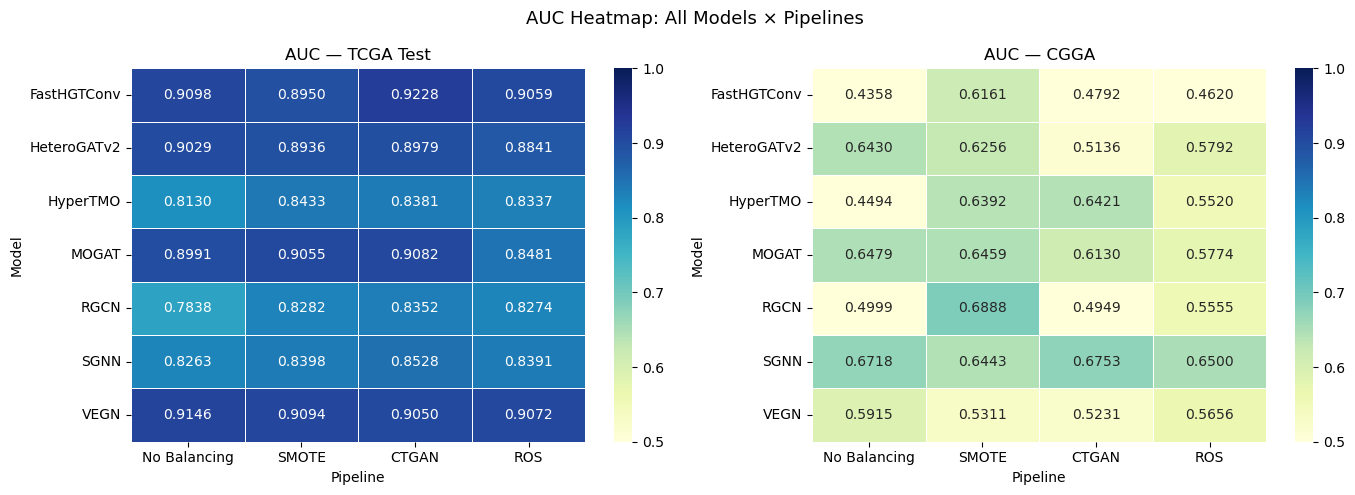

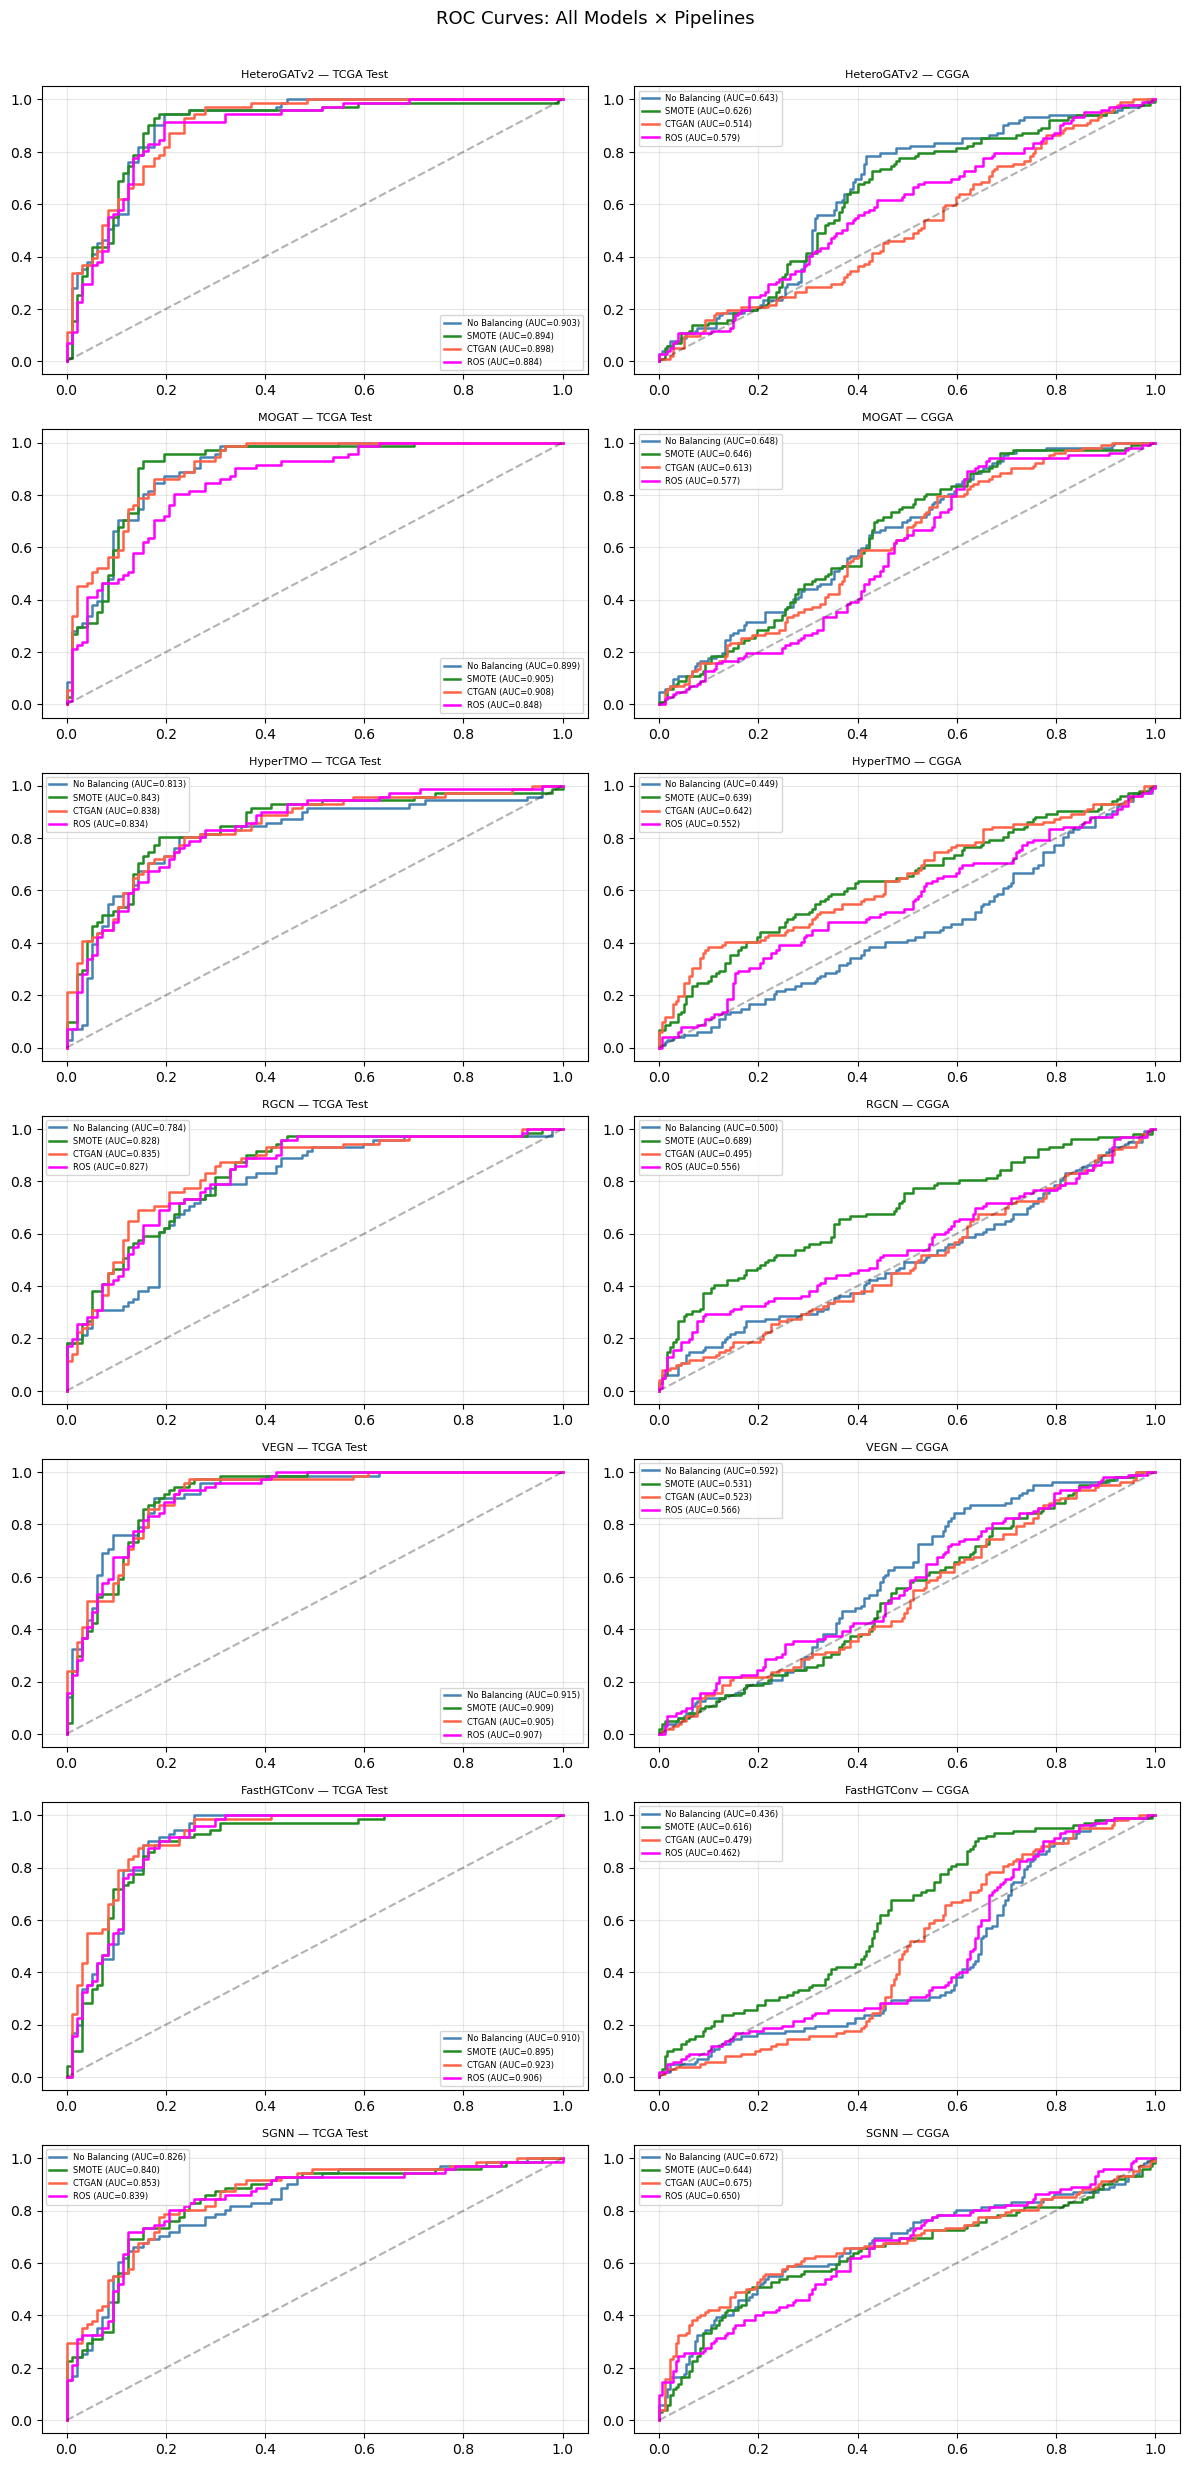

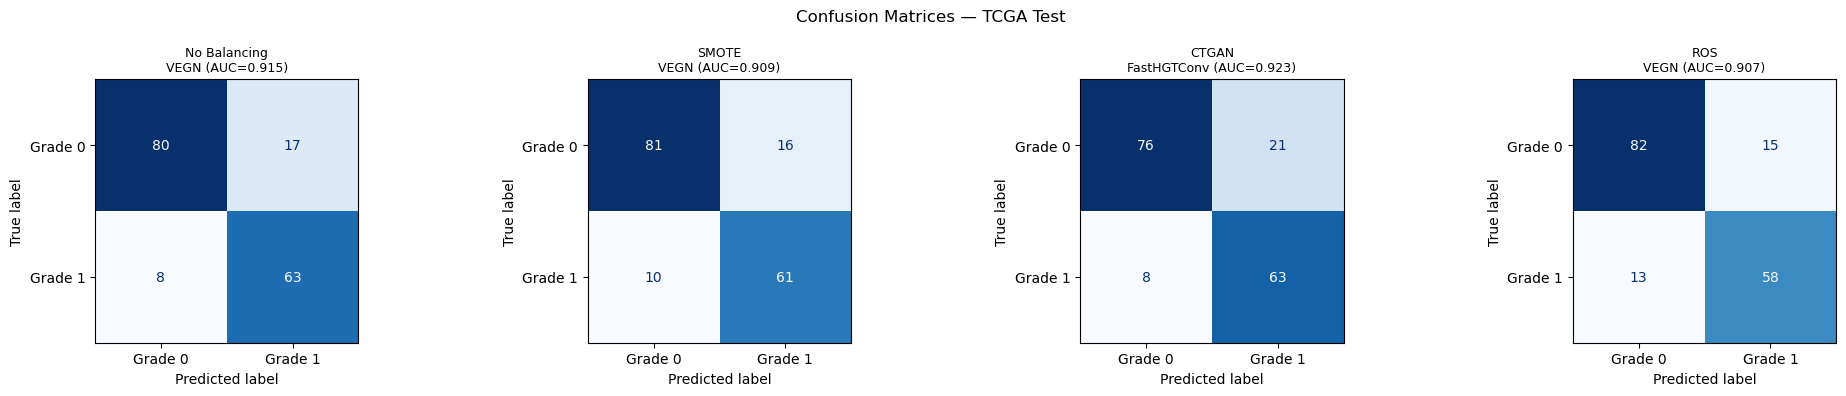

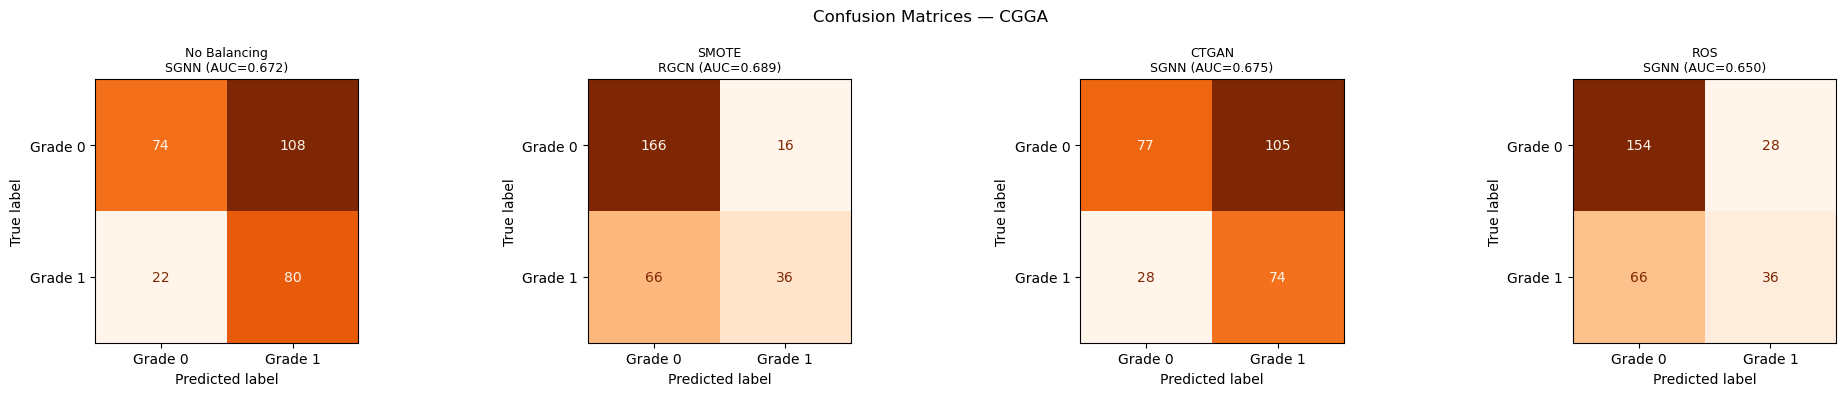

In [44]:
# ============================================================================
# 18. Heatmaps + ROC + Confusion Matrices
# ============================================================================
results_full = pd.DataFrame(all_results)

# AUC Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ds in zip(axes, ['TCGA Test', 'CGGA']):
    pivot = (results_df[results_df.Dataset == ds]
             .pivot_table(index='Model', columns='Pipeline', values='AUC', aggfunc='mean')
             .reindex(columns=PIPELINES))
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu',
                linewidths=0.5, ax=ax, vmin=0.5, vmax=1.0)
    ax.set_title(f'AUC — {ds}')
plt.suptitle('AUC Heatmap: All Models × Pipelines', fontsize=13)
plt.tight_layout(); plt.savefig('V16_auc_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()

# ROC Curves
model_names = [n for n, _, _ in MODEL_REGISTRY]
pipe_colors = {'No Balancing':'steelblue','SMOTE':'forestgreen','CTGAN':'tomato','ROS':'magenta'}

fig, axes = plt.subplots(len(model_names), 2, figsize=(12, 3.5*len(model_names)))
for row, mname in enumerate(model_names):
    for col, ds in enumerate(['TCGA Test', 'CGGA']):
        ax = axes[row, col]
        for pipe in PIPELINES:
            sub = results_full[(results_full.Model==mname) &
                                (results_full.Pipeline==pipe) &
                                (results_full.Dataset==ds)]
            if sub.empty: continue
            r = sub.iloc[0]
            fpr, tpr, _ = roc_curve(r['labels'], r['probs'])
            ax.plot(fpr, tpr, color=pipe_colors[pipe], lw=1.8,
                    label=f"{pipe} (AUC={r['auc']:.3f})")
        ax.plot([0,1],[0,1],'k--', alpha=0.3)
        ax.set_title(f"{mname} — {ds}", fontsize=8)
        ax.legend(fontsize=6); ax.grid(alpha=0.3)
plt.suptitle('ROC Curves: All Models × Pipelines', fontsize=13, y=1.005)
plt.tight_layout(); plt.savefig('V16_roc_grid.png', dpi=150, bbox_inches='tight'); plt.show()

# Confusion Matrices
for ds in ['TCGA Test', 'CGGA']:
    fig, axes = plt.subplots(1, len(PIPELINES), figsize=(5*len(PIPELINES), 4))
    cmap = 'Blues' if ds == 'TCGA Test' else 'Oranges'
    for pi, pipe in enumerate(PIPELINES):
        sub  = results_full[(results_full.Dataset==ds) & (results_full.Pipeline==pipe)]
        if sub.empty: continue
        best = sub.loc[sub['auc'].idxmax()]
        th   = best['threshold']
        preds = (best['probs'] >= th).astype(int)
        cm    = confusion_matrix(best['labels'], preds)
        ConfusionMatrixDisplay(cm, display_labels=['Grade 0','Grade 1']).plot(
            ax=axes[pi], cmap=cmap, colorbar=False)
        axes[pi].set_title(f"{pipe}\n{best['Model']} (AUC={best['auc']:.3f})", fontsize=9)
    plt.suptitle(f'Confusion Matrices — {ds}', fontsize=12)
    plt.tight_layout(); plt.savefig(f'V16_cm_{ds.replace(" ","_")}.png', dpi=150, bbox_inches='tight'); plt.show()

In [45]:
# ============================================================================
# 19. XAI Helpers
# ============================================================================
CLINICAL_FEAT_NAMES = ['Gender','Race_White','Race_Black','Race_Asian','Race_NativeAm','Age_norm']


def edge_occlusion_attribution(model, graph, patient_idx):
    model.eval()
    cpu_ei = graph[('Gene','mutates','Patient')].edge_index.cpu()
    with torch.no_grad():
        base_prob = F.softmax(model(graph), 1)[patient_idx, 1].item()
    pat_edge_idxs = (cpu_ei[1] == patient_idx).nonzero(as_tuple=True)[0].tolist()
    if not pat_edge_idxs:
        return {}, base_prob
    importances = {}
    orig_g2p = graph[('Gene','mutates','Patient')].edge_index
    has_p2g  = ('Patient','mutated_by','Gene') in graph.edge_index_dict
    if has_p2g:
        orig_p2g = graph[('Patient','mutated_by','Gene')].edge_index
        cpu_p2g  = orig_p2g.cpu()
    for e_idx in pat_edge_idxs:
        gene_idx  = int(cpu_ei[0, e_idx])
        gene_name = gene_columns[gene_idx] if gene_idx < len(gene_columns) else f'G{gene_idx}'
        keep_g2p = torch.ones(cpu_ei.shape[1], dtype=torch.bool)
        keep_g2p[e_idx] = False
        graph[('Gene','mutates','Patient')].edge_index = orig_g2p[:, keep_g2p].to(device)
        if has_p2g:
            keep_p2g = ~((cpu_p2g[0] == patient_idx) & (cpu_p2g[1] == gene_idx))
            graph[('Patient','mutated_by','Gene')].edge_index = orig_p2g[:, keep_p2g].to(device)
        with torch.no_grad():
            try:    mod_prob = F.softmax(model(graph), 1)[patient_idx, 1].item()
            except: mod_prob = base_prob
        graph[('Gene','mutates','Patient')].edge_index = orig_g2p
        if has_p2g:
            graph[('Patient','mutated_by','Gene')].edge_index = orig_p2g
        importances[gene_name] = round(base_prob - mod_prob, 6)
    return importances, base_prob


def integrated_gradients_clinical(model, graph, patient_idx, n_steps=50):
    model.eval()
    x_orig = graph['Patient'].x.detach()
    x_act  = x_orig[patient_idx]
    label  = int(graph['Patient'].y[patient_idx])
    acc_g  = torch.zeros(x_act.shape[0], device=device)
    for step in range(n_steps):
        alpha = step / max(n_steps - 1, 1)
        x_mod = x_orig.clone()
        x_mod[patient_idx] = alpha * x_act
        x_mod.requires_grad_(True)
        old_x = graph['Patient'].x
        graph['Patient'].x = x_mod
        score = F.softmax(model(graph), 1)[patient_idx, label]
        score.backward()
        graph['Patient'].x = old_x
        if x_mod.grad is not None:
            acc_g += x_mod.grad[patient_idx].detach()
    return (x_act * acc_g / n_steps).cpu().numpy()


def _extract_attn(model, graph):
    model.eval()
    with torch.no_grad():
        eidx, alpha = model.get_attn_weights(graph)
    return eidx[0].cpu().numpy(), eidx[1].cpu().numpy(), alpha.cpu().numpy()


def _build_attn_matrix(gene_ids, pat_ids, weights, n_genes, n_pat):
    mat = np.zeros((n_genes, n_pat))
    for g, p, w in zip(gene_ids, pat_ids, weights):
        if 0 <= g < n_genes and 0 <= p < n_pat:
            mat[g, p] = w
    return mat


def _gene_entropy(mat, eps=1e-9):
    out = []
    for row in mat:
        p = row + eps; p /= p.sum()
        out.append(float(-np.sum(p * np.log2(p))))
    return np.array(out)


def _has_attn(model):
    return hasattr(model, 'get_attn_weights') and hasattr(model, 'get_all_heads_attn')

def _is_mogat(model):
    return isinstance(model, MOGAT)

def _is_hgat(model):
    return isinstance(model, HeteroGATv2)

  TCGA best: FastHGTConv/CTGAN  AUC=0.9228
  CGGA best: RGCN/SMOTE  AUC=0.6888

Edge Occlusion — FastHGTConv/CTGAN on TCGA Test (168 patients)
  Top-5: ['IDH1', 'IDH2', 'NF1', 'MUC16', 'PTEN']


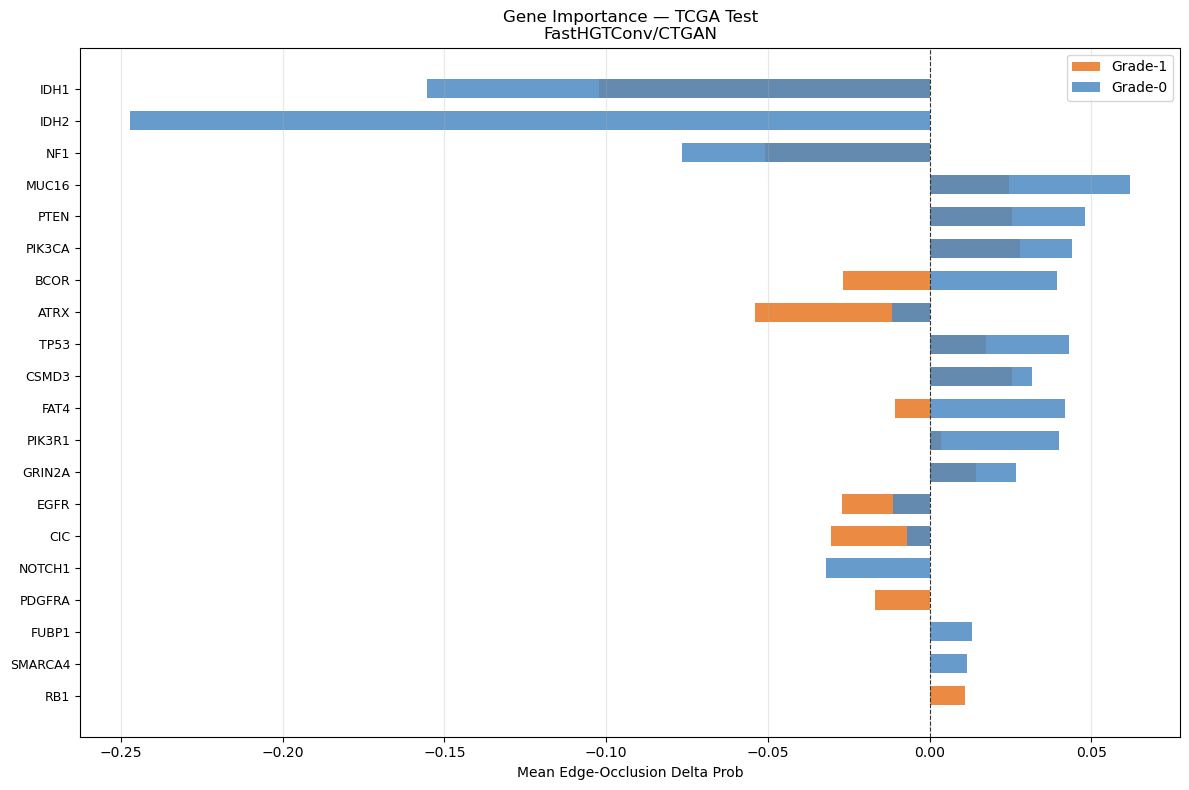


Edge Occlusion — RGCN/SMOTE on CGGA (284 patients)
  Top-5: ['ATRX', 'BCOR', 'CIC', 'CSMD3', 'EGFR']


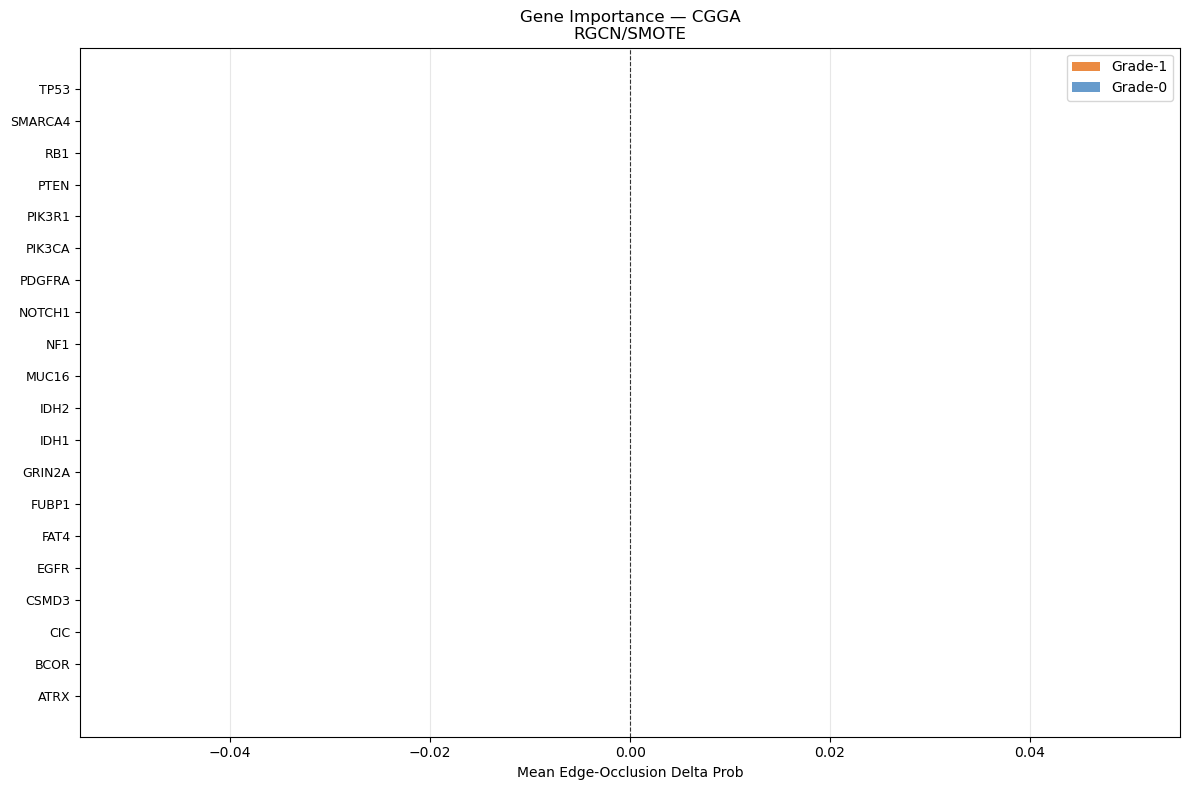


Integrated Gradients — FastHGTConv/CTGAN on TCGA Test
  Top-5: [{'feature': 'IDH2', 'importance': 0.247075}, {'feature': 'IDH1', 'importance': 0.1526137037037037}, {'feature': 'Age_norm', 'importance': 0.14218375912751072}, {'feature': 'NF1', 'importance': 0.06935684615384616}, {'feature': 'Race_White', 'importance': 0.06780357197858393}]


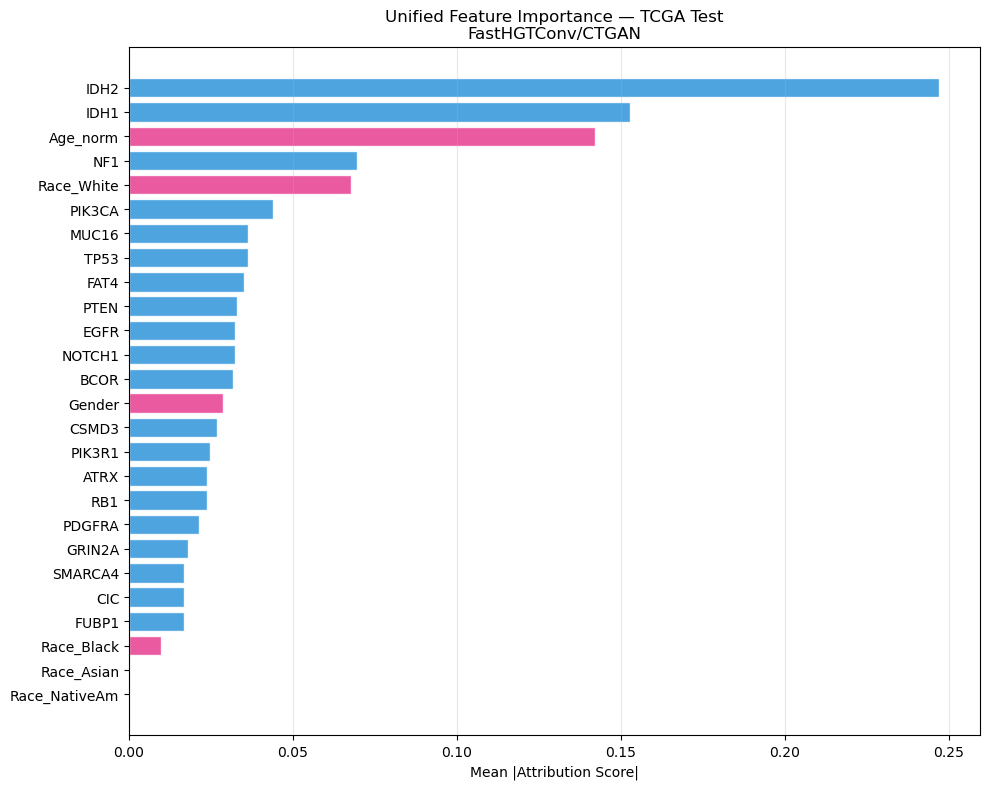


Integrated Gradients — RGCN/SMOTE on CGGA
  Top-5: [{'feature': 'Age_norm', 'importance': 0.07347280124668032}, {'feature': 'Race_Asian', 'importance': 0.03410058716641894}, {'feature': 'Gender', 'importance': 0.026978433442612488}, {'feature': 'CIC', 'importance': 0.0}, {'feature': 'EGFR', 'importance': 0.0}]


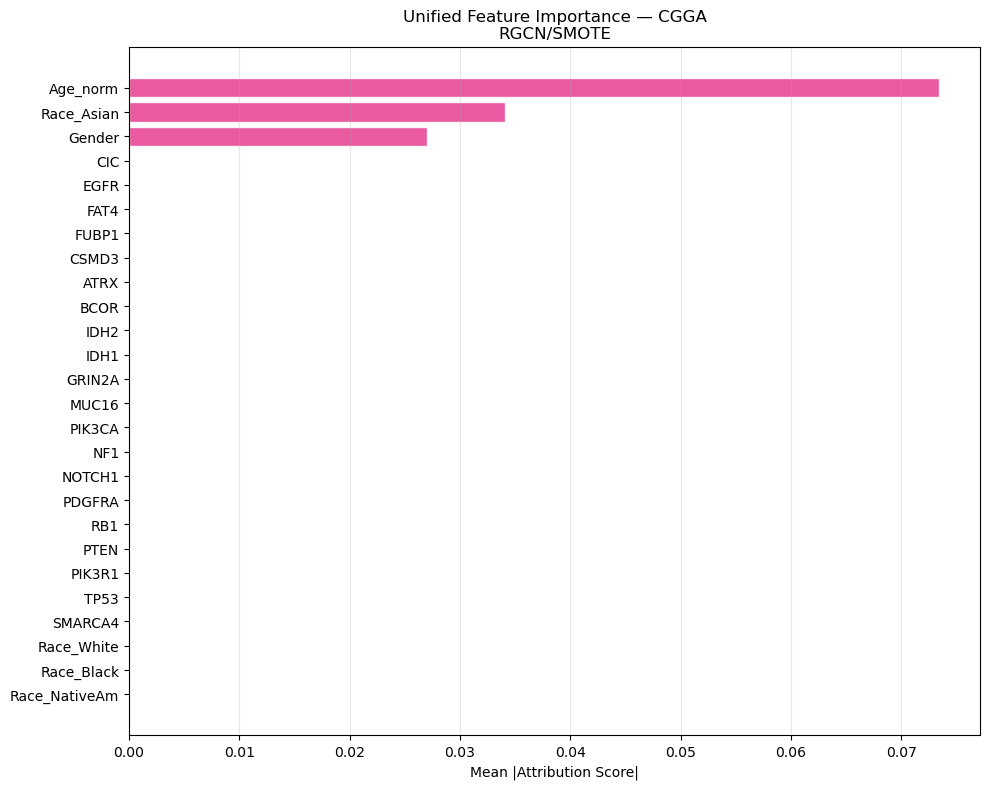


Grade-Stratified Occlusion (fallback) — FastHGTConv/CTGAN/TCGA Test


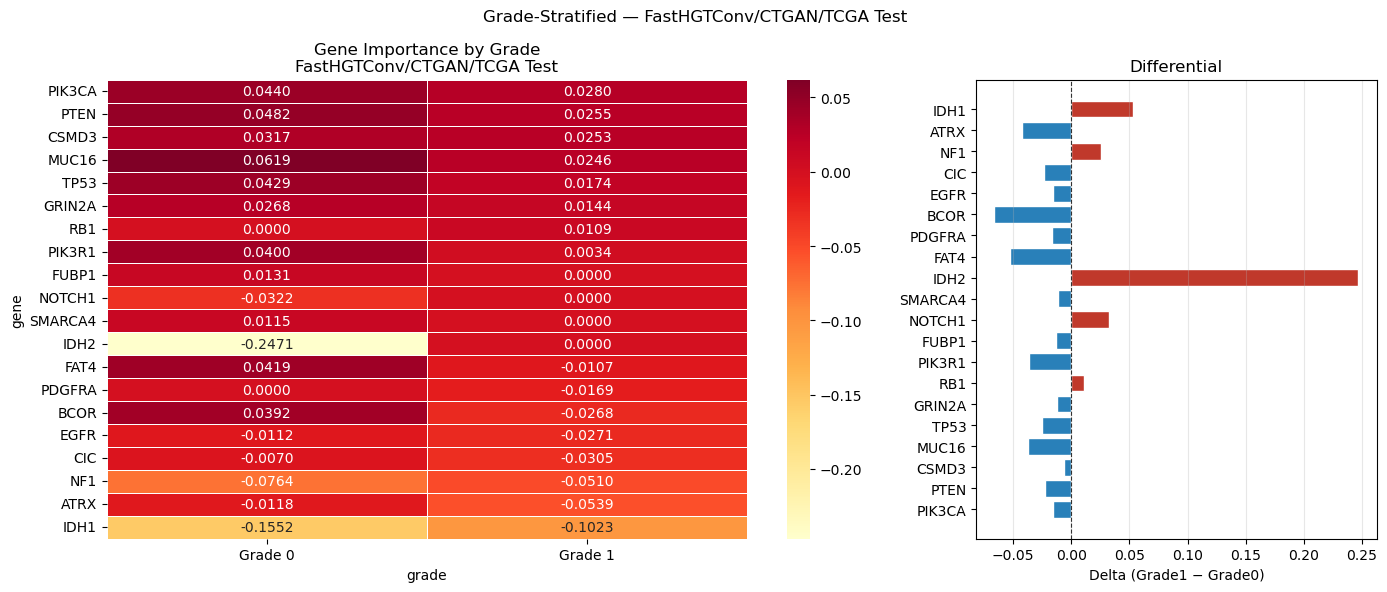


Grade-Stratified Occlusion (fallback) — RGCN/SMOTE/CGGA


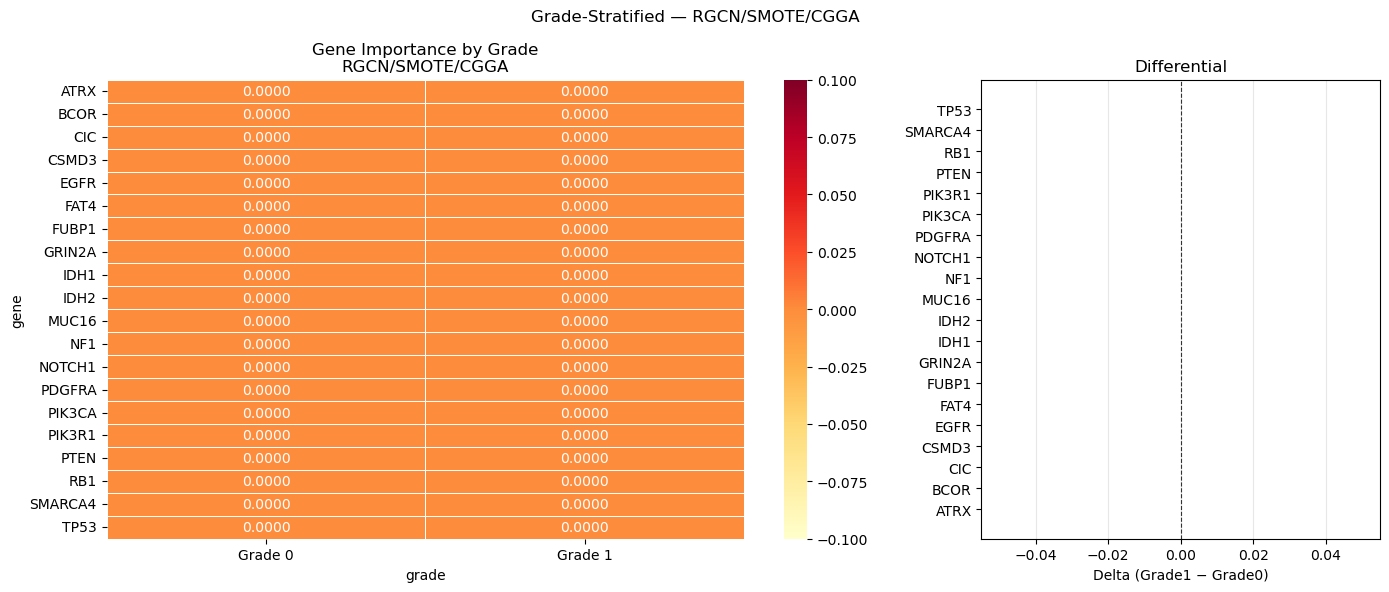


  FastHGTConv/CTGAN/TCGA Test: no attention — skipping entropy

  RGCN/SMOTE/CGGA: no attention — skipping entropy

Consensus — FastHGTConv on TCGA Test


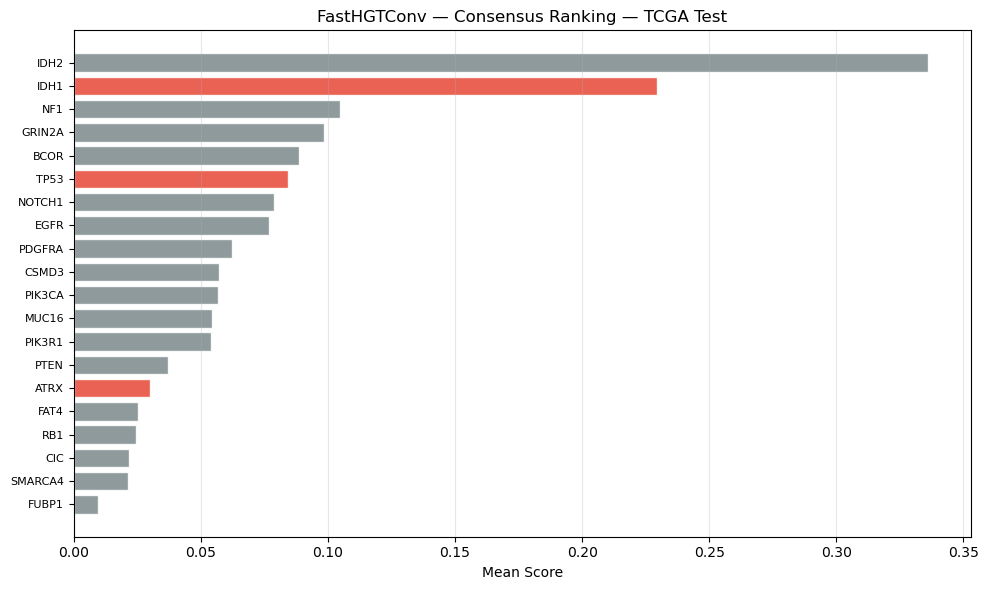


Consensus — FastHGTConv on CGGA


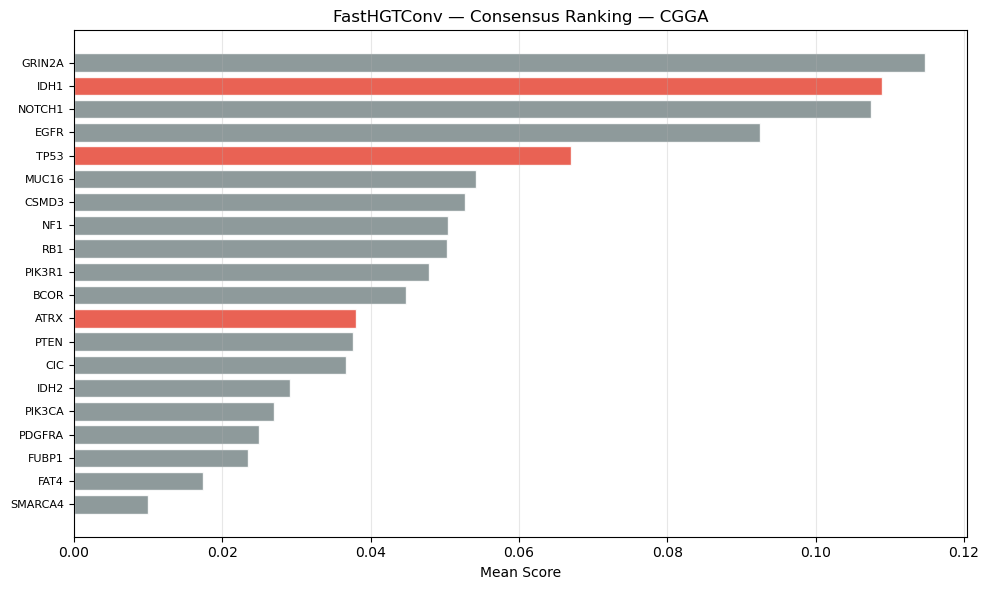


Consensus — RGCN on TCGA Test


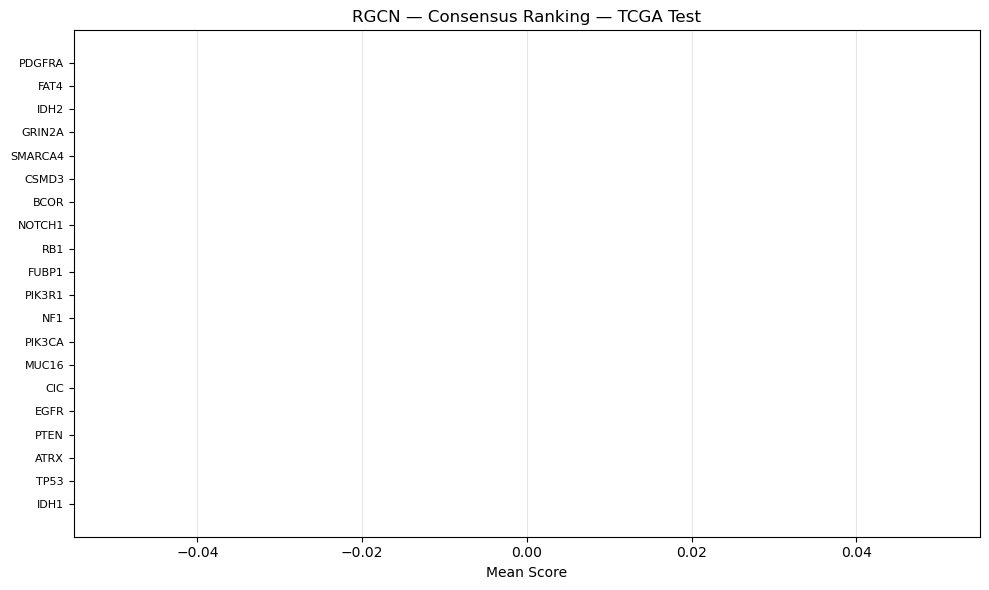


Consensus — RGCN on CGGA


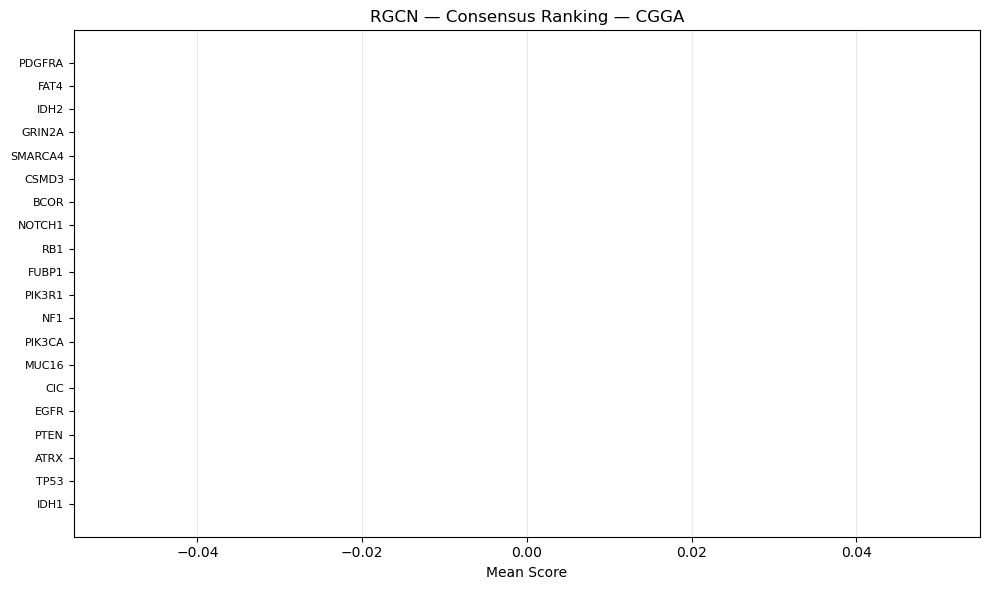

In [46]:
# ============================================================================
# 20. XAI — Auto Best Model Selection + Run All Methods
# ============================================================================
_rf = pd.DataFrame([
    {'Model': r['Model'], 'Pipeline': r['Pipeline'],
     'auc': r['auc'], 'Dataset': r['Dataset']}
    for r in all_results
])

_best_tcga = _rf[_rf.Dataset == 'TCGA Test'].sort_values('auc', ascending=False).iloc[0]
XAI_MODEL_TCGA    = _best_tcga['Model']
XAI_PIPELINE_TCGA = _best_tcga['Pipeline']
xai_model_tcga    = all_models[(XAI_MODEL_TCGA, XAI_PIPELINE_TCGA)]

_best_cgga = _rf[_rf.Dataset == 'CGGA'].sort_values('auc', ascending=False).iloc[0]
XAI_MODEL_CGGA    = _best_cgga['Model']
XAI_PIPELINE_CGGA = _best_cgga['Pipeline']
xai_model_cgga    = all_models[(XAI_MODEL_CGGA, XAI_PIPELINE_CGGA)]

_same_model = (XAI_MODEL_TCGA == XAI_MODEL_CGGA and XAI_PIPELINE_TCGA == XAI_PIPELINE_CGGA)

XAI_TARGETS = [(XAI_MODEL_TCGA, XAI_PIPELINE_TCGA, xai_model_tcga,
                float(all_thresholds.get((XAI_MODEL_TCGA, XAI_PIPELINE_TCGA), 0.5)),
                test_graph, test_df, 'TCGA Test')]
if not _same_model:
    XAI_TARGETS.append((XAI_MODEL_CGGA, XAI_PIPELINE_CGGA, xai_model_cgga,
                         float(all_thresholds.get((XAI_MODEL_CGGA, XAI_PIPELINE_CGGA), 0.5)),
                         cgga_graph, cgga_df, 'CGGA'))

print("=" * 70)
print(f"  TCGA best: {XAI_MODEL_TCGA}/{XAI_PIPELINE_TCGA}  AUC={_best_tcga['auc']:.4f}")
print(f"  CGGA best: {XAI_MODEL_CGGA}/{XAI_PIPELINE_CGGA}  AUC={_best_cgga['auc']:.4f}")
print("=" * 70)


# ── XAI Method 1: Edge Occlusion ────────────────────────────────────────────
def full_population_attribution(model, graph, df_ref):
    model.eval()
    labels = graph['Patient'].y.cpu().numpy()
    records = []
    for pidx in range(len(labels)):
        imp, base_prob = edge_occlusion_attribution(model, graph, int(pidx))
        mut_genes = [g for g in gene_columns if df_ref.iloc[pidx][g] == 1] if df_ref is not None else []
        for gname, delta in imp.items():
            records.append({'patient_idx': int(pidx), 'gene': gname,
                            'delta_prob': delta, 'grade': int(labels[pidx]),
                            'base_prob': base_prob, 'mutated': gname in mut_genes})
    return pd.DataFrame(records)


xai_occlusion_results = {}
for mname, pipe, model, threshold, primary_graph, primary_df, ds_label in XAI_TARGETS:
    print(f"\nEdge Occlusion — {mname}/{pipe} on {ds_label} ({primary_graph['Patient'].x.shape[0]} patients)")
    full_attr = full_population_attribution(model, primary_graph, primary_df)
    agg = (full_attr.groupby(['gene','grade'])['delta_prob']
           .mean().unstack('grade').fillna(0)
           .rename(columns={0:'Grade0_imp', 1:'Grade1_imp'}))
    agg['overall'] = (agg['Grade0_imp'].abs() + agg['Grade1_imp'].abs()) / 2
    agg['discriminability'] = agg['Grade1_imp'] - agg['Grade0_imp']
    agg = agg.sort_values('overall', ascending=False)
    xai_occlusion_results[ds_label] = (full_attr, agg)
    print(f"  Top-5: {agg['overall'].nlargest(5).index.tolist()}")

    safe = f"{mname}_{pipe}_{ds_label}".replace(' ','_').replace('/','_')
    genes_sorted = agg.sort_values('overall', ascending=True).index.tolist()
    fig, ax = plt.subplots(figsize=(12, 8))
    y = np.arange(len(genes_sorted))
    ax.barh(y, [agg.loc[g,'Grade1_imp'] for g in genes_sorted], color='#E87722', alpha=0.85, label='Grade-1', height=0.6)
    ax.barh(y, [agg.loc[g,'Grade0_imp'] for g in genes_sorted], color='#4C8AC4', alpha=0.85, label='Grade-0', height=0.6)
    ax.set_yticks(y); ax.set_yticklabels(genes_sorted, fontsize=9)
    ax.axvline(0, color='#333', lw=0.8, ls='--')
    ax.set_xlabel('Mean Edge-Occlusion Delta Prob'); ax.set_title(f'Gene Importance — {ds_label}\n{mname}/{pipe}')
    ax.legend(); ax.grid(axis='x', alpha=0.3)
    plt.tight_layout(); plt.savefig(f'V16_xai_occlusion_{safe}.png', dpi=150, bbox_inches='tight'); plt.show()


# ── XAI Method 2: Integrated Gradients ──────────────────────────────────────
xai_ig_results = {}
for mname, pipe, model, threshold, primary_graph, primary_df, ds_label in XAI_TARGETS:
    print(f"\nIntegrated Gradients — {mname}/{pipe} on {ds_label}")
    model.eval()
    labels = primary_graph['Patient'].y.cpu().numpy()
    rng = np.random.default_rng(42)
    idx0 = np.where(labels == 0)[0]; idx1 = np.where(labels == 1)[0]
    half = min(30, len(idx0), len(idx1))
    sel  = np.concatenate([rng.choice(idx0, half, replace=False), rng.choice(idx1, half, replace=False)])
    records = []
    for pidx in sel:
        ig  = integrated_gradients_clinical(model, primary_graph, int(pidx), n_steps=30)
        row = {'patient_idx': int(pidx), 'grade': int(labels[pidx])}
        for fname, val in zip(CLINICAL_FEAT_NAMES, ig):
            row[fname] = float(val)
        records.append(row)
    clin_df = pd.DataFrame(records)
    overall_clin = clin_df[CLINICAL_FEAT_NAMES].abs().mean().sort_values(ascending=False)

    if ds_label in xai_occlusion_results:
        gene_imp = (xai_occlusion_results[ds_label][0]
                    .groupby('gene')['delta_prob']
                    .apply(lambda x: x.abs().mean())
                    .sort_values(ascending=False))
    else:
        gene_imp = pd.Series(dtype=float)

    unified = pd.concat([
        gene_imp.rename('importance').reset_index().rename(columns={'gene':'feature'}),
        pd.DataFrame({'feature': overall_clin.index, 'importance': overall_clin.values})
    ]).sort_values('importance', ascending=False).reset_index(drop=True)
    unified['type'] = unified['feature'].apply(
        lambda f: 'Clinical' if f in CLINICAL_FEAT_NAMES else 'Gene Mutation')
    xai_ig_results[ds_label] = (clin_df, unified)
    print(f"  Top-5: {unified.head(5)[['feature','importance']].to_dict('records')}")

    safe = f"{mname}_{pipe}_{ds_label}".replace(' ','_').replace('/','_')
    fig, ax = plt.subplots(figsize=(10, 8))
    colors_u = ['#e84393' if t == 'Clinical' else '#3498db' for t in unified['type']]
    ax.barh(unified['feature'][::-1], unified['importance'][::-1],
            color=colors_u[::-1], edgecolor='white', alpha=0.88)
    ax.set_xlabel('Mean |Attribution Score|')
    ax.set_title(f'Unified Feature Importance — {ds_label}\n{mname}/{pipe}')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout(); plt.savefig(f'V16_xai_ig_{safe}.png', dpi=150, bbox_inches='tight'); plt.show()


# ── XAI Method 3: Grade-Stratified Attention ────────────────────────────────
xai_grade_results = {}
for mname, pipe, model, threshold, primary_graph, primary_df, ds_label in XAI_TARGETS:
    title = f"{mname}/{pipe}/{ds_label}"
    if _has_attn(model):
        print(f"\nGrade-Stratified Attention — {title}")
        gids, pids, ws = _extract_attn(model, primary_graph)
        labels = primary_graph['Patient'].y.cpu().numpy()
        n_p = primary_graph['Patient'].x.shape[0]
        mat = _build_attn_matrix(gids, pids, ws, NUM_GENES, n_p)
        g0_mean = mat[:, labels == 0].mean(axis=1)
        g1_mean = mat[:, labels == 1].mean(axis=1)
        delta   = g1_mean - g0_mean
        df_h = pd.DataFrame({'Grade 0': g0_mean, 'Grade 1': g1_mean, 'Delta': delta},
                             index=gene_columns).sort_values('Grade 1', ascending=False)
    else:
        print(f"\nGrade-Stratified Occlusion (fallback) — {title}")
        if ds_label in xai_occlusion_results:
            df_h = (xai_occlusion_results[ds_label][0].groupby(['gene','grade'])['delta_prob']
                    .mean().unstack('grade').fillna(0)
                    .rename(columns={0:'Grade 0', 1:'Grade 1'}))
            df_h['Delta'] = df_h['Grade 1'] - df_h['Grade 0']
            df_h = df_h.sort_values('Grade 1', ascending=False)
        else:
            continue
    xai_grade_results[ds_label] = df_h

    safe = title.replace('/','_').replace(' ','_')
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [2, 1]})
    sns.heatmap(df_h[['Grade 0','Grade 1']], annot=True, fmt='.4f', cmap='YlOrRd',
                linewidths=0.4, ax=axes[0])
    axes[0].set_title(f'Gene Importance by Grade\n{title}')
    dcols = ['#c0392b' if v > 0 else '#2980b9' for v in df_h['Delta']]
    axes[1].barh(df_h.index, df_h['Delta'], color=dcols, edgecolor='white')
    axes[1].axvline(0, color='#333', lw=0.8, ls='--')
    axes[1].set_xlabel('Delta (Grade1 − Grade0)')
    axes[1].set_title('Differential'); axes[1].grid(axis='x', alpha=0.3)
    plt.suptitle(f'Grade-Stratified — {title}')
    plt.tight_layout(); plt.savefig(f'V16_xai_grade_attn_{safe}.png', dpi=150, bbox_inches='tight'); plt.show()


# ── XAI Method 4: Attention Entropy ─────────────────────────────────────────
for mname, pipe, model, threshold, primary_graph, primary_df, ds_label in XAI_TARGETS:
    title = f"{mname}/{pipe}/{ds_label}"
    if not _has_attn(model):
        print(f"\n  {title}: no attention — skipping entropy")
        continue
    print(f"\nAttention Entropy — {title}")
    gids, pids, ws = _extract_attn(model, primary_graph)
    n_p = primary_graph['Patient'].x.shape[0]
    mat = _build_attn_matrix(gids, pids, ws, NUM_GENES, n_p)
    entropies = _gene_entropy(mat)
    means = np.array([row[row > 0].mean() if (row > 0).any() else 0.0 for row in mat])

    safe = title.replace('/','_').replace(' ','_')
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    ent_order = np.argsort(entropies)
    axes[0].barh([gene_columns[i] for i in ent_order], entropies[ent_order],
                  color=plt.cm.RdYlGn_r(entropies[ent_order] / (entropies.max() + 1e-9)),
                  edgecolor='white')
    axes[0].set_xlabel('Shannon Entropy (bits)')
    axes[0].set_title(f'Gene Attention Entropy\n{title}'); axes[0].grid(axis='x', alpha=0.3)

    axes[1].scatter(entropies, means, s=70, edgecolors='#333', linewidths=0.5, zorder=3)
    for i, g in enumerate(gene_columns):
        axes[1].annotate(g, (entropies[i], means[i]), textcoords='offset points', xytext=(3,2), fontsize=7)
    axes[1].set_xlabel('Entropy (bits)'); axes[1].set_ylabel('Mean Attention')
    axes[1].set_title(f'Entropy vs Mean Attention'); axes[1].grid(alpha=0.3)
    plt.suptitle(f'Attention Entropy — {title}')
    plt.tight_layout(); plt.savefig(f'V16_xai_entropy_{safe}.png', dpi=150, bbox_inches='tight'); plt.show()

    entropy_df = pd.DataFrame({'gene': gene_columns, 'entropy': entropies, 'mean_attn': means}).sort_values('entropy')
    print(f"  Most selective (lowest H): {entropy_df.head(3)['gene'].tolist()}")


# ── XAI Method 5: Cross-Pipeline Consensus ──────────────────────────────────
xai_consensus_results = {}
_arch_seen = set()
for mname, pipe, model, threshold, primary_graph, primary_df, ds_label in XAI_TARGETS:
    if mname in _arch_seen: continue
    _arch_seen.add(mname)

    for graph_label, graph_obj, ref_df in [('TCGA Test', test_graph, test_df), ('CGGA', cgga_graph, cgga_df)]:
        print(f"\nConsensus — {mname} on {graph_label}")
        pipe_scores = {}
        for p in PIPELINES:
            m = all_models.get((mname, p))
            if m is None: continue
            m.eval()
            if _has_attn(m):
                gids, pids, ws = _extract_attn(m, graph_obj)
                n_p = graph_obj['Patient'].x.shape[0]
                mat = _build_attn_matrix(gids, pids, ws, NUM_GENES, n_p)
                gene_scores = pd.Series(mat.mean(axis=1), index=gene_columns)
            else:
                attr_df = full_population_attribution(m, graph_obj, ref_df)
                gene_scores = (attr_df.groupby('gene')['delta_prob']
                               .apply(lambda x: x.abs().mean())
                               .reindex(gene_columns, fill_value=0))
            pipe_scores[p] = gene_scores

        if not pipe_scores: continue
        consensus_df = pd.DataFrame(pipe_scores).fillna(0)
        consensus_df['mean_score'] = consensus_df.mean(axis=1)
        consensus_df['mean_rank']  = consensus_df[PIPELINES].rank(ascending=False).mean(axis=1)
        consensus_df = consensus_df.sort_values('mean_score', ascending=False)
        xai_consensus_results.setdefault(mname, {})[graph_label] = consensus_df

        safe = f"{mname}_{graph_label}".replace(' ','_')
        fig, ax = plt.subplots(figsize=(10, 6))
        score_s = consensus_df['mean_score'].sort_values(ascending=True)
        ax.barh(range(len(score_s)), score_s.values,
                color=['#e74c3c' if g in ['IDH1','ATRX','TP53'] else '#7f8c8d' for g in score_s.index],
                edgecolor='white', alpha=0.88)
        ax.set_yticks(range(len(score_s))); ax.set_yticklabels(score_s.index, fontsize=8)
        ax.set_xlabel('Mean Score'); ax.set_title(f'{mname} — Consensus Ranking — {graph_label}')
        ax.grid(axis='x', alpha=0.3)
        plt.tight_layout(); plt.savefig(f'V16_xai_consensus_{safe}.png', dpi=150, bbox_inches='tight'); plt.show()

In [47]:
# ============================================================================
# Section A — Statistical Validation
# ============================================================================

def _structural_components(probs, labels):
    pos = probs[labels == 1]
    neg = probs[labels == 0]
    m, n = len(pos), len(neg)
    V10 = np.array([np.mean((p > neg) + 0.5 * (p == neg)) for p in pos])
    V01 = np.array([np.mean((pos > q) + 0.5 * (pos == q)) for q in neg])
    auc = V10.mean()
    var = (np.var(V10, ddof=1) / m + np.var(V01, ddof=1) / n)
    return auc, var, V10, V01


def delong_test(probs_a, probs_b, labels):
    auc_a, var_a, V10_a, V01_a = _structural_components(probs_a, labels)
    auc_b, var_b, V10_b, V01_b = _structural_components(probs_b, labels)
    m = (labels == 1).sum(); n = (labels == 0).sum()
    cov_10 = np.cov(V10_a, V10_b, ddof=1)[0, 1] / m
    cov_01 = np.cov(V01_a, V01_b, ddof=1)[0, 1] / n
    var_diff = var_a + var_b - 2 * (cov_10 + cov_01)
    if var_diff <= 0: return auc_a, auc_b, 0.0, 1.0
    z = (auc_a - auc_b) / np.sqrt(var_diff)
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return auc_a, auc_b, float(z), float(p)


def _get_result(model_name, pipeline, dataset='TCGA Test'):
    for r in all_results:
        if r['Model'] == model_name and r['Pipeline'] == pipeline and r['Dataset'] == dataset:
            return np.array(r['probs']), np.array(r['labels'])
    return None, None

# ── Auto-derive best model variables ─────────────────────────────────────────
_rf_auto = pd.DataFrame([
    {'Model': r['Model'], 'Pipeline': r['Pipeline'], 'auc': r['auc'], 'Dataset': r['Dataset']}
    for r in all_results
])
_best_tcga_s = _rf_auto[_rf_auto.Dataset == 'TCGA Test'].sort_values('auc', ascending=False).iloc[0]
BEST_MODEL_NAME_TCGA = _best_tcga_s['Model']
BEST_PIPELINE_TCGA   = _best_tcga_s['Pipeline']
BEST_BP_TCGA         = all_params[(BEST_MODEL_NAME_TCGA, BEST_PIPELINE_TCGA)]
BEST_MODEL_CLS_TCGA  = next(cls for n, cls, _ in MODEL_REGISTRY if n == BEST_MODEL_NAME_TCGA)
BEST_FKW_TCGA        = next(fkw for n, _, fkw in MODEL_REGISTRY if n == BEST_MODEL_NAME_TCGA)
BEST_THRESHOLD_TCGA  = float(all_thresholds.get((BEST_MODEL_NAME_TCGA, BEST_PIPELINE_TCGA), 0.5))

_best_cgga_s = _rf_auto[_rf_auto.Dataset == 'CGGA'].sort_values('auc', ascending=False).iloc[0]
BEST_MODEL_NAME_CGGA = _best_cgga_s['Model']
BEST_PIPELINE_CGGA   = _best_cgga_s['Pipeline']
BEST_BP_CGGA         = all_params[(BEST_MODEL_NAME_CGGA, BEST_PIPELINE_CGGA)]
BEST_MODEL_CLS_CGGA  = next(cls for n, cls, _ in MODEL_REGISTRY if n == BEST_MODEL_NAME_CGGA)
BEST_FKW_CGGA        = next(fkw for n, _, fkw in MODEL_REGISTRY if n == BEST_MODEL_NAME_CGGA)
BEST_THRESHOLD_CGGA  = float(all_thresholds.get((BEST_MODEL_NAME_CGGA, BEST_PIPELINE_CGGA), 0.5))

print(f"Best TCGA: {BEST_MODEL_NAME_TCGA}/{BEST_PIPELINE_TCGA}")
print(f"Best CGGA: {BEST_MODEL_NAME_CGGA}/{BEST_PIPELINE_CGGA}")

# ── A.1 DeLong: best vs second-best ─────────────────────────────────────────
pb_best, lb_best = _get_result(BEST_MODEL_NAME_TCGA, BEST_PIPELINE_TCGA)
_second = (_rf_auto[(_rf_auto.Dataset == 'TCGA Test') &
                    ~((_rf_auto.Model == BEST_MODEL_NAME_TCGA) & (_rf_auto.Pipeline == BEST_PIPELINE_TCGA))]
           .sort_values('auc', ascending=False).iloc[0])
pb_second, _ = _get_result(_second['Model'], _second['Pipeline'])
if pb_best is not None and pb_second is not None:
    auc_a, auc_b, z, p = delong_test(pb_best, pb_second, lb_best)
    print(f"\nDeLong: {BEST_MODEL_NAME_TCGA} AUC={auc_a:.4f} vs {_second['Model']} AUC={auc_b:.4f}")
    print(f"  Z={z:.3f}, p={p:.4f} {'*significant*' if p < 0.05 else 'ns'}")

# ── A.2 Bootstrap CIs ───────────────────────────────────────────────────────
def bootstrap_ci(probs, labels, preds, n_boot=10_000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    metrics_boot = {m: [] for m in ['auc', 'f1', 'recall_1', 'recall_0']}
    idx0, idx1 = np.where(labels == 0)[0], np.where(labels == 1)[0]
    for _ in range(n_boot):
        b = np.concatenate([rng.choice(idx0, len(idx0), replace=True),
                            rng.choice(idx1, len(idx1), replace=True)])
        lb, pb, pd_b = labels[b], probs[b], preds[b]
        try:    metrics_boot['auc'].append(roc_auc_score(lb, pb))
        except: metrics_boot['auc'].append(np.nan)
        metrics_boot['f1'].append(f1_score(lb, pd_b, zero_division=0))
        metrics_boot['recall_1'].append(recall_score(lb, pd_b, pos_label=1, zero_division=0))
        metrics_boot['recall_0'].append(recall_score(lb, pd_b, pos_label=0, zero_division=0))
    out = {}
    lo, hi = alpha / 2, 1 - alpha / 2
    for m, vals in metrics_boot.items():
        v = np.array(vals); v = v[~np.isnan(v)]
        out[m] = (float(np.percentile(v, lo*100)), float(np.percentile(v, hi*100)))
    return out

print("\nBootstrap 95% CIs (n=10000)...")
ci_records = []
_ci_targets = {(BEST_MODEL_NAME_TCGA, BEST_PIPELINE_TCGA, 'TCGA Test'),
               (BEST_MODEL_NAME_TCGA, BEST_PIPELINE_TCGA, 'CGGA'),
               (BEST_MODEL_NAME_CGGA, BEST_PIPELINE_CGGA, 'TCGA Test'),
               (BEST_MODEL_NAME_CGGA, BEST_PIPELINE_CGGA, 'CGGA')}
for mname, pipe, dataset in sorted(_ci_targets):
    pb, lb = _get_result(mname, pipe, dataset)
    if pb is None: continue
    th  = all_thresholds.get((mname, pipe), 0.5)
    pd_ = (pb >= th).astype(int)
    ci  = bootstrap_ci(pb, lb, pd_, n_boot=10_000)
    for metric, (lo, hi) in ci.items():
        ci_records.append({'Model': mname, 'Pipeline': pipe, 'Dataset': dataset,
                           'Metric': metric, 'Lower': lo, 'Upper': hi})
ci_df = pd.DataFrame(ci_records)
print(ci_df.to_string(index=False))
ci_df.to_csv('V16_bootstrap_ci.csv', index=False)

# ── A.3 McNemar tests ───────────────────────────────────────────────────────
def mcnemar_test(preds_a, preds_b, labels):
    correct_a = (preds_a == labels); correct_b = (preds_b == labels)
    b = ((correct_a) & (~correct_b)).sum()
    c = ((~correct_a) & (correct_b)).sum()
    if b + c == 0: return b, c, 0.0, 1.0, 'degenerate'
    if b + c <= 25:
        p = 2 * stats.binom.sf(max(b, c) - 1, b + c, 0.5)
        return b, c, float(max(b, c)), float(min(p, 1.0)), 'exact_binomial'
    stat = (abs(b - c) - 1) ** 2 / (b + c)
    p = stats.chi2.sf(stat, df=1)
    return b, c, float(stat), float(p), 'chi2_corrected'

print("\nMcNemar pairwise — CTGAN pipeline, TCGA Test")
ctgan_models = []
seen_ = set()
for r in all_results:
    if r['Pipeline'] == 'CTGAN' and r['Dataset'] == 'TCGA Test' and r['Model'] not in seen_:
        seen_.add(r['Model'])
        ctgan_models.append((r['Model'], r['Pipeline'], np.array(r['probs']), np.array(r['labels'])))

mcn_records = []
for i, (mn_a, pp_a, pb_a, lb_a) in enumerate(ctgan_models):
    th_a = all_thresholds.get((mn_a, pp_a), 0.5)
    pd_a = (pb_a >= th_a).astype(int)
    for j, (mn_b, pp_b, pb_b, lb_b) in enumerate(ctgan_models):
        if j <= i: continue
        th_b = all_thresholds.get((mn_b, pp_b), 0.5)
        pd_b = (pb_b >= th_b).astype(int)
        b, c, stat, p, method = mcnemar_test(pd_a, pd_b, lb_a)
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        print(f"  {mn_a:14s} vs {mn_b:14s}: b={b:3d} c={c:3d} p={p:.4f} {sig}")
        mcn_records.append({'ModelA': mn_a, 'ModelB': mn_b, 'b': b, 'c': c,
                             'stat': stat, 'p': p, 'sig': sig})
pd.DataFrame(mcn_records).to_csv('V16_mcnemar.csv', index=False)

Best TCGA: FastHGTConv/CTGAN
Best CGGA: RGCN/SMOTE

DeLong: FastHGTConv AUC=0.9228 vs VEGN AUC=0.9146
  Z=0.509, p=0.6106 ns

Bootstrap 95% CIs (n=10000)...
      Model Pipeline   Dataset   Metric    Lower    Upper
FastHGTConv    CTGAN      CGGA      auc 0.411765 0.546272
FastHGTConv    CTGAN      CGGA       f1 0.482079 0.572368
FastHGTConv    CTGAN      CGGA recall_1 0.705882 0.862745
FastHGTConv    CTGAN      CGGA recall_0 0.269231 0.401099
FastHGTConv    CTGAN TCGA Test      auc 0.880060 0.959344
FastHGTConv    CTGAN TCGA Test       f1 0.753247 0.870130
FastHGTConv    CTGAN TCGA Test recall_1 0.802817 0.957746
FastHGTConv    CTGAN TCGA Test recall_0 0.701031 0.865979
       RGCN    SMOTE      CGGA      auc 0.622332 0.754203
       RGCN    SMOTE      CGGA       f1 0.364964 0.562500
       RGCN    SMOTE      CGGA recall_1 0.264706 0.450980
       RGCN    SMOTE      CGGA recall_0 0.868132 0.950549
       RGCN    SMOTE TCGA Test      auc 0.763319 0.886602
       RGCN    SMOTE TCGA Test 


Section B — CTGAN Quality Assessment
Generating 85 synthetic minority patients...


Sampling conditions: 100%|██████████| 85/85 [00:00<00:00, 441.00it/s]


Real minority: 225 | Synthetic: 85
Feature tests: 16/23 pass
         Feature Test     stat      p  pass
Age_at_diagnosis   KS   0.4086 0.0000 False
            IDH1 chi2 217.6267 0.0000 False
            TP53 chi2   0.5903 0.4423  True
            ATRX chi2   0.5053 0.4772  True
            PTEN chi2   0.0874 0.7675  True
            EGFR chi2   3.6029 0.0577  True
             CIC chi2  36.7291 0.0000 False
           MUC16 chi2   0.4208 0.5165  True
          PIK3CA chi2   0.2204 0.6388  True
             NF1 chi2   0.3657 0.5454  True
          PIK3R1 chi2   1.2532 0.2629  True
           FUBP1 chi2  24.0576 0.0000 False
             RB1 chi2   0.0368 0.8479  True
          NOTCH1 chi2      NaN 1.0000  True
            BCOR chi2   0.0490 0.8248  True
           CSMD3 chi2   4.6489 0.0311 False
         SMARCA4 chi2   4.1735 0.0411 False
          GRIN2A chi2   0.1020 0.7495  True
            IDH2 chi2  52.0714 0.0000 False
            FAT4 chi2   1.3420 0.2467  True
          PDGFR

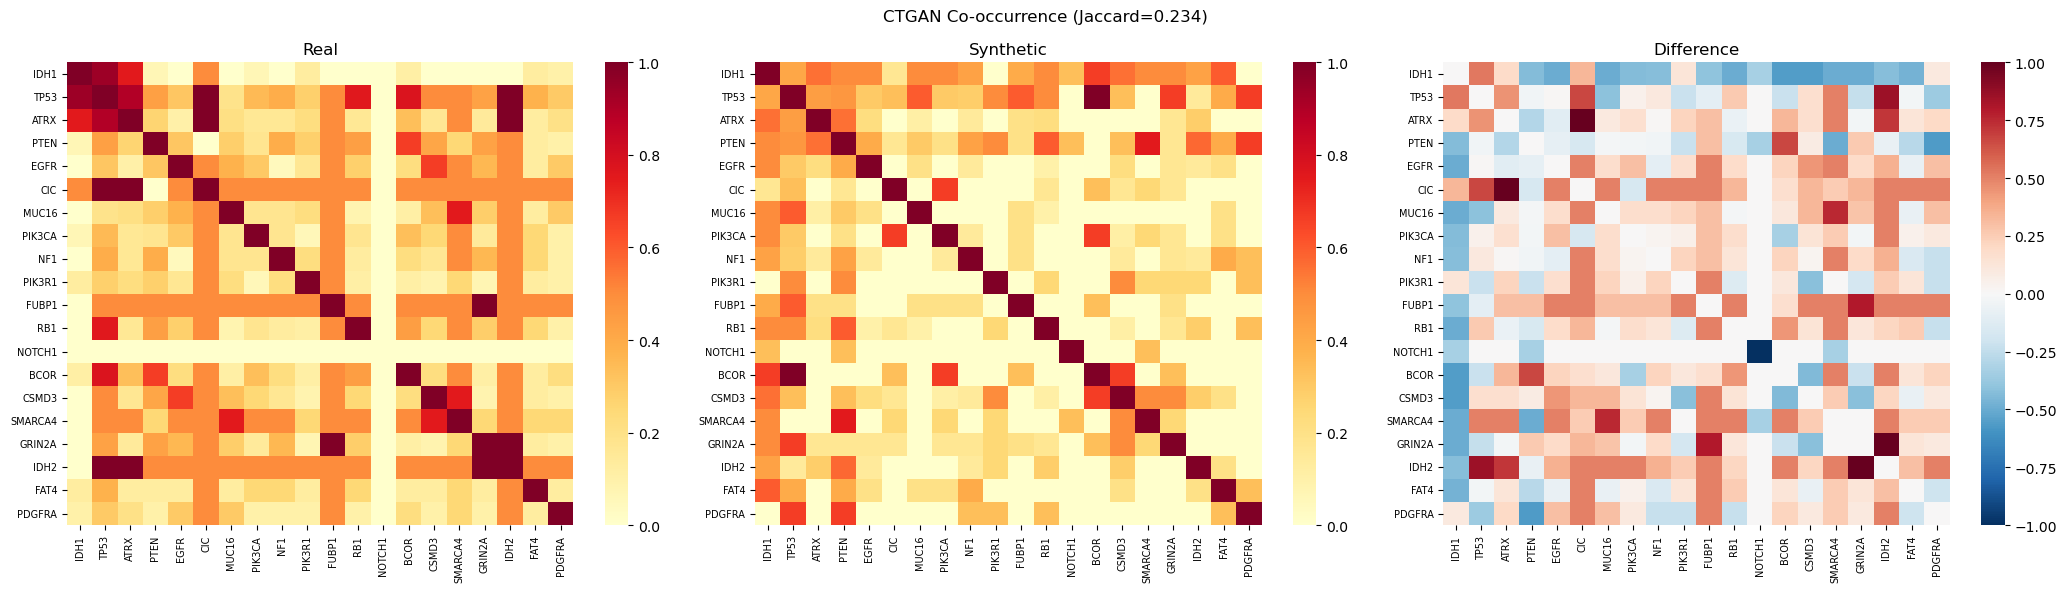

Correlation: Cosine=0.7169 RMSE=0.1832


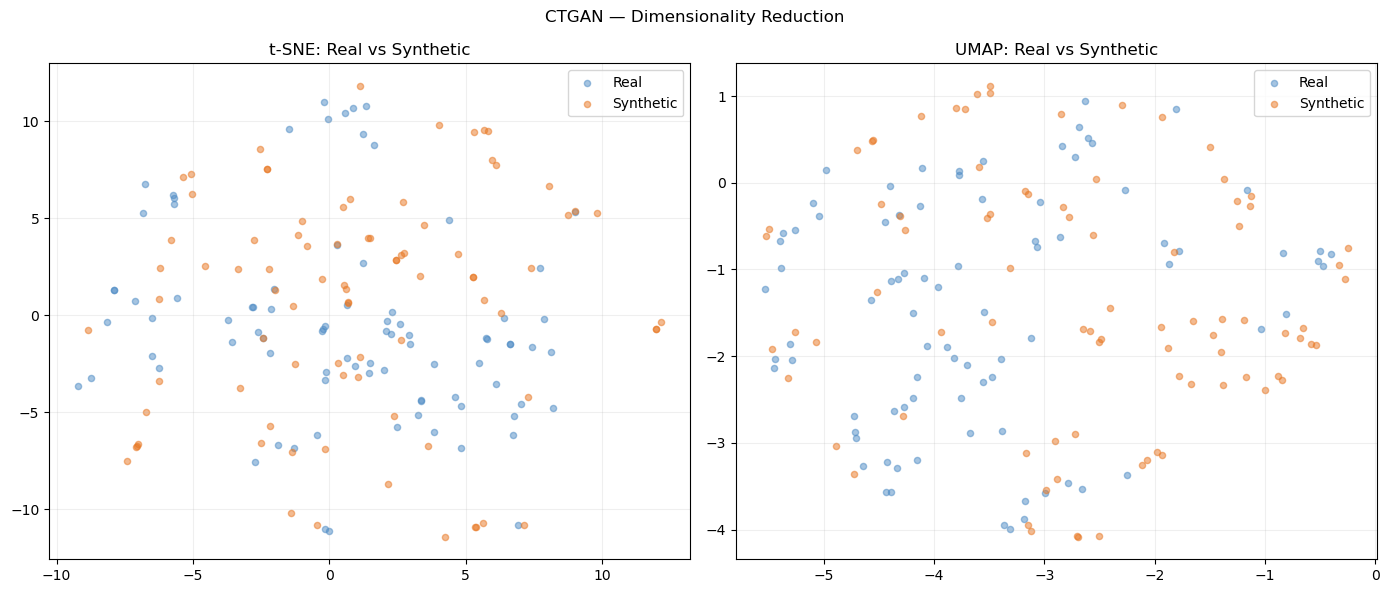


Privacy: distance ratio=2158017846.8746 (SAFE)
Class-conditional quality...


Sampling conditions: 100%|██████████| 200/200 [00:00<00:00, 1267.38it/s]


  Grade 0: 8/21 pass
  Grade 1: 12/21 pass


In [48]:
# ============================================================================
# Section B — CTGAN Synthetic Data Quality
# ============================================================================
print("\n" + "="*65 + "\nSection B — CTGAN Quality Assessment\n" + "="*65)

_meta_b = SingleTableMetadata()
_meta_b.detect_from_dataframe(train_df)
for col in categorical_columns + gene_columns:
    _meta_b.update_column(column_name=col, sdtype='categorical')
_vc_b  = train_df['Grade'].value_counts()
_n_gen = int(_vc_b.max() - _vc_b.min())
print(f"Generating {_n_gen} synthetic minority patients...")
set_seed(42)
try: torch.use_deterministic_algorithms(False)
except AttributeError: pass
_syn_b = CTGANSynthesizer(_meta_b, epochs=150, batch_size=50, verbose=False, cuda=True, pac=10)
_syn_b.fit(train_df)
_cond_b = Condition(num_rows=_n_gen, column_values={'Grade': int(_vc_b.idxmin())})
syn_df = _syn_b.sample_from_conditions(conditions=[_cond_b])
try: torch.use_deterministic_algorithms(True)
except AttributeError: pass
real_minority_df = train_df[train_df['Grade'] == _vc_b.idxmin()].reset_index(drop=True)
print(f"Real minority: {len(real_minority_df)} | Synthetic: {len(syn_df)}")

# B.1 Feature distribution tests
def compare_feature_distributions(real_df, syn_df, gene_cols, alpha=0.05):
    records = []
    stat_ks, p_ks = stats.ks_2samp(real_df['Age_at_diagnosis'].dropna(), syn_df['Age_at_diagnosis'].dropna())
    records.append({'Feature': 'Age_at_diagnosis', 'Test': 'KS', 'stat': round(stat_ks, 4),
                    'p': round(p_ks, 4), 'pass': p_ks > alpha})
    for col in gene_cols + ['Gender', 'Race']:
        r_counts = real_df[col].value_counts().sort_index()
        s_counts = syn_df[col].value_counts().reindex(r_counts.index, fill_value=0)
        if r_counts.sum() == 0 or s_counts.sum() == 0: continue
        expected = r_counts / r_counts.sum() * s_counts.sum()
        valid = expected > 0
        if valid.sum() < 2:
            records.append({'Feature': col, 'Test': 'chi2', 'stat': np.nan, 'p': 1.0, 'pass': True})
            continue
        stat_c, p_c = stats.chisquare(s_counts[valid], f_exp=expected[valid])
        records.append({'Feature': col, 'Test': 'chi2', 'stat': round(stat_c, 4),
                        'p': round(p_c, 4), 'pass': p_c > alpha})
    return pd.DataFrame(records)

dist_df = compare_feature_distributions(real_minority_df, syn_df, gene_columns)
print(f"Feature tests: {dist_df['pass'].sum()}/{len(dist_df)} pass")
print(dist_df.to_string(index=False))
dist_df.to_csv('V16_ctgan_feat_dist.csv', index=False)

# B.2 Co-occurrence
def mutation_cooccurrence_matrix(df, gene_cols):
    M  = df[gene_cols].values.astype(float)
    co = M.T @ M
    freq = M.sum(axis=0)
    denom = np.minimum.outer(freq, freq); denom[denom == 0] = 1
    return co / denom

cooc_real = mutation_cooccurrence_matrix(real_minority_df, gene_columns)
cooc_syn  = mutation_cooccurrence_matrix(syn_df, gene_columns)
threshold_r = np.percentile(cooc_real[cooc_real > 0], 50) if (cooc_real > 0).any() else 0
threshold_s = np.percentile(cooc_syn[cooc_syn > 0], 50) if (cooc_syn > 0).any() else 0
bin_r = (cooc_real >= threshold_r).astype(int); bin_s = (cooc_syn >= threshold_s).astype(int)
intersection = (bin_r & bin_s).sum(); union = (bin_r | bin_s).sum()
jaccard = intersection / union if union > 0 else 0.0
frobenius = np.linalg.norm(cooc_real - cooc_syn, 'fro')
cosine_sim = (np.dot(cooc_real.flatten(), cooc_syn.flatten()) /
              (np.linalg.norm(cooc_real) * np.linalg.norm(cooc_syn) + 1e-9))
print(f"\nCo-occurrence: Jaccard={jaccard:.4f} Frobenius={frobenius:.4f} Cosine={cosine_sim:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for ax, mat, title in [(axes[0], cooc_real, 'Real'), (axes[1], cooc_syn, 'Synthetic'),
                        (axes[2], cooc_real - cooc_syn, 'Difference')]:
    cmap = 'YlOrRd' if 'Diff' not in title else 'RdBu_r'
    center = 0 if 'Diff' in title else None
    sns.heatmap(pd.DataFrame(mat, index=gene_columns, columns=gene_columns),
                ax=ax, cmap=cmap, center=center, annot=False, xticklabels=True, yticklabels=True)
    ax.set_title(title); ax.tick_params(labelsize=7)
plt.suptitle(f'CTGAN Co-occurrence (Jaccard={jaccard:.3f})')
plt.tight_layout(); plt.savefig('V16_ctgan_cooccurrence.png', dpi=150, bbox_inches='tight'); plt.show()

# B.3 Correlation similarity
num_feats = gene_columns + ['Age_at_diagnosis', 'Gender', 'Race']
corr_real = np.nan_to_num(real_minority_df[num_feats].astype(float).corr().values)
corr_syn  = np.nan_to_num(syn_df[num_feats].astype(float).corr().values)
cos_corr  = (np.dot(corr_real.flatten(), corr_syn.flatten()) /
             (np.linalg.norm(corr_real) * np.linalg.norm(corr_syn) + 1e-9))
rmse_corr = np.sqrt(np.mean((corr_real - corr_syn)**2))
print(f"Correlation: Cosine={cos_corr:.4f} RMSE={rmse_corr:.4f}")

# B.4 t-SNE / UMAP
from sklearn.manifold import TSNE
import umap

feats_all = gene_columns + ['Age_at_diagnosis', 'Gender', 'Race']
N_VIZ = min(300, len(real_minority_df), len(syn_df))
rng_v = np.random.default_rng(42)
X_real = real_minority_df.iloc[rng_v.choice(len(real_minority_df), N_VIZ, replace=False)][feats_all].astype(float).values
X_syn  = syn_df.iloc[rng_v.choice(len(syn_df), N_VIZ, replace=False)][feats_all].astype(float).values
X_comb = np.vstack([X_real, X_syn])
y_comb = np.array([0]*N_VIZ + [1]*N_VIZ)
X_scaled = StandardScaler().fit_transform(X_comb)

X_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_scaled)
X_umap = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1).fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, emb, title in [(axes[0], X_tsne, 't-SNE'), (axes[1], X_umap, 'UMAP')]:
    for cls, col, lbl in [(0, '#4C8AC4', 'Real'), (1, '#E87722', 'Synthetic')]:
        m = y_comb == cls
        ax.scatter(emb[m, 0], emb[m, 1], c=col, label=lbl, alpha=0.5, s=20)
    ax.set_title(f'{title}: Real vs Synthetic'); ax.legend(); ax.grid(alpha=0.2)
plt.suptitle('CTGAN — Dimensionality Reduction')
plt.tight_layout(); plt.savefig('V16_ctgan_tsne_umap.png', dpi=150, bbox_inches='tight'); plt.show()

# B.5 NN Privacy
from sklearn.neighbors import KDTree
scaler_nn = StandardScaler()
X_train_nn = scaler_nn.fit_transform(train_df[feats_all].astype(float).values)
X_syn_nn   = scaler_nn.transform(syn_df[feats_all].astype(float).values)
X_heldout  = scaler_nn.transform(real_minority_df[feats_all].astype(float).values)
tree = KDTree(X_train_nn, leaf_size=30)
dists_syn, _    = tree.query(X_syn_nn,  k=5)
dists_heldout,_ = tree.query(X_heldout, k=1)
med_syn  = np.median(dists_syn[:, 0])
med_real = np.median(dists_heldout[:, 0])
ratio    = med_syn / (med_real + 1e-9)
print(f"\nPrivacy: distance ratio={ratio:.4f} ({'SAFE' if ratio >= 1.0 else 'WARNING'})")

# B.6 Class-conditional
print("Class-conditional quality...")
cc_records = []
for grade in [0, 1]:
    real_cls = train_df[train_df['Grade'] == grade]
    n_syn_cls = min(len(real_cls), 200)
    cond_cls = Condition(num_rows=n_syn_cls, column_values={'Grade': grade})
    syn_cls = _syn_b.sample_from_conditions(conditions=[cond_cls])
    stat_a, p_a = stats.ks_2samp(real_cls['Age_at_diagnosis'], syn_cls['Age_at_diagnosis'])
    cc_records.append({'Grade': grade, 'Feature': 'Age_at_diagnosis', 'Test': 'KS',
                        'stat': round(stat_a, 4), 'p': round(p_a, 4), 'pass': p_a > 0.05})
    for gene in gene_columns:
        r_c = real_cls[gene].value_counts().reindex([0,1], fill_value=0)
        s_c = syn_cls[gene].value_counts().reindex([0,1], fill_value=0)
        expected = r_c / r_c.sum() * s_c.sum()
        if (expected > 0).all():
            chi2, p_chi = stats.chisquare(s_c, f_exp=expected)
        else:
            chi2, p_chi = np.nan, 1.0
        cc_records.append({'Grade': grade, 'Feature': gene, 'Test': 'chi2',
                            'stat': round(chi2, 4) if not np.isnan(chi2) else np.nan,
                            'p': round(p_chi, 4), 'pass': p_chi > 0.05})
cc_df = pd.DataFrame(cc_records)
for grade in [0, 1]:
    sub = cc_df[cc_df.Grade == grade]
    print(f"  Grade {grade}: {sub['pass'].sum()}/{len(sub)} pass")
cc_df.to_csv('V16_ctgan_class_conditional.csv', index=False)


Section C — Graph Strategy Comparison


Sampling conditions: 100%|██████████| 107/107 [00:00<00:00, 814.14it/s]



  Strategy: BA (proposed)
    TCGA Test: AUC=0.9228
    CGGA: AUC=0.4792

  Strategy: KNN (k=5)
    TCGA Test: AUC=0.8911
    CGGA: AUC=0.4242

  Strategy: Co-occurrence
    TCGA Test: AUC=0.8947
    CGGA: AUC=0.3792

  Strategy: Correlation
    TCGA Test: AUC=0.8988
    CGGA: AUC=0.3880

  Strategy: Fully Connected
    TCGA Test: AUC=0.8365
    CGGA: AUC=0.4658

  Strategy: Learned (NRI)
    TCGA Test: AUC=0.8435
    CGGA: AUC=0.5495

Graph Strategy Comparison:
       Strategy   Dataset    AUC     F1  Recall_1  Recall_0
  BA (proposed) TCGA Test 0.9228 0.8129    0.8873    0.7835
  BA (proposed)      CGGA 0.4792 0.5281    0.7843    0.3352
      KNN (k=5) TCGA Test 0.8911 0.7919    0.8310    0.8041
      KNN (k=5)      CGGA 0.4242 0.3755    0.4804    0.3956
  Co-occurrence TCGA Test 0.8947 0.8108    0.8451    0.8247
  Co-occurrence      CGGA 0.3792 0.3409    0.4412    0.3571
    Correlation TCGA Test 0.8988 0.8029    0.7746    0.8866
    Correlation      CGGA 0.3880 0.3137    0.3922   

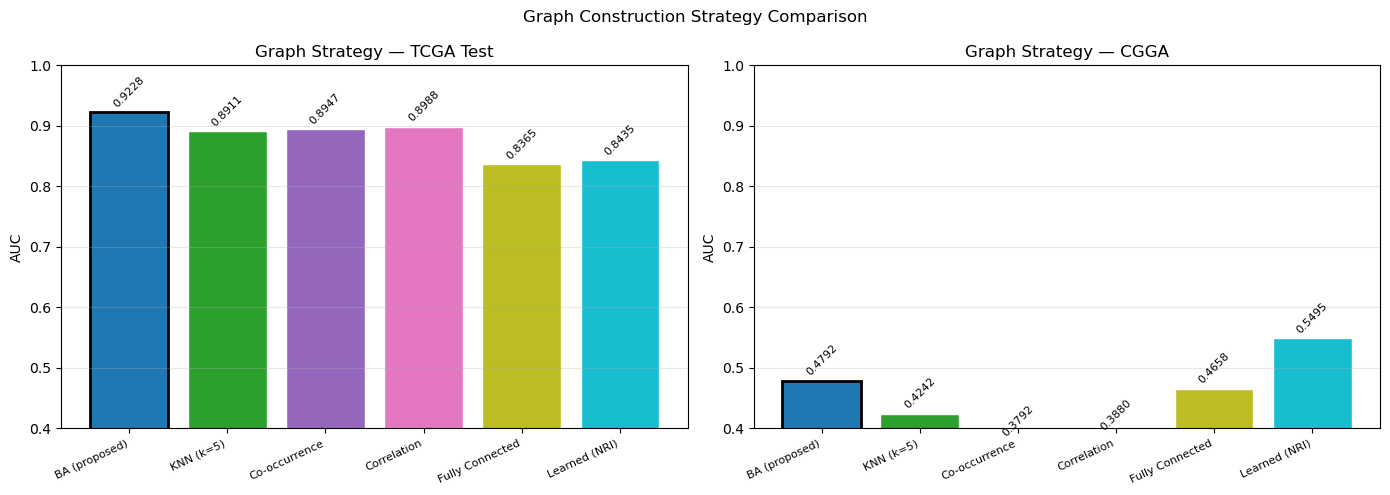

In [49]:
# ============================================================================
# Section C — Graph Construction Strategy Comparison
# ============================================================================
print("\n" + "="*65 + "\nSection C — Graph Strategy Comparison\n" + "="*65)

from sklearn.neighbors import NearestNeighbors

def _make_base_heterodata(df, scaler=None):
    if scaler is None:
        scaler = StandardScaler()
        scaler.fit(df[['Age_at_diagnosis']].values.astype(float))
    age_n   = scaler.transform(df[['Age_at_diagnosis']].values.astype(float))
    gender  = df[['Gender']].values.astype(float)
    race_oh = np.zeros((len(df), 4), dtype=float)
    for i, rv in enumerate(df['Race'].values.astype(int)):
        if 0 <= rv < 4: race_oh[i, rv] = 1.0
    pat_feat = np.hstack([gender, race_oh, age_n])
    g = HeteroData()
    g['Patient'].x = torch.tensor(pat_feat, dtype=torch.float)
    g['Patient'].y = torch.tensor(df['Grade'].values, dtype=torch.long)
    g['Gene'].x    = torch.eye(NUM_GENES, dtype=torch.float)
    src_g, dst_p = [], []
    for pi, (_, row) in enumerate(df.iterrows()):
        for gi, gene in enumerate(gene_columns):
            if int(row[gene]) == 1: src_g.append(gi); dst_p.append(pi)
    g[('Gene','mutates','Patient')].edge_index    = torch.tensor([src_g, dst_p], dtype=torch.long)
    g[('Patient','mutated_by','Gene')].edge_index = torch.tensor([dst_p, src_g], dtype=torch.long)
    g[('Gene','coexists','Gene')].edge_index = torch.zeros(2, 0, dtype=torch.long)
    return g


def build_knn_graph(df, k=5, scaler=None):
    g = _make_base_heterodata(df, scaler=scaler)
    X = StandardScaler().fit_transform(
        df[gene_columns + ['Age_at_diagnosis','Gender','Race']].astype(float).values)
    nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='ball_tree').fit(X)
    _, inds = nbrs.kneighbors(X)
    src, dst = [], []
    for i, neighbours in enumerate(inds):
        for j in neighbours[1:]: src += [i, j]; dst += [j, i]
    g[('Patient','cooccurs','Patient')].edge_index = torch.tensor([src, dst], dtype=torch.long)
    return g


def build_cooccurrence_graph(df, min_jaccard=0.3, scaler=None):
    g = _make_base_heterodata(df, scaler=scaler)
    M = df[gene_columns].values.astype(float); n = len(df)
    src, dst = [], []
    for i in range(n):
        for j in range(i+1, n):
            inter = np.minimum(M[i], M[j]).sum()
            union = np.maximum(M[i], M[j]).sum()
            if union > 0 and inter / union >= min_jaccard:
                src += [i, j]; dst += [j, i]
    if src:
        g[('Patient','cooccurs','Patient')].edge_index = torch.tensor([src, dst], dtype=torch.long)
    else:
        g[('Patient','cooccurs','Patient')].edge_index = torch.zeros(2, 0, dtype=torch.long)
    return g


def build_correlation_graph(df, min_pearson=0.3, scaler=None):
    g = _make_base_heterodata(df, scaler=scaler)
    M = df[gene_columns].values.astype(float)
    M_norm = M - M.mean(axis=1, keepdims=True)
    norms  = np.linalg.norm(M_norm, axis=1, keepdims=True) + 1e-9
    M_norm = M_norm / norms
    corr   = M_norm @ M_norm.T
    rows, cols = np.where((corr >= min_pearson) & ~np.eye(len(df), dtype=bool))
    src = list(rows) + list(cols); dst = list(cols) + list(rows)
    if src:
        g[('Patient','cooccurs','Patient')].edge_index = torch.tensor([src, dst], dtype=torch.long)
    else:
        g[('Patient','cooccurs','Patient')].edge_index = torch.zeros(2, 0, dtype=torch.long)
    return g


def build_fully_connected_graph(df, scaler=None):
    g = _make_base_heterodata(df, scaler=scaler)
    n = len(df)
    rows, cols = np.meshgrid(np.arange(n), np.arange(n)); mask = rows != cols
    g[('Patient','cooccurs','Patient')].edge_index = torch.tensor([rows[mask], cols[mask]], dtype=torch.long)
    return g


def build_learned_graph(df, n_epochs=30, lr=1e-3, scaler=None):
    g = _make_base_heterodata(df, scaler=scaler)
    X = torch.tensor(StandardScaler().fit_transform(
            df[gene_columns + ['Age_at_diagnosis','Gender','Race']].astype(float).values
        ), dtype=torch.float)
    y = torch.tensor(df['Grade'].values, dtype=torch.long)
    n = X.shape[0]; d = X.shape[1]
    enc = torch.nn.Sequential(torch.nn.Linear(d*2, 32), torch.nn.ReLU(),
                               torch.nn.Linear(32, 1), torch.nn.Sigmoid())
    opt = torch.optim.Adam(enc.parameters(), lr=lr)
    enc.train()
    for _ in range(n_epochs):
        idx = torch.randperm(n)[:32]
        pi = idx.repeat_interleave(32); pj = idx.repeat(32)
        mask = pi != pj; pi, pj = pi[mask], pj[mask]
        scores = enc(torch.cat([X[pi], X[pj]], dim=-1)).squeeze(-1)
        same   = (y[pi] == y[pj]).float()
        loss   = torch.nn.functional.binary_cross_entropy(scores, same)
        opt.zero_grad(); loss.backward(); opt.step()
    enc.eval()
    src_l, dst_l = [], []
    with torch.no_grad():
        for i in range(n):
            j_all = torch.arange(n); j_all = j_all[j_all != i]
            xi = X[i].unsqueeze(0).expand(len(j_all), -1)
            scores_i = enc(torch.cat([xi, X[j_all]], dim=-1)).squeeze(-1)
            keep = j_all[scores_i >= 0.5].tolist()
            src_l += [i]*len(keep); dst_l += keep
    if src_l:
        g[('Patient','cooccurs','Patient')].edge_index = torch.tensor([src_l, dst_l], dtype=torch.long)
    else:
        g[('Patient','cooccurs','Patient')].edge_index = torch.zeros(2, 0, dtype=torch.long)
    return g


GRAPH_STRATEGIES = {
    'BA (proposed)':     lambda df, scaler=None: construct_scalefree_bipartite_heterograph(df, scaler=scaler),
    'KNN (k=5)':         lambda df, scaler=None: build_knn_graph(df, scaler=scaler),
    'Co-occurrence':     lambda df, scaler=None: build_cooccurrence_graph(df, min_jaccard=0.3, scaler=scaler),
    'Correlation':       lambda df, scaler=None: build_correlation_graph(df, min_pearson=0.3, scaler=scaler),
    'Fully Connected':   lambda df, scaler=None: build_fully_connected_graph(df, scaler=scaler),
    'Learned (NRI)':     lambda df, scaler=None: build_learned_graph(df, scaler=scaler),
}

# Generate augmented training data for graph strategy comparison
aug_df_strat = apply_ctgan(train_val_df.copy())
strat_scaler = StandardScaler()
strat_scaler.fit(train_val_df[['Age_at_diagnosis']].values.astype(float))

graph_results = []
for strat_name, graph_fn in GRAPH_STRATEGIES.items():
    print(f"\n  Strategy: {strat_name}")
    set_seed(42)
    try:
        tr_g = to_dev(graph_fn(aug_df_strat, scaler=strat_scaler))
        te_g = to_dev(graph_fn(test_df, scaler=strat_scaler))
        cg_g = to_dev(graph_fn(cgga_df, scaler=strat_scaler))
        vg_  = to_dev(graph_fn(val_df, scaler=strat_scaler))
    except Exception as e:
        print(f"    ERROR: {e}"); continue

    _, state, _ = train_and_evaluate(tr_g, vg_, BEST_BP_TCGA, BEST_MODEL_CLS_TCGA, BEST_FKW_TCGA,
                                      seed=42, loss_fn=make_criterion(tr_g))
    kw_g = {'hidden_dim': BEST_BP_TCGA['hidden_dim'], 'out_dim': 2,
             'num_heads': BEST_BP_TCGA['num_heads'], 'dropout': BEST_BP_TCGA['dropout']}
    kw_g.update(BEST_FKW_TCGA)
    m_g = BEST_MODEL_CLS_TCGA(**kw_g).to(device)
    try:
        with torch.no_grad(): _ = m_g(tr_g)
    except: pass
    m_g.load_state_dict(state)

    for ds_name, ds_g in [('TCGA Test', te_g), ('CGGA', cg_g)]:
        pd_, pb_, lb_ = evaluate_model(m_g, ds_g, threshold=BEST_THRESHOLD_TCGA)
        try:    auc = roc_auc_score(lb_, pb_)
        except: auc = np.nan
        graph_results.append({
            'Strategy': strat_name, 'Dataset': ds_name,
            'AUC': round(auc, 4),
            'F1': round(f1_score(lb_, pd_, zero_division=0), 4),
            'Recall_1': round(recall_score(lb_, pd_, pos_label=1, zero_division=0), 4),
            'Recall_0': round(recall_score(lb_, pd_, pos_label=0, zero_division=0), 4),
        })
        print(f"    {ds_name}: AUC={auc:.4f}")

graph_df = pd.DataFrame(graph_results)
print("\nGraph Strategy Comparison:")
print(graph_df.to_string(index=False))
graph_df.to_csv('V16_graph_strategy_comparison.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
strategy_order = list(GRAPH_STRATEGIES.keys())
colors_gs = plt.cm.tab10(np.linspace(0, 1, len(strategy_order)))
for ax, ds in zip(axes, ['TCGA Test', 'CGGA']):
    sub = graph_df[graph_df.Dataset == ds].set_index('Strategy').reindex(strategy_order)
    bars = ax.bar(range(len(strategy_order)), sub['AUC'].fillna(0), color=colors_gs, edgecolor='white')
    bars[0].set_edgecolor('black'); bars[0].set_linewidth(2)
    for xi, v in enumerate(sub['AUC'].fillna(0)):
        ax.text(xi, v + 0.005, f'{v:.4f}', ha='center', va='bottom', fontsize=8, rotation=45)
    ax.set_xticks(range(len(strategy_order)))
    ax.set_xticklabels(strategy_order, rotation=25, ha='right', fontsize=8)
    ax.set_ylabel('AUC'); ax.set_ylim(0.4, 1.0); ax.set_title(f'Graph Strategy — {ds}')
    ax.grid(axis='y', alpha=0.3)
plt.suptitle('Graph Construction Strategy Comparison')
plt.tight_layout(); plt.savefig('V16_graph_strategy_comparison.png', dpi=300, bbox_inches='tight'); plt.show()


Section D — Tabular Baselines + SHAP
Feature matrix: train_val=(669, 26), test=(168, 26), cgga=(284, 26)
  Tuning XGBoost... best_AUC_CV=nan
  Tuning RandomForest... best_AUC_CV=0.9176
  Tuning SVM... best_AUC_CV=0.9123
  Tuning MLP... best_AUC_CV=0.9077
  XGBoost         TCGA Test : AUC=0.9286 F1=0.8684
  XGBoost         CGGA      : AUC=0.7800 F1=0.6250
  RandomForest    TCGA Test : AUC=0.9291 F1=0.8725
  RandomForest    CGGA      : AUC=0.7960 F1=0.6696
  SVM             TCGA Test : AUC=0.9162 F1=0.8684
  SVM             CGGA      : AUC=0.7360 F1=0.6393
  MLP             TCGA Test : AUC=0.9307 F1=0.8591
  MLP             CGGA      : AUC=0.7887 F1=0.6570

5-Fold CV (Baselines):
                 auc              f1        
                mean     std    mean     std
Model                                       
MLP           0.9077  0.0288  0.8490  0.0369
RandomForest  0.9176  0.0157  0.8603  0.0273
SVM           0.9117  0.0190  0.8606  0.0217
XGBoost       0.9175  0.0234  0.8591  0.03

  0%|          | 0/100 [00:00<?, ?it/s]


SVM — SHAP values shape: (100, 26)
SVM — Top-10 SHAP features (n=100):
   1. IDH1              : 0.2823
   2. Age_norm          : 0.0345
   3. ATRX              : 0.0184
   4. PTEN              : 0.0149
   5. CIC               : 0.0132
   6. IDH2              : 0.0123
   7. NF1               : 0.0071
   8. Race_White        : 0.0043
   9. TP53              : 0.0038
  10. Gender            : 0.0035


  0%|          | 0/100 [00:00<?, ?it/s]


MLP — SHAP values shape: (100, 26)
MLP — Top-10 SHAP features (n=100):
   1. IDH1              : 0.1726
   2. Age_norm          : 0.1455
   3. PTEN              : 0.0402
   4. CIC               : 0.0201
   5. ATRX              : 0.0140
   6. Gender            : 0.0101
   7. Race_Black        : 0.0095
   8. GRIN2A            : 0.0065
   9. TP53              : 0.0047
  10. EGFR              : 0.0047


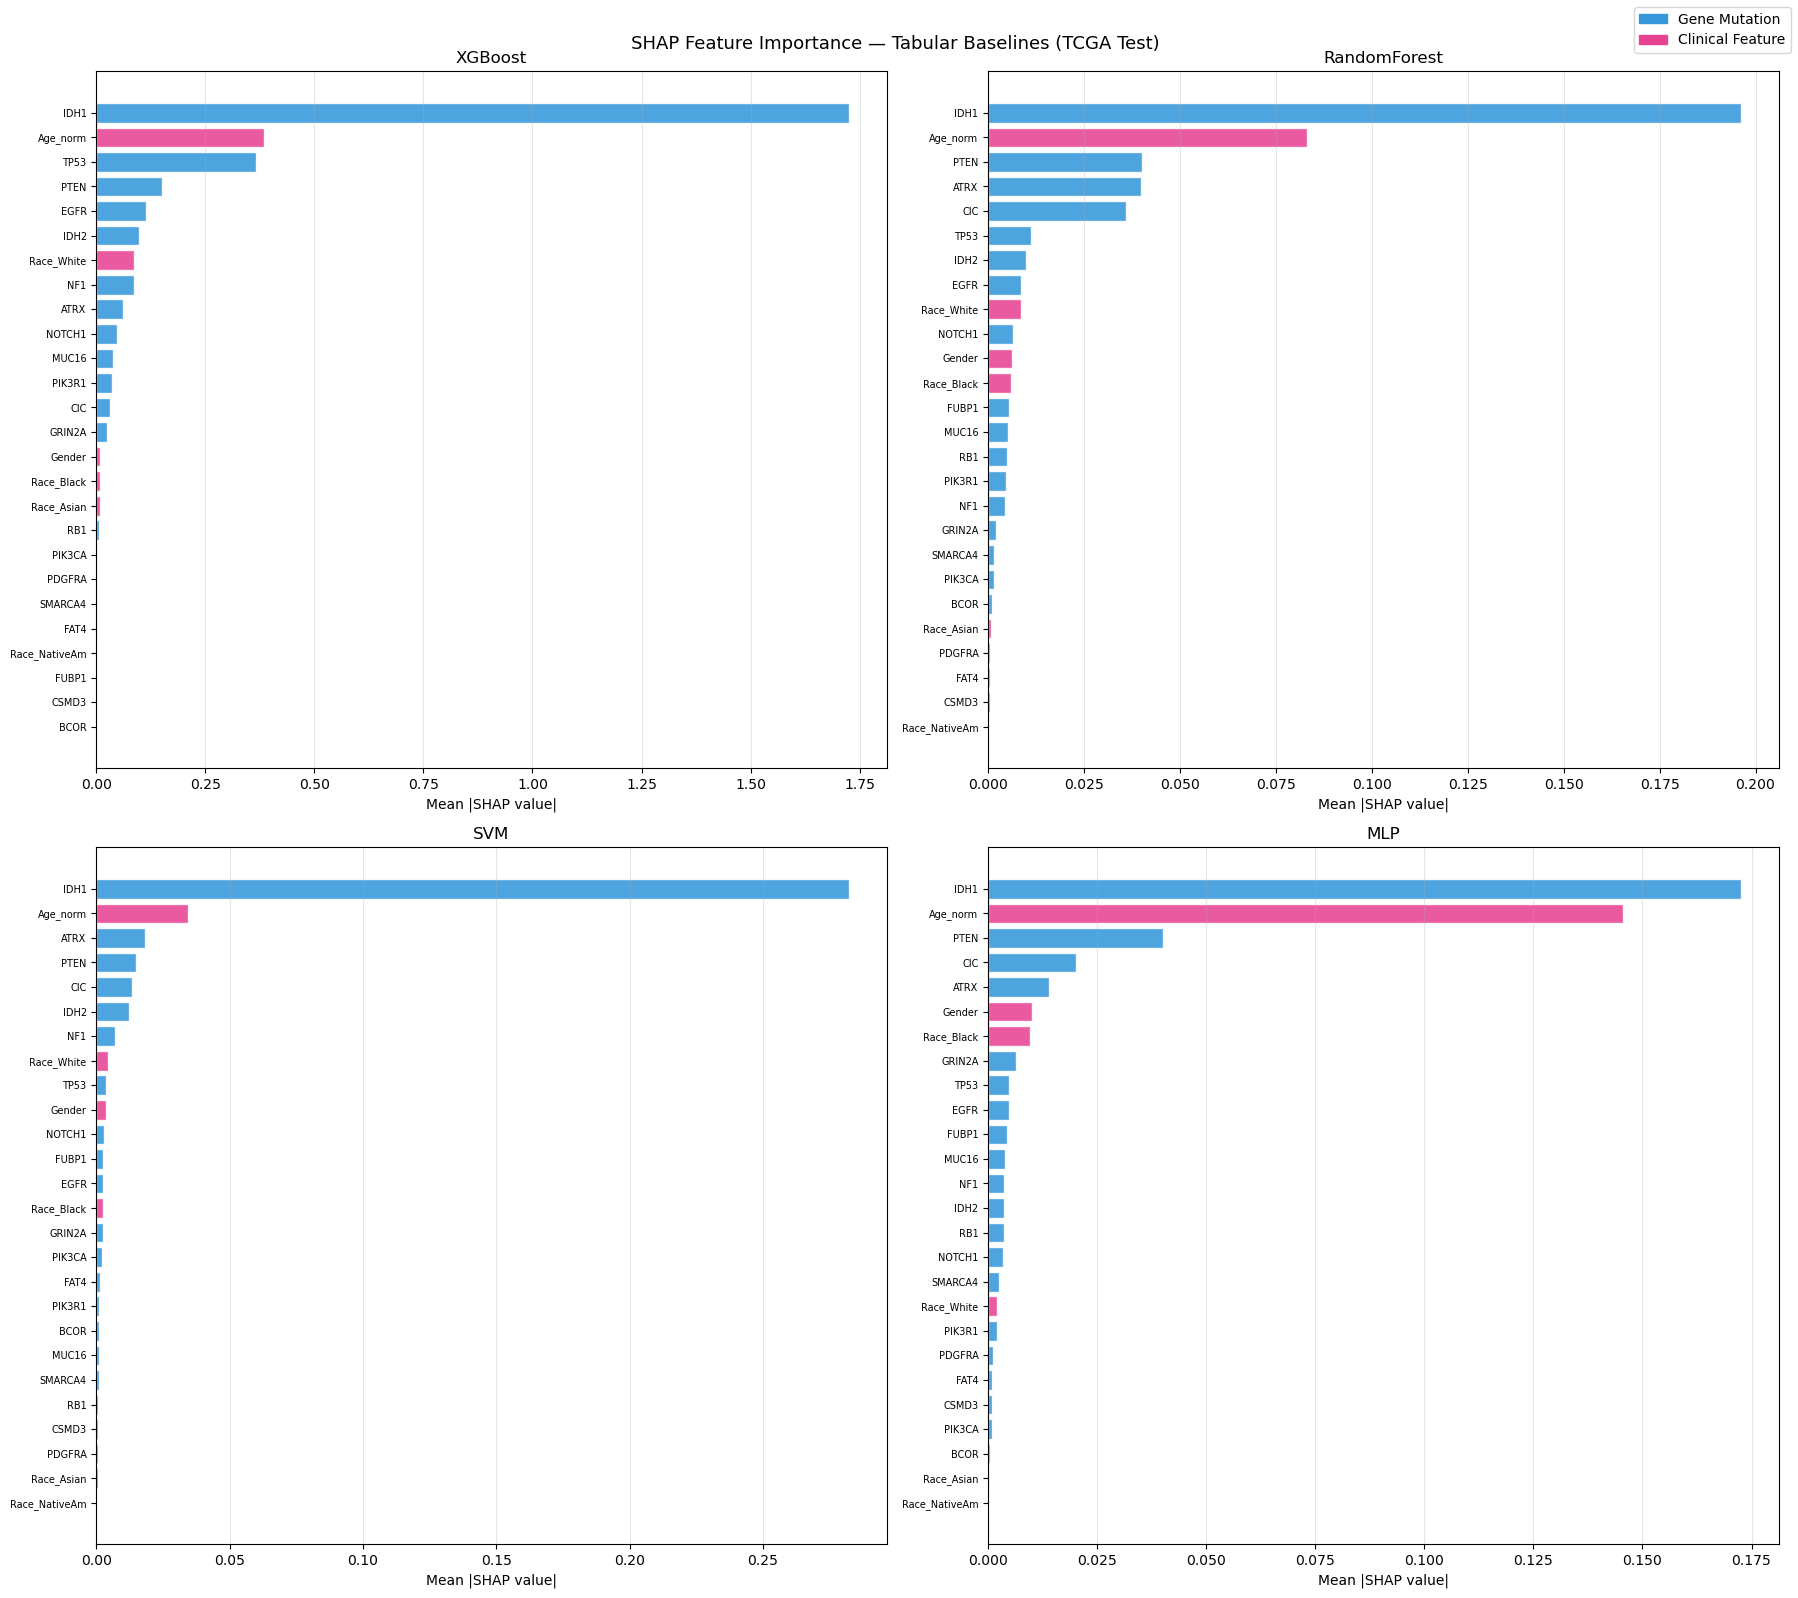

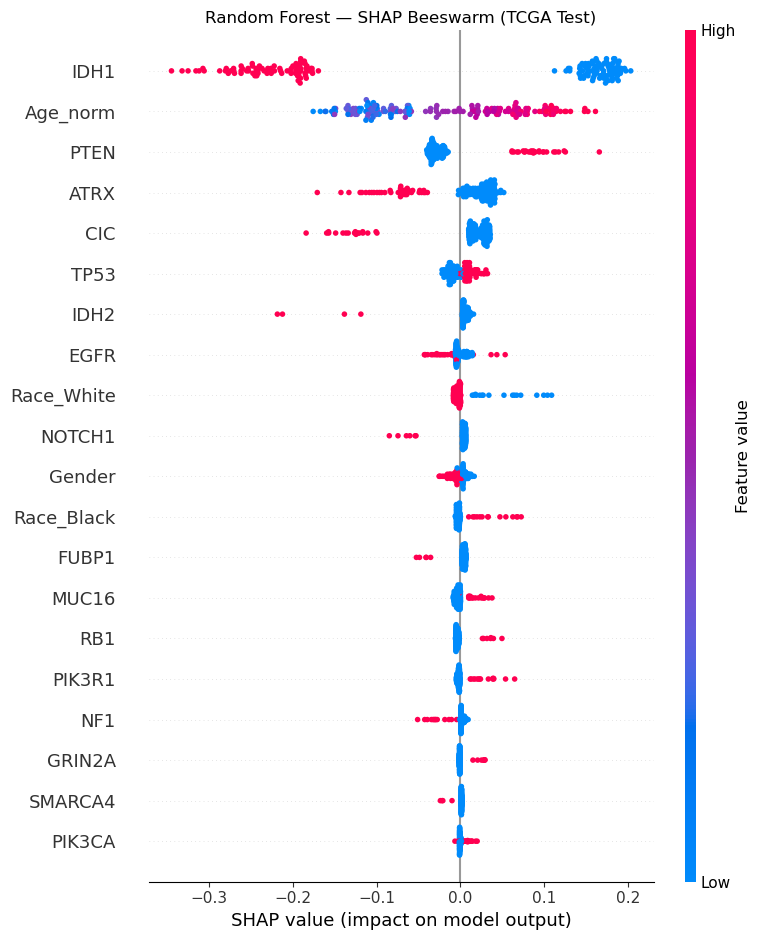

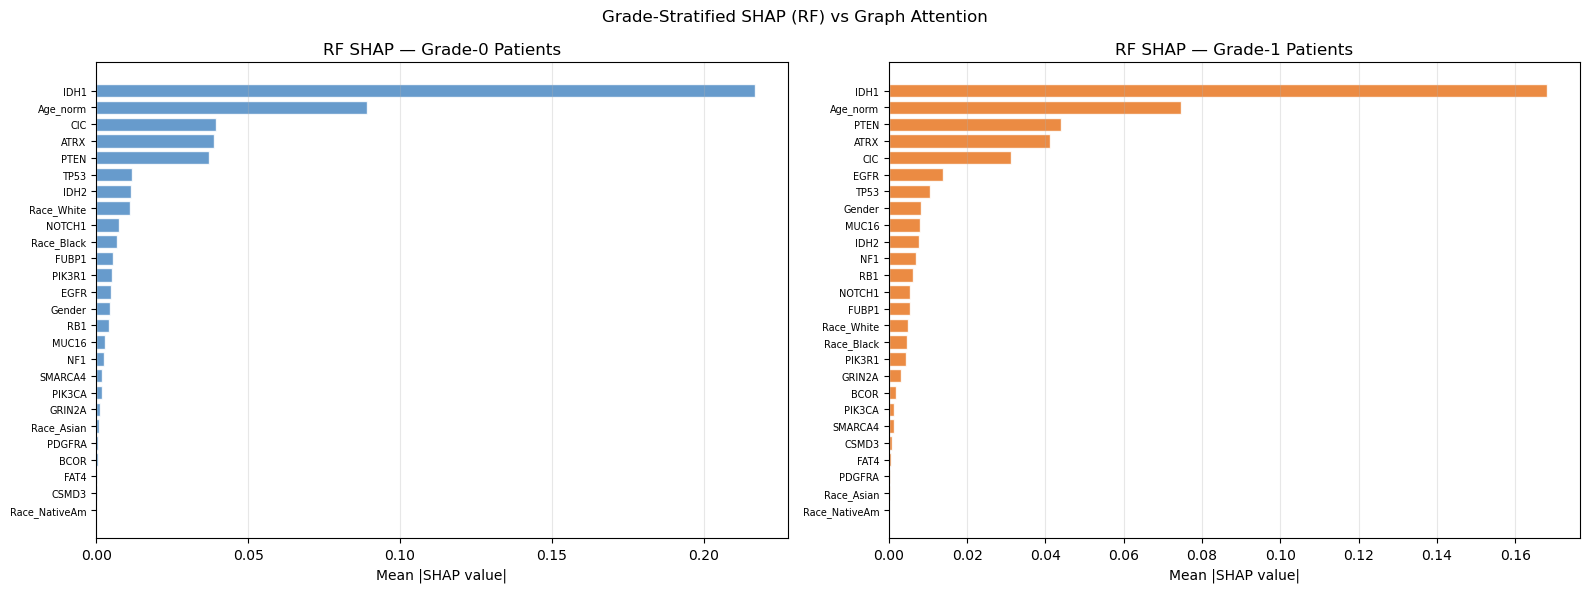


SHAP (RandomForest) vs Edge Occlusion (Best GNN) — Gene Ranking

  Rank               SHAP (RF)    Edge Occlusion (GNN)
     1                    IDH1                    IDH1  ✓
     2                    PTEN                    IDH2  
     3                    ATRX                     NF1  
     4                     CIC                   MUC16  
     5                    TP53                    PTEN  
     6                    IDH2                  PIK3CA  
     7                    EGFR                    BCOR  
     8                  NOTCH1                    ATRX  
     9                   FUBP1                    TP53  
    10                   MUC16                   CSMD3  

  Spearman rho=0.263, p=0.2623

✓ SHAP analysis complete.


In [53]:
# ============================================================================
# Section D — Non-GNN Tabular Baselines + SHAP
# ============================================================================
print("\n" + "="*65 + "\nSection D — Tabular Baselines + SHAP\n" + "="*65)

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

def build_tabular_features(df, scaler=None):
    if scaler is None:
        scaler = StandardScaler()
        scaler.fit(df[['Age_at_diagnosis']].values.astype(float))
    age_n   = scaler.transform(df[['Age_at_diagnosis']].values.astype(float))
    gender  = df[['Gender']].values.astype(float)
    race_oh = np.zeros((len(df), 4), dtype=float)
    for i, rv in enumerate(df['Race'].values.astype(int)):
        if 0 <= rv < 4: race_oh[i, rv] = 1.0
    genes = df[gene_columns].values.astype(float)
    X = np.hstack([genes, gender, race_oh, age_n])
    y = df['Grade'].values
    return X, y

tab_scaler = StandardScaler()
tab_scaler.fit(train_val_df[['Age_at_diagnosis']].values.astype(float))
X_trainval, y_trainval = build_tabular_features(train_val_df, scaler=tab_scaler)
X_test,     y_test     = build_tabular_features(test_df,      scaler=tab_scaler)
X_cgga,     y_cgga     = build_tabular_features(cgga_df,      scaler=tab_scaler)
print(f"Feature matrix: train_val={X_trainval.shape}, test={X_test.shape}, cgga={X_cgga.shape}")

FEATURE_NAMES = (gene_columns +
                 ['Gender', 'Race_White', 'Race_Black', 'Race_Asian',
                  'Race_NativeAm', 'Age_norm'])

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
n0_t, n1_t = (y_trainval == 0).sum(), (y_trainval == 1).sum()

BASELINES = {
    'XGBoost': (
        XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                      random_state=42, scale_pos_weight=n0_t/n1_t),
        {'n_estimators': [100, 300], 'max_depth': [3, 5],
         'learning_rate': [0.05, 0.1], 'subsample': [0.8, 1.0]}
    ),
    'RandomForest': (
        RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
        {'n_estimators': [100, 300], 'max_depth': [None, 10], 'min_samples_leaf': [1, 3]}
    ),
    'SVM': (
        SVC(class_weight='balanced', random_state=42, probability=True),
        {'C': [0.1, 1, 10], 'gamma': ['scale', 0.01, 0.001]}
    ),
    'MLP': (
        MLPClassifier(random_state=42, max_iter=500, early_stopping=True),
        {'hidden_layer_sizes': [(64, 32), (128, 64), (256, 128)],
         'alpha': [1e-4, 1e-3], 'learning_rate_init': [1e-3, 5e-4]}
    ),
}

baseline_best = {}
for name, (est, param_grid) in BASELINES.items():
    print(f"  Tuning {name}...", end=' ')
    gs = GridSearchCV(est, param_grid, cv=cv5, scoring='roc_auc', n_jobs=-1, refit=True)
    gs.fit(X_trainval, y_trainval)
    baseline_best[name] = gs.best_estimator_
    print(f"best_AUC_CV={gs.best_score_:.4f}")

def eval_baseline(model, X, y):
    pb = model.predict_proba(X)[:, 1]
    th = find_optimal_threshold(pb, y)
    pd_ = (pb >= th).astype(int)
    try:    auc = roc_auc_score(y, pb)
    except: auc = np.nan
    return {'AUC': round(auc, 4), 'F1': round(f1_score(y, pd_, zero_division=0), 4),
            'Recall_1': round(recall_score(y, pd_, pos_label=1, zero_division=0), 4),
            'Recall_0': round(recall_score(y, pd_, pos_label=0, zero_division=0), 4),
            'Threshold': round(th, 3), 'probs': pb, 'labels': y, 'preds': pd_}

baseline_results = []
for name, model in baseline_best.items():
    for ds_name, X_, y_ in [('TCGA Test', X_test, y_test), ('CGGA', X_cgga, y_cgga)]:
        r = eval_baseline(model, X_, y_)
        baseline_results.append({'Model': f'Baseline/{name}', 'Dataset': ds_name,
                                  **{k: v for k, v in r.items() if k not in ('probs','labels','preds')}})
        print(f"  {name:15s} {ds_name:10s}: AUC={r['AUC']:.4f} F1={r['F1']:.4f}")

# 5-Fold CV for baselines
cv_bl_records = []
for name, model in baseline_best.items():
    for fold, (tr_i, vl_i) in enumerate(cv5.split(X_trainval, y_trainval), 1):
        m_cv = copy.deepcopy(model); m_cv.fit(X_trainval[tr_i], y_trainval[tr_i])
        pb_cv = m_cv.predict_proba(X_trainval[vl_i])[:, 1]
        lb_cv = y_trainval[vl_i]
        th_cv = find_optimal_threshold(pb_cv, lb_cv)
        pd_cv = (pb_cv >= th_cv).astype(int)
        try:    auc_cv = roc_auc_score(lb_cv, pb_cv)
        except: auc_cv = np.nan
        cv_bl_records.append({'Model': name, 'fold': fold, 'auc': auc_cv,
                               'f1': f1_score(lb_cv, pd_cv, zero_division=0)})
cv_bl_df = pd.DataFrame(cv_bl_records)
print("\n5-Fold CV (Baselines):")
print(cv_bl_df.groupby('Model')[['auc','f1']].agg(['mean','std']).round(4).to_string())

baseline_df = pd.DataFrame(baseline_results)
baseline_df.to_csv('V16_tabular_baselines.csv', index=False)

# DeLong: best GNN vs best baseline
best_bl_name = baseline_df[baseline_df.Dataset=='TCGA Test'].sort_values('AUC', ascending=False).iloc[0]['Model'].replace('Baseline/', '')
pb_gnn, lb_gnn = None, None
for pipe in PIPELINES:
    pb_gnn, lb_gnn = _get_result(BEST_MODEL_NAME_TCGA, pipe)
    if pb_gnn is not None: break
pb_bl = baseline_best[best_bl_name].predict_proba(X_test)[:, 1]
if pb_gnn is not None:
    auc_gnn, auc_bl, z_dl, p_dl = delong_test(pb_gnn, pb_bl, lb_gnn)
    print(f"\nDeLong: {BEST_MODEL_NAME_TCGA} AUC={auc_gnn:.4f} vs {best_bl_name} AUC={auc_bl:.4f} Z={z_dl:.3f} p={p_dl:.4f}")


# ── D.4 SHAP Feature Attribution ────────────────────────────────────────────
print("\n" + "="*65 + "\nSHAP Analysis\n" + "="*65)
import shap

shap_results = {}

def _extract_shap_values(shap_out):
    """Handle different SHAP output formats across versions."""
    # shap.Explanation object (newer SHAP)
    if hasattr(shap_out, 'values'):
        sv = shap_out.values
    elif isinstance(shap_out, list):
        sv = shap_out[1]  # binary: take Grade-1 class
    else:
        sv = shap_out
    sv = np.array(sv)
    # 3D array [n_samples, n_features, n_classes] → take class 1
    if sv.ndim == 3:
        sv = sv[:, :, 1]
    return sv

# TreeExplainer for tree-based models
for name in ['XGBoost', 'RandomForest']:
    model_bl = baseline_best[name]
    explainer = shap.TreeExplainer(model_bl)
    shap_out = explainer.shap_values(X_test)
    sv = _extract_shap_values(shap_out)
    shap_results[name] = sv
    print(f"\n{name} — SHAP values shape: {sv.shape}")
    mean_abs = np.abs(sv).mean(axis=0)
    rank = list(np.argsort(-mean_abs))
    print(f"{name} — Top-10 SHAP features:")
    for i in range(min(10, len(rank))):
        idx = int(rank[i])
        print(f"  {i+1:2d}. {FEATURE_NAMES[idx]:18s}: {mean_abs[idx]:.4f}")

# KernelExplainer for SVM and MLP
background = shap.kmeans(X_trainval, 50)
for name in ['SVM', 'MLP']:
    model_bl = baseline_best[name]
    explainer = shap.KernelExplainer(model_bl.predict_proba, background)
    shap_out = explainer.shap_values(X_test[:100], nsamples=200)
    sv = _extract_shap_values(shap_out)
    shap_results[name] = sv
    print(f"\n{name} — SHAP values shape: {sv.shape}")
    mean_abs = np.abs(sv).mean(axis=0)
    rank = list(np.argsort(-mean_abs))
    print(f"{name} — Top-10 SHAP features (n=100):")
    for i in range(min(10, len(rank))):
        idx = int(rank[i])
        print(f"  {i+1:2d}. {FEATURE_NAMES[idx]:18s}: {mean_abs[idx]:.4f}")

# SHAP summary bar plots
fig, axes = plt.subplots(2, 2, figsize=(18, 16))
for ax, name in zip(axes.flatten(), ['XGBoost', 'RandomForest', 'SVM', 'MLP']):
    sv = shap_results[name]
    mean_abs = np.abs(sv).mean(axis=0)
    order = list(np.argsort(mean_abs))
    ax.barh([FEATURE_NAMES[int(i)] for i in order], [float(mean_abs[int(i)]) for i in order],
            color=['#e84393' if FEATURE_NAMES[int(i)] in CLINICAL_FEAT_NAMES else '#3498db'
                   for i in order],
            edgecolor='white', alpha=0.88)
    ax.set_xlabel('Mean |SHAP value|'); ax.set_title(f'{name}')
    ax.grid(axis='x', alpha=0.3); ax.tick_params(axis='y', labelsize=7)
from matplotlib.patches import Patch
fig.legend(handles=[Patch(color='#3498db', label='Gene Mutation'),
                    Patch(color='#e84393', label='Clinical Feature')],
           loc='upper right', fontsize=10)
plt.suptitle('SHAP Feature Importance — Tabular Baselines (TCGA Test)', fontsize=13)
plt.tight_layout(); plt.savefig('V16_shap_baselines.png', dpi=150, bbox_inches='tight'); plt.show()

# SHAP beeswarm for Random Forest
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_results['RandomForest'], X_test,
                  feature_names=FEATURE_NAMES, show=False, max_display=20)
plt.title('Random Forest — SHAP Beeswarm (TCGA Test)')
plt.tight_layout(); plt.savefig('V16_shap_beeswarm_rf.png', dpi=150, bbox_inches='tight'); plt.show()

# Grade-stratified SHAP
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sv_rf = shap_results['RandomForest']
for ax, grade, color, title in [(axes[0], 0, '#4C8AC4', 'Grade-0'), (axes[1], 1, '#E87722', 'Grade-1')]:
    mask = y_test == grade
    mean_abs = np.abs(sv_rf[mask]).mean(axis=0)
    order = list(np.argsort(mean_abs))
    ax.barh([FEATURE_NAMES[int(i)] for i in order], [float(mean_abs[int(i)]) for i in order],
            color=color, edgecolor='white', alpha=0.85)
    ax.set_xlabel('Mean |SHAP value|'); ax.set_title(f'RF SHAP — {title} Patients')
    ax.grid(axis='x', alpha=0.3); ax.tick_params(axis='y', labelsize=7)
plt.suptitle('Grade-Stratified SHAP (RF) vs Graph Attention')
plt.tight_layout(); plt.savefig('V16_shap_grade_stratified.png', dpi=150, bbox_inches='tight'); plt.show()

# Ranking comparison: SHAP vs Edge Occlusion
print("\n" + "="*75)
print("SHAP (RandomForest) vs Edge Occlusion (Best GNN) — Gene Ranking")
print("="*75)
rf_mean_abs = np.abs(shap_results['RandomForest']).mean(axis=0)
rf_gene_imp = {FEATURE_NAMES[i]: float(rf_mean_abs[i]) for i in range(len(gene_columns))}
rf_ranking  = sorted(rf_gene_imp, key=rf_gene_imp.get, reverse=True)

if 'TCGA Test' in xai_occlusion_results:
    _, agg_occ = xai_occlusion_results['TCGA Test']
    gnn_ranking = agg_occ['overall'].sort_values(ascending=False).index.tolist()
else:
    gnn_ranking = gene_columns

print(f"\n  {'Rank':>4}  {'SHAP (RF)':>22}  {'Edge Occlusion (GNN)':>22}")
for i in range(min(10, len(gene_columns))):
    shap_g = rf_ranking[i] if i < len(rf_ranking) else '—'
    gnn_g  = gnn_ranking[i] if i < len(gnn_ranking) else '—'
    match  = '✓' if shap_g == gnn_g else ''
    print(f"  {i+1:>4}  {shap_g:>22}  {gnn_g:>22}  {match}")

from scipy.stats import spearmanr
shared_genes = [g for g in gene_columns if g in rf_gene_imp]
if 'TCGA Test' in xai_occlusion_results:
    shap_ranks = [rf_ranking.index(g) + 1 for g in shared_genes]
    gnn_ranks  = [gnn_ranking.index(g) + 1 if g in gnn_ranking else len(gene_columns)
                  for g in shared_genes]
    rho, p_rho = spearmanr(shap_ranks, gnn_ranks)
    print(f"\n  Spearman rho={rho:.3f}, p={p_rho:.4f}")

print("\n✓ SHAP analysis complete.")


Section E — Edge-Type Ablation


Sampling conditions: 100%|██████████| 107/107 [00:00<00:00, 650.99it/s]



  Ablation: Full (baseline)
    TCGA Test: AUC=0.9228
    CGGA: AUC=0.4792

  Ablation: No PP
    TCGA Test: AUC=0.9085
    CGGA: AUC=0.4204

  Ablation: No GG
    TCGA Test: AUC=0.9220
    CGGA: AUC=0.4836

  Ablation: No GP
    TCGA Test: AUC=0.8287
    CGGA: AUC=0.4107

  Ablation: PP only
    TCGA Test: AUC=0.8287
    CGGA: AUC=0.4107

  Ablation: GG only
    TCGA Test: AUC=0.8181
    CGGA: AUC=0.4100

Ablation Results:
       Ablation   Dataset    AUC     F1  Recall_1  Recall_0
Full (baseline) TCGA Test 0.9228 0.8129    0.8873    0.7835
Full (baseline)      CGGA 0.4792 0.5281    0.7843    0.3352
          No PP TCGA Test 0.9085 0.8163    0.8451    0.8351
          No PP      CGGA 0.4204 0.4595    0.6667    0.3077
          No GG TCGA Test 0.9220 0.8289    0.8873    0.8144
          No GG      CGGA 0.4836 0.5068    0.7255    0.3626
          No GP TCGA Test 0.8287 0.7162    0.7465    0.7526
          No GP      CGGA 0.4107 0.4506    0.7157    0.1813
        PP only TCGA Test 0.828

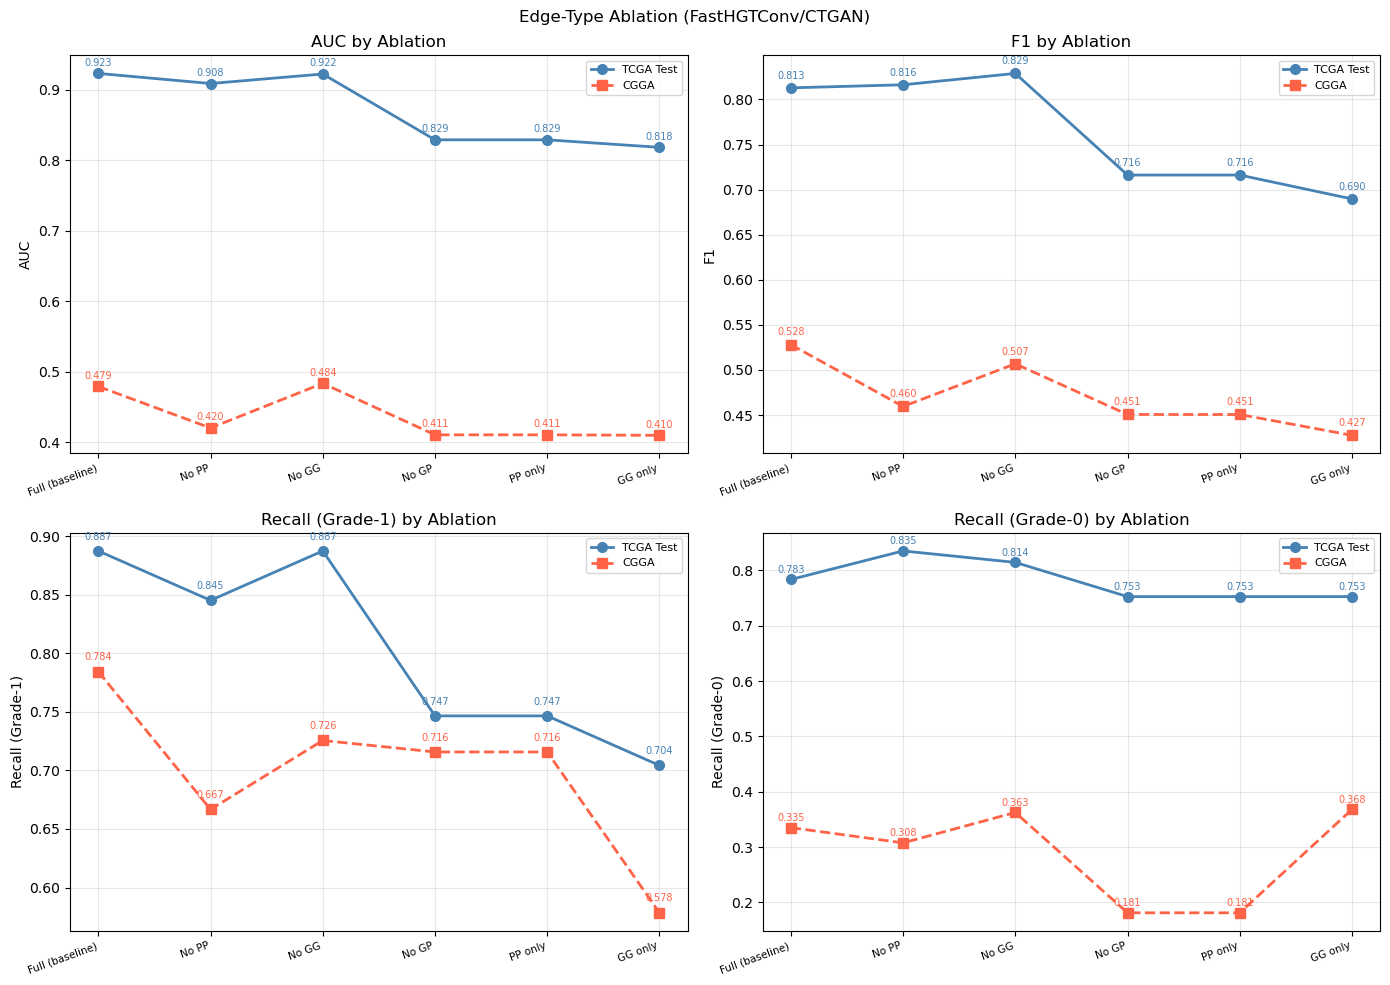

In [54]:
# ============================================================================
# Section E — Edge-Type Ablation Study
# ============================================================================
print("\n" + "="*65 + "\nSection E — Edge-Type Ablation\n" + "="*65)


def ablate_graph(df, remove_pp=False, remove_gg=False, remove_gp=False, scaler=None):
    g = construct_scalefree_bipartite_heterograph(df, scaler=scaler)
    if remove_pp:
        g[('Patient','cooccurs','Patient')].edge_index = torch.zeros(2, 0, dtype=torch.long)
    if remove_gg:
        g[('Gene','coexists','Gene')].edge_index = torch.zeros(2, 0, dtype=torch.long)
    if remove_gp:
        g[('Gene','mutates','Patient')].edge_index    = torch.zeros(2, 0, dtype=torch.long)
        g[('Patient','mutated_by','Gene')].edge_index = torch.zeros(2, 0, dtype=torch.long)
    return g


ABLATIONS = {
    'Full (baseline)':    dict(remove_pp=False, remove_gg=False, remove_gp=False),
    'No PP':              dict(remove_pp=True,  remove_gg=False, remove_gp=False),
    'No GG':              dict(remove_pp=False, remove_gg=True,  remove_gp=False),
    'No GP':              dict(remove_pp=False, remove_gg=False, remove_gp=True),
    'PP only':            dict(remove_pp=False, remove_gg=True,  remove_gp=True),
    'GG only':            dict(remove_pp=True,  remove_gg=False, remove_gp=True),
}

aug_df_ablation = apply_ctgan(train_val_df.copy())
ablation_results = []

for abl_name, abl_cfg in ABLATIONS.items():
    print(f"\n  Ablation: {abl_name}")
    set_seed(42)
    try:
        tr_abl = to_dev(ablate_graph(aug_df_ablation, **abl_cfg, scaler=GLOBAL_SCALER))
        vl_abl = to_dev(ablate_graph(val_df,          **abl_cfg, scaler=GLOBAL_SCALER))
        te_abl = to_dev(ablate_graph(test_df,          **abl_cfg, scaler=GLOBAL_SCALER))
        cg_abl = to_dev(ablate_graph(cgga_df,          **abl_cfg, scaler=GLOBAL_SCALER))
    except Exception as e:
        print(f"    Graph build error: {e}"); continue

    _, state_abl, _ = train_and_evaluate(
        tr_abl, vl_abl, BEST_BP_TCGA, BEST_MODEL_CLS_TCGA, BEST_FKW_TCGA,
        seed=42, loss_fn=make_criterion(tr_abl))
    kw_abl = {'hidden_dim': BEST_BP_TCGA['hidden_dim'], 'out_dim': 2,
               'num_heads': BEST_BP_TCGA['num_heads'], 'dropout': BEST_BP_TCGA['dropout']}
    kw_abl.update(BEST_FKW_TCGA)
    m_abl = BEST_MODEL_CLS_TCGA(**kw_abl).to(device)
    try:
        with torch.no_grad(): _ = m_abl(tr_abl)
    except: pass
    m_abl.load_state_dict(state_abl)

    for ds_name, ds_g in [('TCGA Test', te_abl), ('CGGA', cg_abl)]:
        pd_, pb_, lb_ = evaluate_model(m_abl, ds_g, threshold=BEST_THRESHOLD_TCGA)
        try:    auc = roc_auc_score(lb_, pb_)
        except: auc = np.nan
        ablation_results.append({
            'Ablation': abl_name, 'Dataset': ds_name,
            'AUC': round(auc, 4),
            'F1': round(f1_score(lb_, pd_, zero_division=0), 4),
            'Recall_1': round(recall_score(lb_, pd_, pos_label=1, zero_division=0), 4),
            'Recall_0': round(recall_score(lb_, pd_, pos_label=0, zero_division=0), 4),
        })
        print(f"    {ds_name}: AUC={auc:.4f}")

ablation_df = pd.DataFrame(ablation_results)
print("\nAblation Results:")
print(ablation_df.to_string(index=False))
ablation_df.to_csv('V16_ablation_study.csv', index=False)

# Delta from baseline
full_auc = {ds: ablation_df[(ablation_df.Ablation=='Full (baseline)') &
                             (ablation_df.Dataset==ds)]['AUC'].values[0]
            for ds in ['TCGA Test','CGGA']}
print("\nAUC delta from Full baseline:")
for _, row in ablation_df.iterrows():
    if row['Ablation'] == 'Full (baseline)': continue
    delta = row['AUC'] - full_auc.get(row['Dataset'], 0)
    print(f"  {row['Ablation']:20s} {row['Dataset']:10s}: Δ={delta:+.4f}")

# Ablation figure
abl_order = list(ABLATIONS.keys())
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics_abl = ['AUC', 'F1', 'Recall_1', 'Recall_0']
metric_labels = ['AUC', 'F1', 'Recall (Grade-1)', 'Recall (Grade-0)']
for ax, metric, mlbl in zip(axes.flatten(), metrics_abl, metric_labels):
    for ds, ls in [('TCGA Test', '-o'), ('CGGA', '--s')]:
        sub = ablation_df[ablation_df.Dataset == ds].set_index('Ablation').reindex(abl_order)
        ax.plot(range(len(abl_order)), sub[metric].fillna(0),
                ls, color='steelblue' if ds == 'TCGA Test' else 'tomato', lw=2, ms=7, label=ds)
        for xi, val in enumerate(sub[metric].fillna(0)):
            ax.text(xi, val + 0.008, f'{val:.3f}', ha='center', va='bottom', fontsize=7,
                    color='steelblue' if ds == 'TCGA Test' else 'tomato')
    ax.set_xticks(range(len(abl_order)))
    ax.set_xticklabels(abl_order, rotation=20, ha='right', fontsize=7.5)
    ax.set_ylabel(mlbl); ax.set_title(f'{mlbl} by Ablation'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle(f'Edge-Type Ablation ({BEST_MODEL_NAME_TCGA}/{BEST_PIPELINE_TCGA})')
plt.tight_layout(); plt.savefig('V16_ablation_study.png', dpi=150, bbox_inches='tight'); plt.show()

In [55]:
# ============================================================================
# Section F — Reproducibility Manifest
# ============================================================================
import platform
import torch as _torch, numpy as _np, pandas as _pd
import sklearn as _sk, scipy as _sp, matplotlib as _mpl, seaborn as _sns
import xgboost as _xgb, umap as _umap, sdv as _sdv

packages = {
    'python':     platform.python_version(),
    'torch':      _torch.__version__,
    'numpy':      _np.__version__,
    'pandas':     _pd.__version__,
    'sklearn':    _sk.__version__,
    'scipy':      _sp.__version__,
    'matplotlib': _mpl.__version__,
    'seaborn':    _sns.__version__,
    'xgboost':    _xgb.__version__,
    'umap-learn': _umap.__version__,
    'sdv':        _sdv.__version__,
    'cuda':       _torch.version.cuda if _torch.cuda.is_available() else 'N/A',
    'device':     str(device),
    'gpu':        _torch.cuda.get_device_name(0) if _torch.cuda.is_available() else 'N/A',
}

experiment_config = {
    'RANDOM_SEED': 42, 'N_FOLDS': 5, 'N_TRIALS_OPTUNA': 100,
    'MAX_EPOCHS': 200, 'PATIENCE': 50,
    'TEST_SIZE': 0.2, 'VAL_SIZE': 0.2,
    'MIN_AGE': 18, 'N_GENES': 20, 'BA_M_PATIENT': 2, 'BA_M_GENE': 2,
    'CTGAN_EPOCHS': 150, 'CTGAN_BATCH_SIZE': 50, 'CTGAN_PAC': 10,
    'FOCAL_GAMMA': 2, 'CLASS_WEIGHT': 'inverse_frequency',
    'THRESHOLD': 'G-mean [0.20, 0.80] step 0.005',
    'SMOTE_K': 3, 'BOOTSTRAP_N': 10_000,
}

manifest = {
    'packages':          packages,
    'experiment_config': experiment_config,
    'best_model_tcga':   {'name': BEST_MODEL_NAME_TCGA, 'pipeline': BEST_PIPELINE_TCGA, 'params': BEST_BP_TCGA},
    'best_model_cgga':   {'name': BEST_MODEL_NAME_CGGA, 'pipeline': BEST_PIPELINE_CGGA, 'params': BEST_BP_CGGA},
    'data_splits':       {'train': len(train_df), 'val': len(val_df),
                          'test': len(test_df), 'cgga': len(cgga_df)},
}

with open('V16_reproducibility_manifest.json', 'w') as f:
    json.dump(manifest, f, indent=2, default=str)
print("✓ Saved: V16_reproducibility_manifest.json")

print("\n=== PACKAGE VERSIONS ===")
for k, v in packages.items(): print(f"  {k:20s}: {v}")
print("\n=== EXPERIMENT CONFIG ===")
for k, v in experiment_config.items(): print(f"  {k:30s}: {v}")
print(f"\n=== BEST TCGA: {BEST_MODEL_NAME_TCGA}/{BEST_PIPELINE_TCGA} ===")
for k, v in BEST_BP_TCGA.items(): print(f"  {k:20s}: {v}")
print(f"\n=== BEST CGGA: {BEST_MODEL_NAME_CGGA}/{BEST_PIPELINE_CGGA} ===")
for k, v in BEST_BP_CGGA.items(): print(f"  {k:20s}: {v}")


✓ Saved: V16_reproducibility_manifest.json

=== PACKAGE VERSIONS ===
  python              : 3.11.15
  torch               : 2.12.0+cu130
  numpy               : 2.4.6
  pandas              : 2.3.3
  sklearn             : 1.9.0
  scipy               : 1.17.1
  matplotlib          : 3.10.9
  seaborn             : 0.13.2
  xgboost             : 2.0.3
  umap-learn          : 0.5.12
  sdv                 : 1.9.0
  cuda                : 13.0
  device              : cuda
  gpu                 : NVIDIA GeForce RTX 3050

=== EXPERIMENT CONFIG ===
  RANDOM_SEED                   : 42
  N_FOLDS                       : 5
  N_TRIALS_OPTUNA               : 100
  MAX_EPOCHS                    : 200
  PATIENCE                      : 50
  TEST_SIZE                     : 0.2
  VAL_SIZE                      : 0.2
  MIN_AGE                       : 18
  N_GENES                       : 20
  BA_M_PATIENT                  : 2
  BA_M_GENE                     : 2
  CTGAN_EPOCHS                  : 150
  CTGAN_B

In [56]:
# ============================================================================
# Save all model weights and thresholds
# ============================================================================
pd.DataFrame([{'Model': mn, 'Pipeline': pp, 'Threshold': th}
               for (mn, pp), th in all_thresholds.items()]).to_csv('V16_thresholds.csv', index=False)

print("\n=== ALL SECTIONS COMPLETE ===")
print("Output files:")
for f in ['V16_results_final.csv', 'V16_cv_folds.csv', 'V16_bootstrap_ci.csv',
          'V16_mcnemar.csv', 'V16_ctgan_feat_dist.csv', 'V16_ctgan_class_conditional.csv',
          'V16_graph_strategy_comparison.csv', 'V16_tabular_baselines.csv',
          'V16_ablation_study.csv', 'V16_thresholds.csv', 'V16_reproducibility_manifest.json']:
    exists = '✓' if os.path.exists(f) else '○'
    print(f"  {exists} {f}")


=== ALL SECTIONS COMPLETE ===
Output files:
  ✓ V16_results_final.csv
  ✓ V16_cv_folds.csv
  ✓ V16_bootstrap_ci.csv
  ✓ V16_mcnemar.csv
  ✓ V16_ctgan_feat_dist.csv
  ✓ V16_ctgan_class_conditional.csv
  ✓ V16_graph_strategy_comparison.csv
  ✓ V16_tabular_baselines.csv
  ✓ V16_ablation_study.csv
  ✓ V16_thresholds.csv
  ✓ V16_reproducibility_manifest.json
